# **Multi-Otsu thresholding procedure**

# **Libraries**

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from skimage.io import imread
from skimage.filters import threshold_multiotsu
from skimage.measure import label, regionprops
import zipfile
import shutil
from scipy.stats import mannwhitneyu

# Mute useless warnings
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# Useful functions

In [ ]:
# Function to parse size class ranges
def parse_size_class(size_class_str):
    if '-' in size_class_str:
        return list(map(float, size_class_str.replace(' ', '').split('-')))
    else:
        return [float(size_class_str.strip()), float(size_class_str.strip())]

# Function to assign a size class
def assign_size_class(esd_um):
    for i, (low, high) in enumerate(size_class_ranges):
        if low <= esd_um <= high:
            return size_class['size_classes'][i].replace(' ', '')  # Remove extra spaces
    return None

def display_image(image, title):
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('on')
    plt.show()

# **Import tracks from Villefranche cruise**

In [16]:
vlfr_tracks = pd.read_csv('/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/Data/sinking_speeds/correction_selection_poly/selected_tracks_by_interquartile_vlfr_poly_no_living.csv')
vlfr_tracks = vlfr_tracks[['track_id', 'corrected_by_poly']]
vlfr_tracks.head(3)

,track_id,corrected_by_poly
0,vlfr_20230418-142403-1-418,-73.375225
1,vlfr_20230418-142413-1-608,91.721063
2,vlfr_20230418-142426-1-958,63.854057
3,vlfr_20230418-142511-1-2256,77.394113
4,vlfr_20230418-142605-1-3707,68.070449
...,...,...
461,vlfr_20230501-231957-1-10371,-56.134440
462,vlfr_20230501-232003-1-10572,-69.149905
463,vlfr_20230501-232004-1-10588,-56.078112
464,vlfr_20230501-232007-1-10668,36.758480


In [17]:
# import dataset with position of each particle 
x_y_positions_vlfr = pd.read_csv('/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/Data/sinking_speeds/tracks_all_vlfr_.tsv', delimiter = '\t')
# keep only the selected ones
x_y_positions_vlfr = pd.merge(vlfr_tracks, x_y_positions_vlfr, on = 'track_id')
x_y_positions_vlfr.head(3)

,track_id,corrected_by_poly,track_length,speed,angle,vertical_speed,orientation,sequence,part_id,n_img,img_name,datetime,coord_x,coord_y,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,orientation_particle,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,filename,PC1,PC2,PC3,PC4,PC5,roll,potential_match,euclidean_distance,sequence_ini,date_ini
0,vlfr_20230418-142403-1-418,-73.375225,5,98.105304,285.994576,94.296297,desc,20230418-142321,418,41,20230418-142403-1,2023-04-18 14:24:03,54.600000,293.200000,5.0,2.523133,5.207107,14313.892819,135.000053,3.098387,1.788854,-0.321751,1.680586,46.800000,17.825824,38.089367,234,40.0,27,69,42,5.0,0.816497,0.833333,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.416333,-0.050769,0.293499,0.549591,0.355574,0,False,0.000000,20230418-142321,2023-04-18 14:24:03
1,vlfr_20230418-142403-1-418,-73.375225,5,98.105304,285.994576,94.296297,desc,20230418-142321,435,42,20230418-142404-1,2023-04-18 14:24:04,59.333333,308.333333,3.0,1.954410,3.414214,8011.938028,101.000576,2.309401,1.333333,-0.785398,1.478398,89.000000,12.569805,14.123377,267,93.0,72,102,30,3.0,0.816497,0.750000,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.584537,-0.291607,-0.497807,-1.698014,1.104741,0,False,6302.804249,20230418-142321,2023-04-18 14:24:03
2,vlfr_20230418-142403-1-418,-73.375225,5,98.105304,285.994576,94.296297,desc,20230418-142321,449,43,20230418-142405-1,2023-04-18 14:24:05,63.333333,323.333333,3.0,1.954410,3.414214,8011.938028,101.000576,2.309401,1.333333,-0.785398,1.478398,44.666667,14.817407,33.173300,134,52.0,24,58,34,3.0,0.816497,0.750000,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-1.000726,0.253233,0.898243,0.090423,0.415887,0,False,161.119197,20230418-142321,2023-04-18 14:24:03
3,vlfr_20230418-142403-1-418,-73.375225,5,98.105304,285.994576,94.296297,desc,20230418-142321,469,44,20230418-142406-1,2023-04-18 14:24:06,67.500000,338.000000,4.0,2.256758,4.414214,11108.821442,118.929352,3.236068,1.236068,0.553574,1.364067,37.000000,16.340135,44.162526,148,30.0,24,64,40,4.0,0.924176,0.666667,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.695549,1.518322,-0.090313,0.919229,-0.292665,0,False,3097.086723,20230418-142321,2023-04-18 14:24:03
4,vlfr_20230418-142403-1-418,-73.375225,5,98.105304,285.994576,94.296297,desc,20230418-142321,486,45,20230418-142407-1,2023-04-18 14:24:07,71.750000,353.000000,4.0,2.256758,4.621320,11108.821442,118.929352,2.828427,1.732051,0.000000,1.633883,54.250000,24.752525,45.626774,217,49.5,27,91,64,4.0,0.790569,0.666667,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.320545,0.524199,-0.085321,-0.042610,-0.201388,0,False,82.621248,20230418-142321,2023-04-18 14:24:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6690,vlfr_20230501-232018-1-10906,42.969573,17,47.901883,72.426395,45.612549,asc,20230501-231319,11178,416,20230501-232031-1,2023-05-01 23:20:31,152.250000,1400.000000,4.0,2.256758,4.621320,11108.821442,118.929352,2.828427,1.732051,0.000000,1.633883,60.250000,21.381943,35.488703,241,57.0,35,92,57,4.0,0.790569,0.666667,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.400756,0.534168,-0.278820,0.078163,-0.200359,0,False,45.367371,20230501-231319,2023-05-01 23:20:18
6691,vlfr_20230501-232018-1-10906,42.969573,17,47.901883,72.426395,45.612549,asc,20230501-231319,11200,417,20230501-232032-1,2023-05-01 23:20:32,154.400000,1391.800000,5.0,2.523133,5.207107,14313.892819,135.000053,3.098387,1.788854,-0.321751,1.680586,62.800000,41.140734,65.510723,314,54.0,27,140,113,5.0,0.816497,0.833333,1.0,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,-0.105745,-0.133160,-0.207965,-0.600295,0.233742,0,False,3207.005388,20230501-231319,2023-05-01 23:20:18
6692,vlfr_20230501-232018-1-10906,42.969573,17,47.901883,72.426395,45.612549,asc,2

# **Select big particles**

In [18]:
size_threshold = 50 
x_y_positions_vlfr_big_part = x_y_positions_vlfr[x_y_positions_vlfr['area_px'] >= size_threshold]
print(len(x_y_positions_vlfr_big_part['track_id'].unique()))
x_y_positions_vlfr_big_part.head(3)

17


,track_id,corrected_by_poly,track_length,speed,angle,vertical_speed,orientation,sequence,part_id,n_img,img_name,datetime,coord_x,coord_y,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,orientation_particle,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,filename,PC1,PC2,PC3,PC4,PC5,roll,potential_match,euclidean_distance,sequence_ini,date_ini
10,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,751,56,20230418-142418-1,2023-04-18 14:24:18,1960.716981,1471.679245,53.0,8.214724,30.142136,209172.806717,516.068880,10.328734,7.183110,0.145570,2.918280,107.981132,69.151049,64.039937,5723,90.0,23,234,211,66.0,0.718575,0.535354,0.803030,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.572849,-0.387994,-0.965730,-1.176560,0.156809,0,False,78646.880317,20230418-142321,2023-04-18 14:24:13
11,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,777,57,20230418-142419-1,2023-04-18 14:24:19,1974.355932,1513.440678,59.0,8.667245,30.935029,236273.884390,548.482682,10.464506,7.902196,0.205998,2.956186,111.135593,73.080976,65.758389,6557,97.0,23,239,216,75.0,0.655560,0.546296,0.786667,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.284811,-0.611685,-1.012164,-1.097183,0.133193,0,False,27113.931169,20230418-142321,2023-04-18 14:24:13
12,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,799,58,20230418-142420-1,2023-04-18 14:24:20,1988.728814,1553.983051,59.0,8.667245,32.556349,236273.884390,548.482682,10.616019,7.984109,0.424323,3.066719,103.694915,66.268906,63.907576,6118,82.0,24,232,208,74.0,0.659070,0.491667,0.797297,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.382553,-0.382747,-1.006391,-0.769456,-0.282902,0,False,439.509803,20230418-142321,2023-04-18 14:24:13
13,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,833,59,20230418-142421-1,2023-04-18 14:24:21,2002.090909,1593.800000,55.0,8.368284,28.384776,218162.374209,527.041708,9.836139,7.331499,0.231439,2.885764,107.854545,68.425253,63.442159,5932,95.0,24,227,203,61.0,0.666658,0.687500,0.901639,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.067950,-1.371479,-1.556762,-0.289608,0.811634,0,False,18112.490208,20230418-142321,2023-04-18 14:24:13
19,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,998,65,20230418-142427-1,2023-04-18 14:24:27,2087.980000,1842.080000,50.0,7.978846,25.142136,195775.238153,499.268240,9.356339,6.953426,0.124410,2.687177,90.740000,49.943092,55.039775,4537,93.0,23,182,159,54.0,0.669094,0.625000,0.925926,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,7.266446,-0.892945,-0.949021,0.125327,0.549094,0,False,39518.815419,20230418-142321,2023-04-18 14:24:13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,vlfr_20230429-150651-1-3704,318.482652,4,268.361239,268.749783,268.292401,desc,20230429-150426,3795,144,20230429-150654-1,2023-04-29 15:06:54,2459.223140,2048.876033,121.0,12.412171,50.313708,534283.812969,824.785596,17.860174,10.219316,-0.324754,2.817089,73.214876,34.879535,47.639956,8859,71.0,23,145,122,149.0,0.820125,0.647059,0.812081,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,34.855746,5.665215,0.266584,8.470950,13.514214,0,False,363173.779734,20230429-150426,2023-04-29 15:06:51
5964,vlfr_20230501-063436-1-1392,70.628058,21,75.743824,7.369533,9.710262,asc,20230501-063321,1392,71,20230501-063436-1,2023-05-01 06:34:36,985.981481,609.074074,54.0,8.291860,25.899495,213661.930067,521.577241,9.538233,7.336056,-0.103809,2.715335,136.814815,72.947235,53.318228,7388,153.0,26,252,226,57.0,0.639103,0.750000,0.947368,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,16.934915,-0.749567,-2.038413,1.690028,4.059064,0,Fa

In [19]:
# rename the path to raw images
path_mapping = {
    '/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/raw/': '/home/aaccardo/these_alex/Analysis/APERO/TZEX/all_cycle_analysis/Data/sinking_speeds/multithresholding_meangrey/copy_raw/'}

# Replace paths in the 'filename' column
for old_path, new_path in path_mapping.items():
    x_y_positions_vlfr_big_part['filename'] = x_y_positions_vlfr_big_part['filename'].str.replace(old_path, new_path)

x_y_positions_vlfr_big_part.head(3)

,track_id,corrected_by_poly,track_length,speed,angle,vertical_speed,orientation,sequence,part_id,n_img,img_name,datetime,coord_x,coord_y,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,orientation_particle,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,filename,PC1,PC2,PC3,PC4,PC5,roll,potential_match,euclidean_distance,sequence_ini,date_ini
10,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,751,56,20230418-142418-1,2023-04-18 14:24:18,1960.716981,1471.679245,53.0,8.214724,30.142136,209172.806717,516.068880,10.328734,7.183110,0.145570,2.918280,107.981132,69.151049,64.039937,5723,90.0,23,234,211,66.0,0.718575,0.535354,0.803030,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.572849,-0.387994,-0.965730,-1.176560,0.156809,0,False,78646.880317,20230418-142321,2023-04-18 14:24:13
11,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,777,57,20230418-142419-1,2023-04-18 14:24:19,1974.355932,1513.440678,59.0,8.667245,30.935029,236273.884390,548.482682,10.464506,7.902196,0.205998,2.956186,111.135593,73.080976,65.758389,6557,97.0,23,239,216,75.0,0.655560,0.546296,0.786667,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.284811,-0.611685,-1.012164,-1.097183,0.133193,0,False,27113.931169,20230418-142321,2023-04-18 14:24:13
12,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,799,58,20230418-142420-1,2023-04-18 14:24:20,1988.728814,1553.983051,59.0,8.667245,32.556349,236273.884390,548.482682,10.616019,7.984109,0.424323,3.066719,103.694915,66.268906,63.907576,6118,82.0,24,232,208,74.0,0.659070,0.491667,0.797297,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.382553,-0.382747,-1.006391,-0.769456,-0.282902,0,False,439.509803,20230418-142321,2023-04-18 14:24:13
13,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,833,59,20230418-142421-1,2023-04-18 14:24:21,2002.090909,1593.800000,55.0,8.368284,28.384776,218162.374209,527.041708,9.836139,7.331499,0.231439,2.885764,107.854545,68.425253,63.442159,5932,95.0,24,227,203,61.0,0.666658,0.687500,0.901639,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.067950,-1.371479,-1.556762,-0.289608,0.811634,0,False,18112.490208,20230418-142321,2023-04-18 14:24:13
19,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,998,65,20230418-142427-1,2023-04-18 14:24:27,2087.980000,1842.080000,50.0,7.978846,25.142136,195775.238153,499.268240,9.356339,6.953426,0.124410,2.687177,90.740000,49.943092,55.039775,4537,93.0,23,182,159,54.0,0.669094,0.625000,0.925926,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,7.266446,-0.892945,-0.949021,0.125327,0.549094,0,False,39518.815419,20230418-142321,2023-04-18 14:24:13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,vlfr_20230429-150651-1-3704,318.482652,4,268.361239,268.749783,268.292401,desc,20230429-150426,3795,144,20230429-150654-1,2023-04-29 15:06:54,2459.223140,2048.876033,121.0,12.412171,50.313708,534283.812969,824.785596,17.860174,10.219316,-0.324754,2.817089,73.214876,34.879535,47.639956,8859,71.0,23,145,122,149.0,0.820125,0.647059,0.812081,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,34.855746,5.665215,0.266584,8.470950,13.514214,0,False,363173.779734,20230429-150426,2023-04-29 15:06:51
5964,vlfr_20230501-063436-1-1392,70.628058,21,75.743824,7.369533,9.710262,asc,20230501-063321,1392,71,20230501-063436-1,2023-05-01 06:34:36,985.981481,609.074074,54.0,8.291860,25.899495,213661.930067,521.577241,9.538233,7.336056,-0.103809,2.715335,136.814815,72.947235,53.318228,7388,153.0,26,252,226,57.0,0.639103,0.750000,0.947368,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,16.934915,-0.749567,-2.038413,1.690028,4.059064,0,Fa

# **Loop over all the sequences and perform Multi-Otsu threshold**

Processing sequence 1/13: 20230418-142321
20230418-142321
extract images from server to local


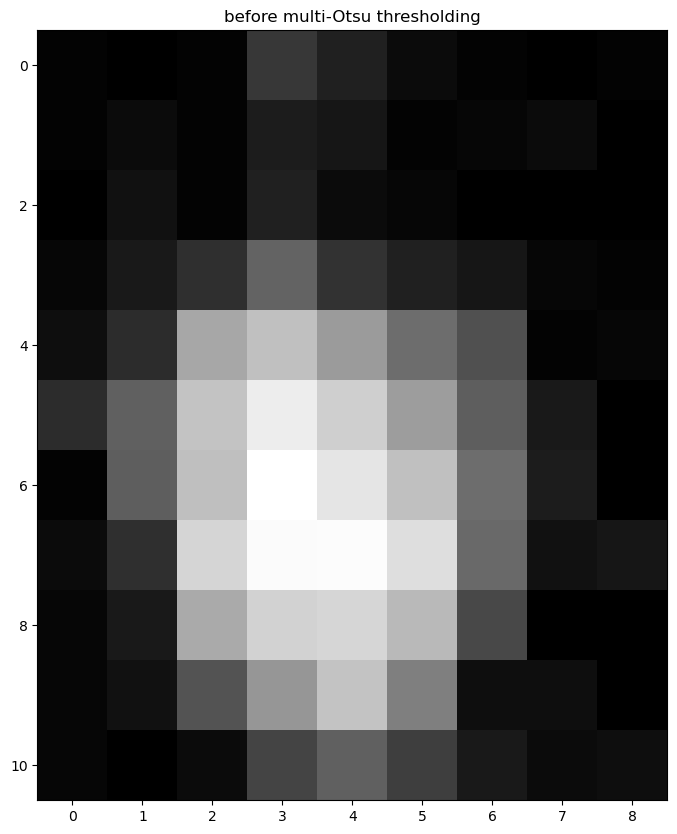

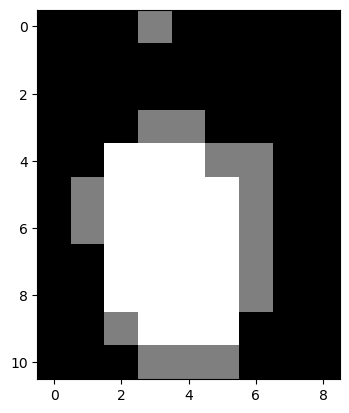

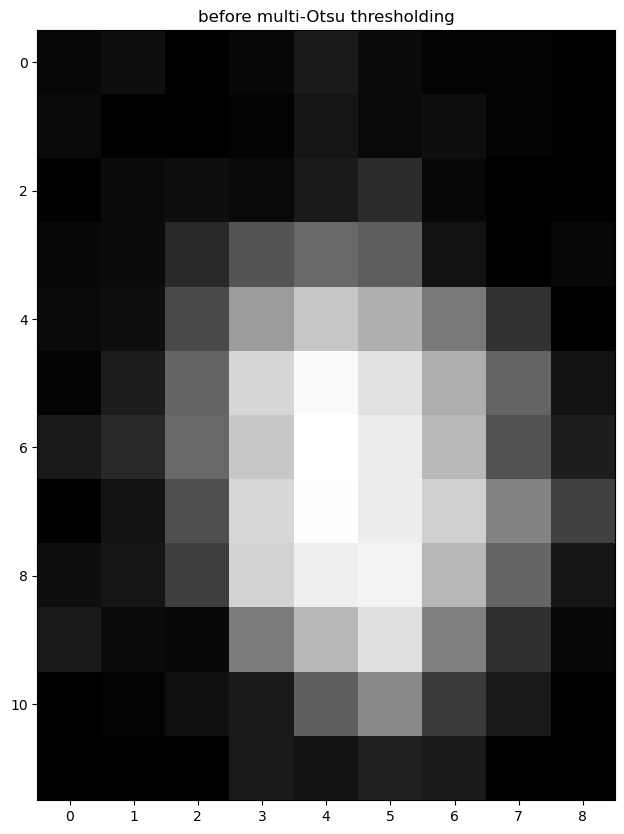

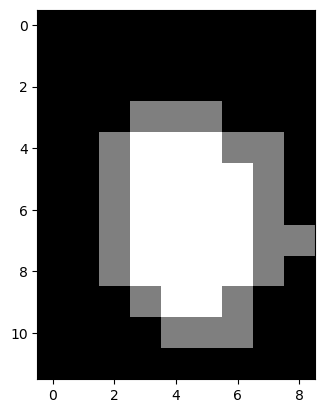

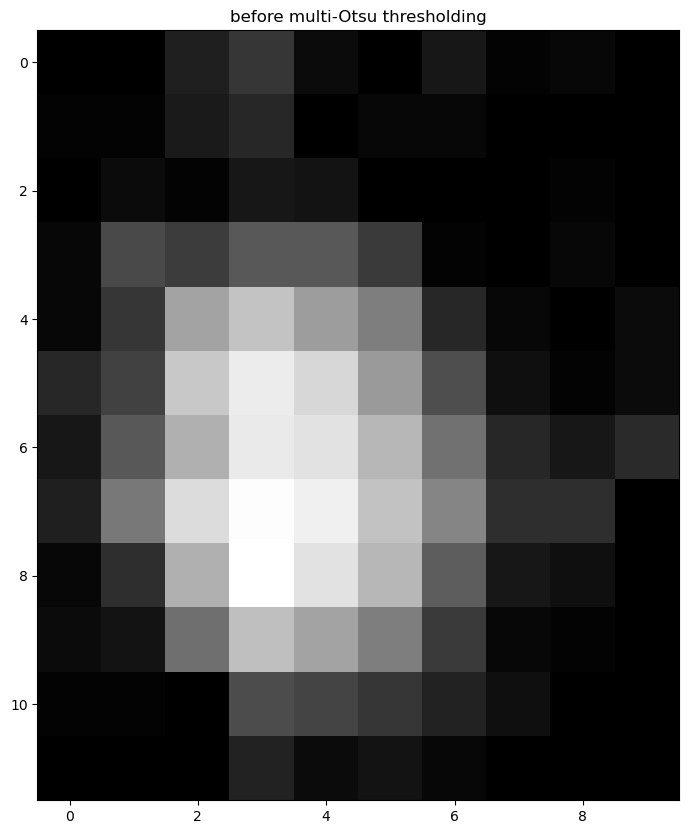

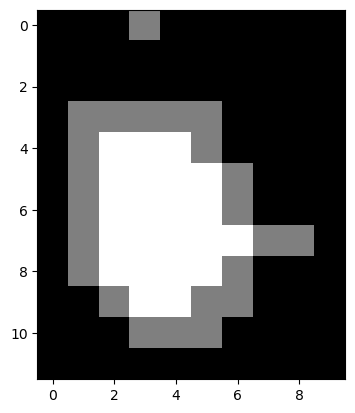

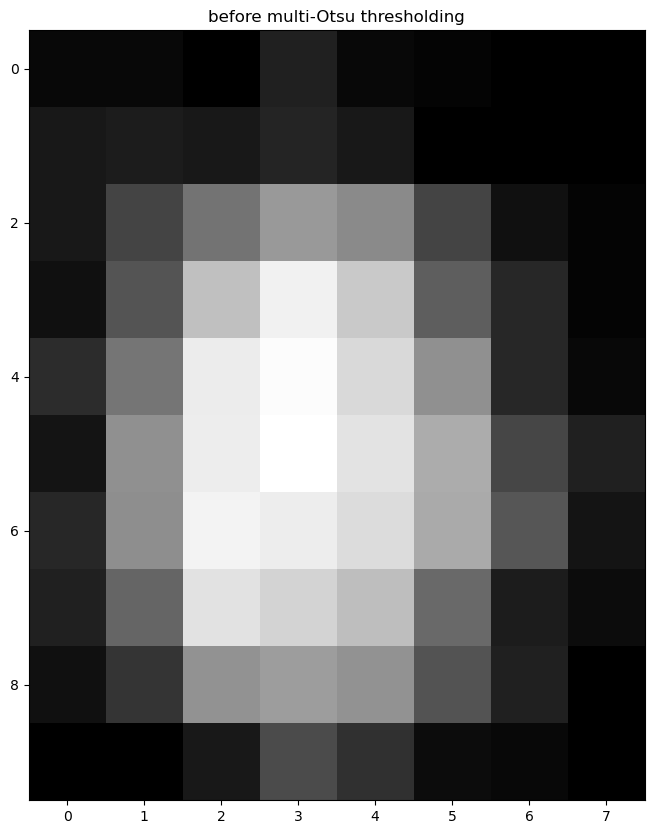

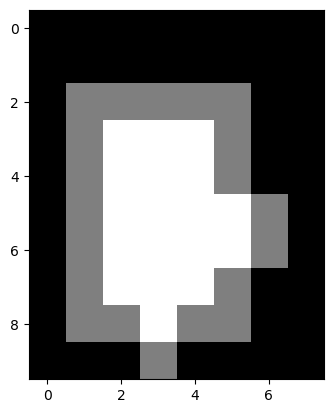

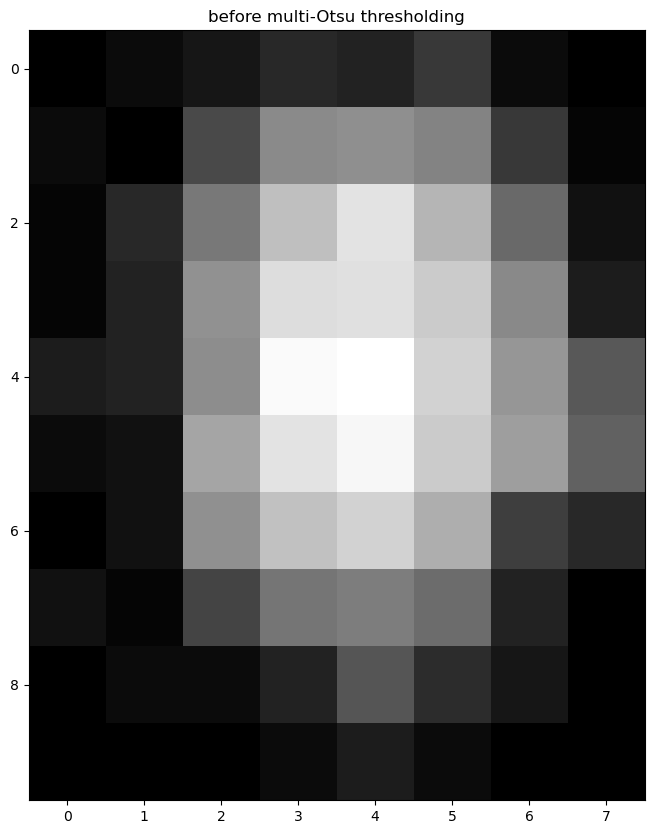

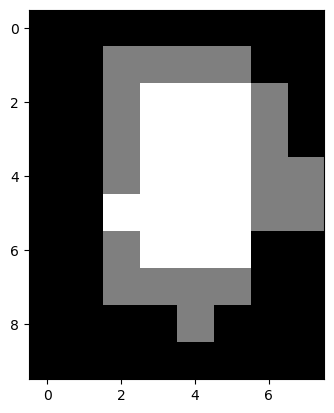

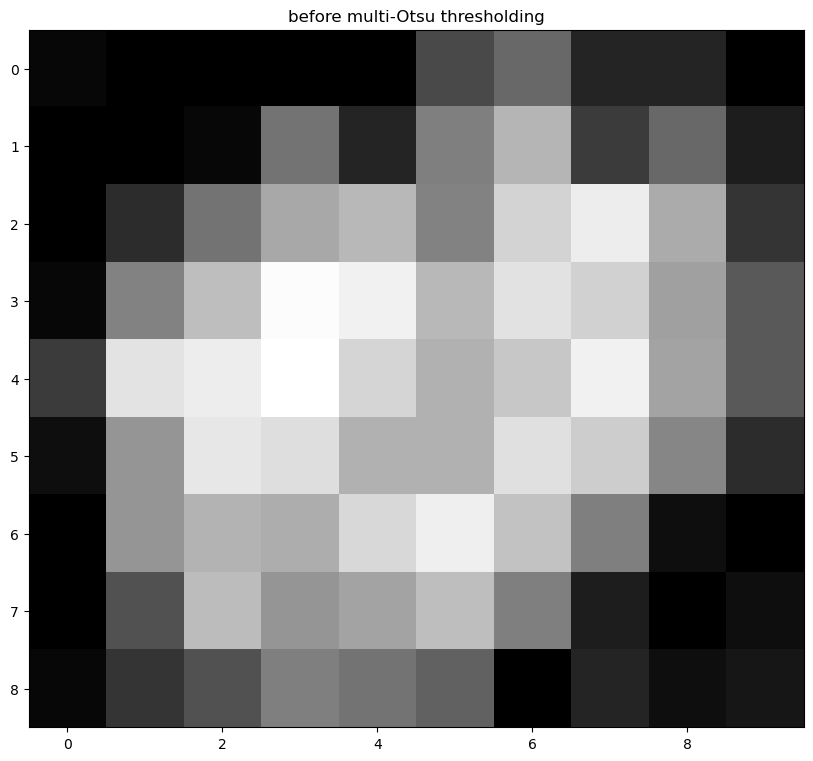

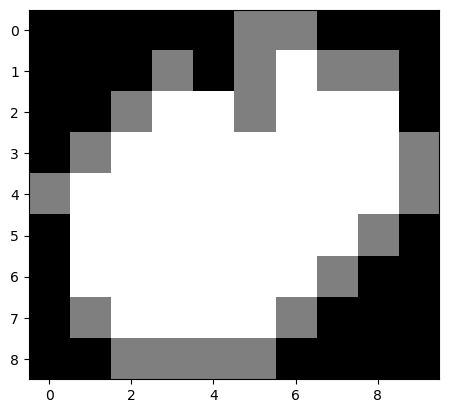

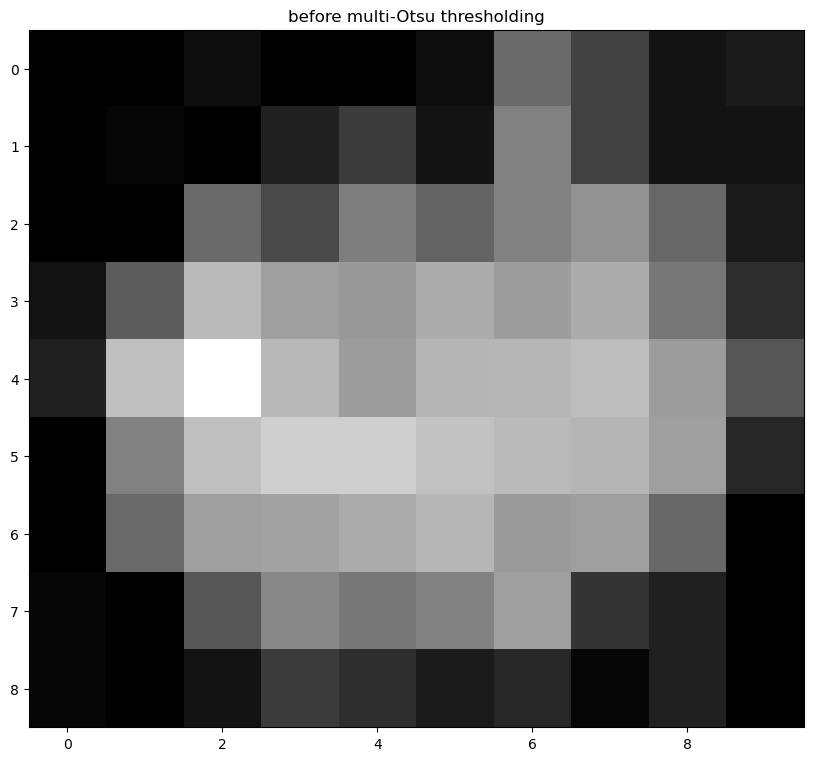

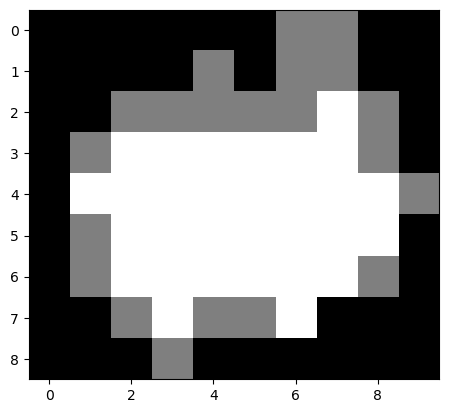

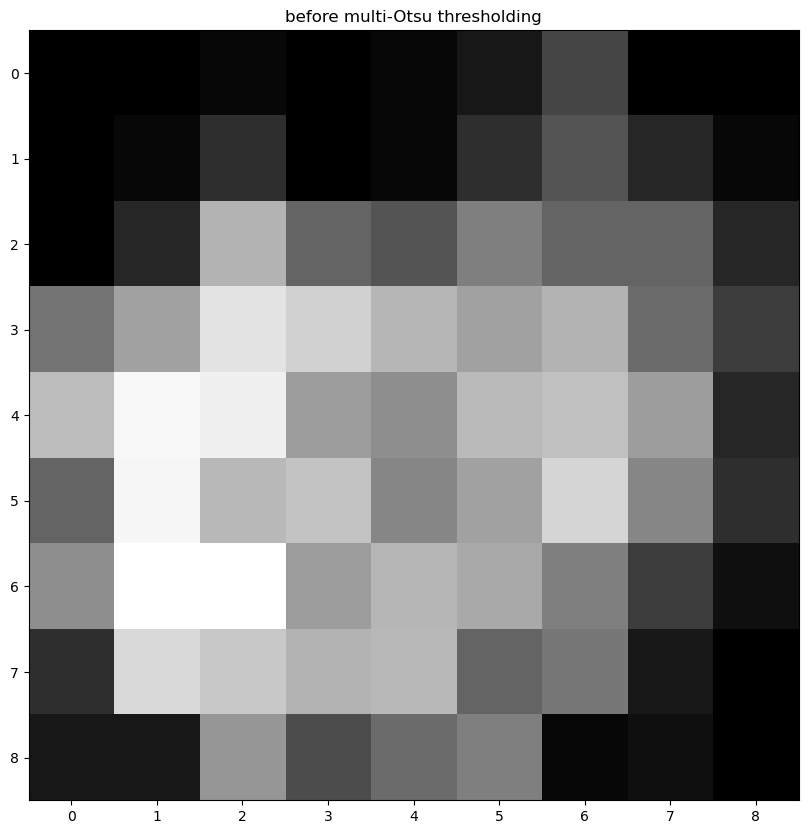

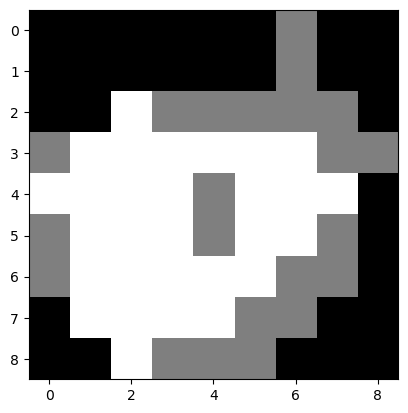

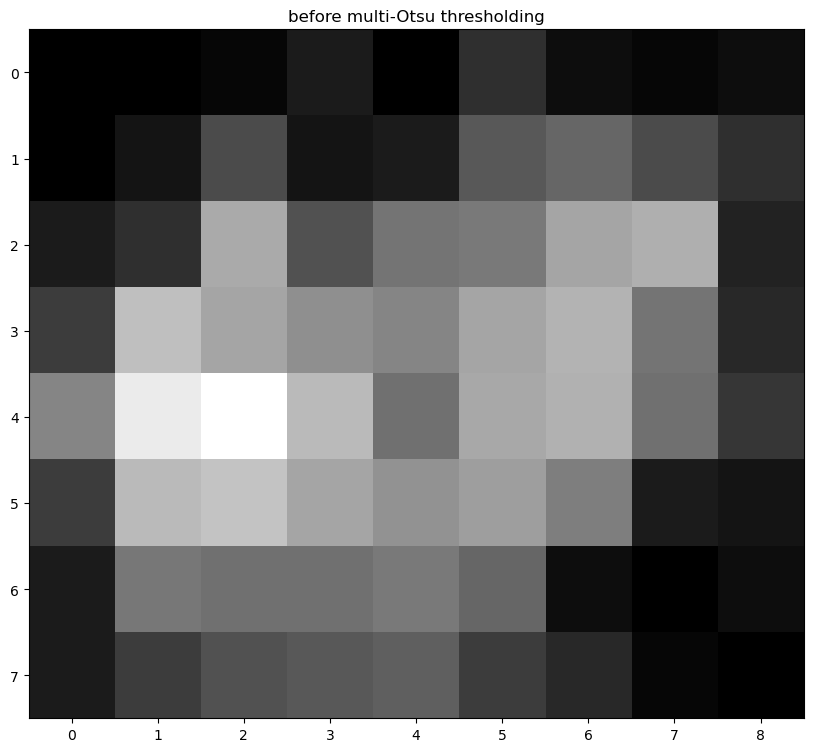

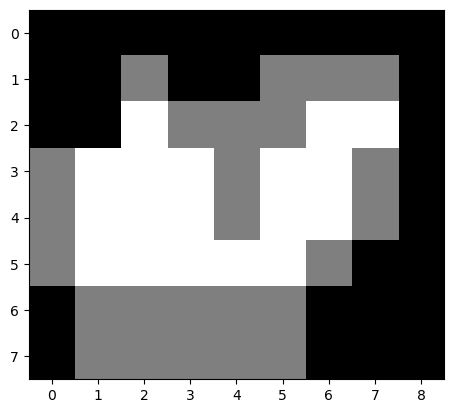

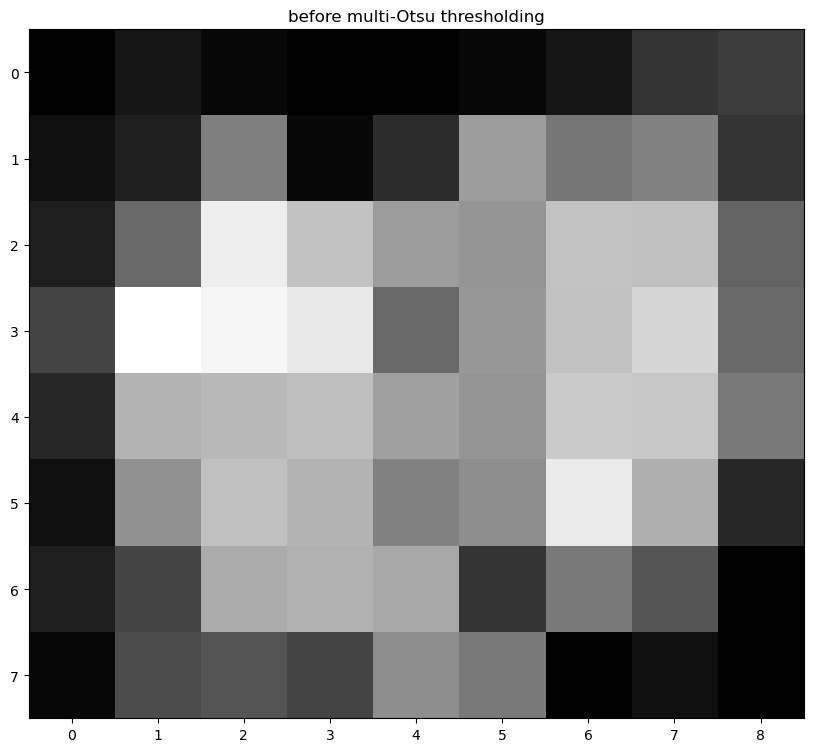

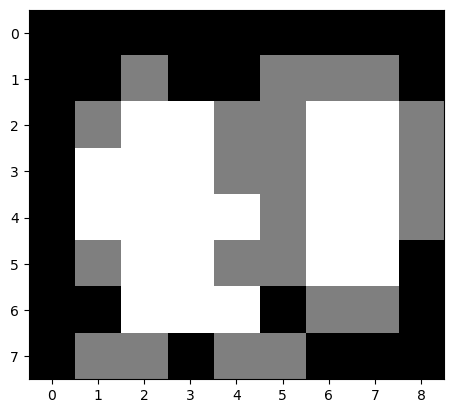

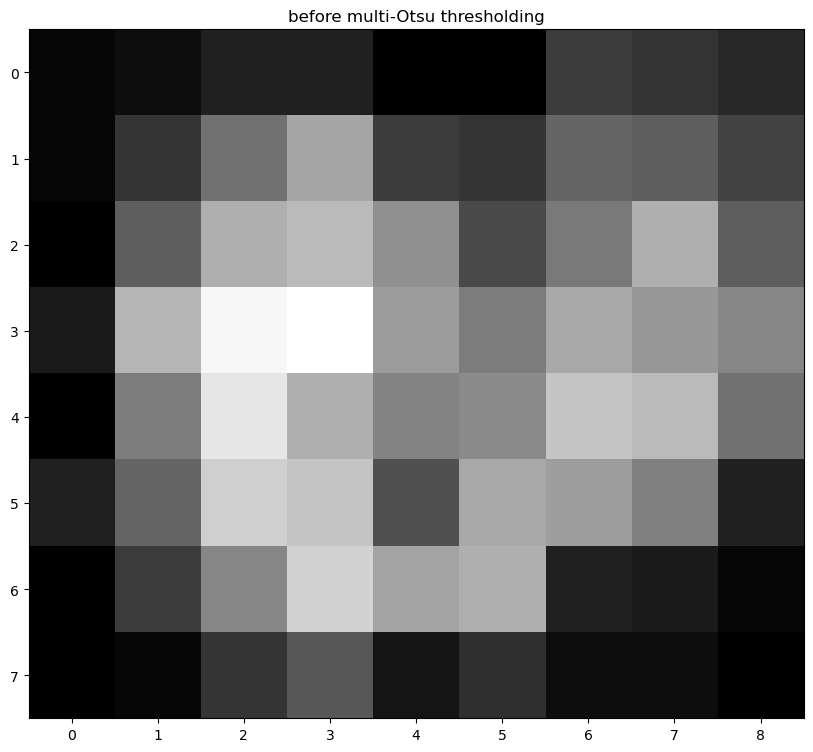

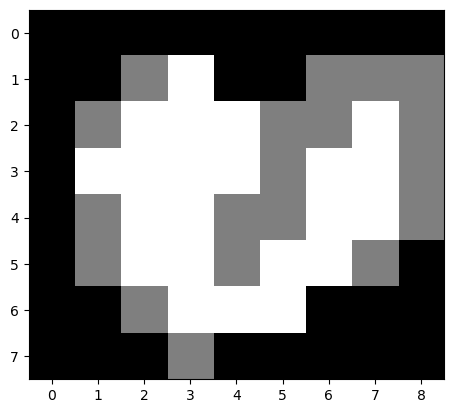

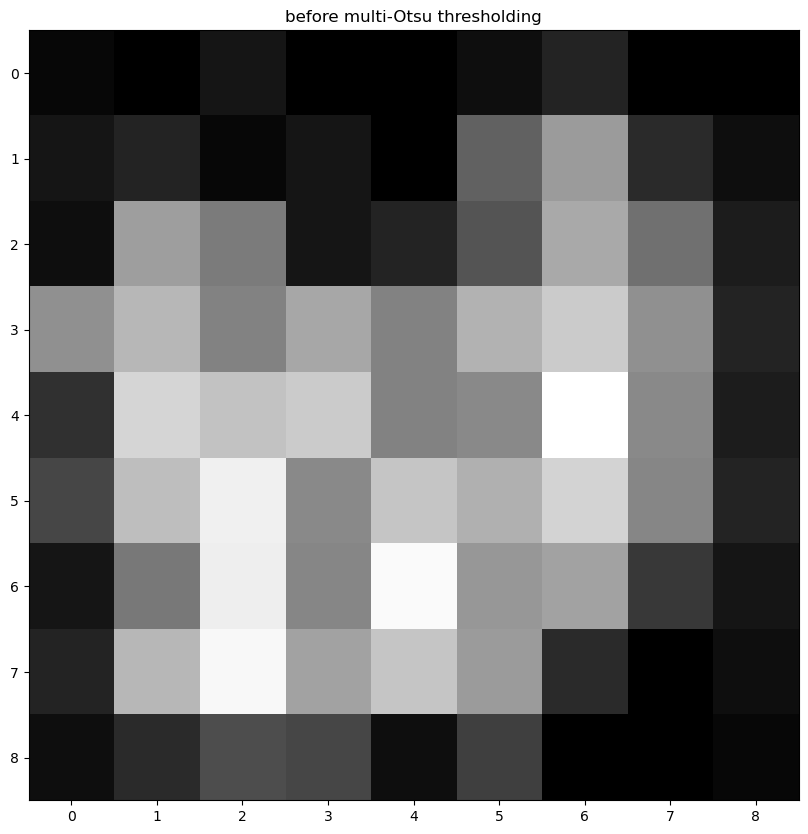

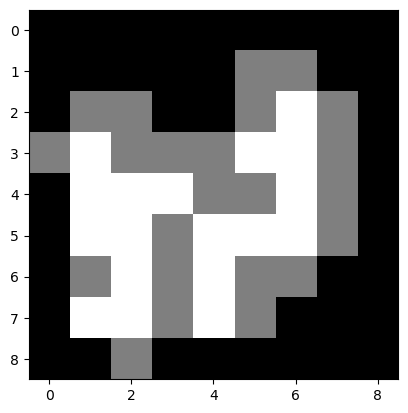

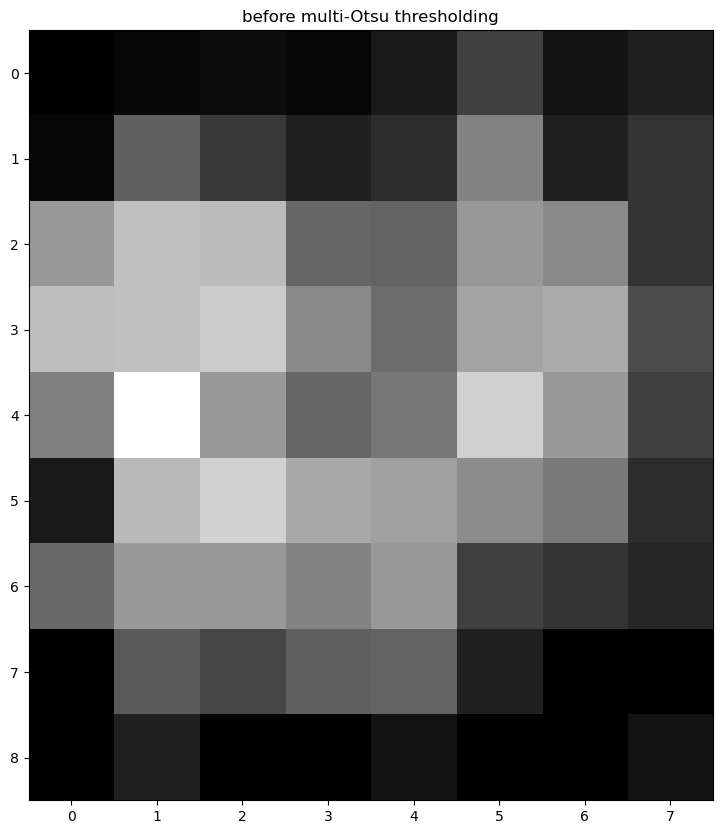

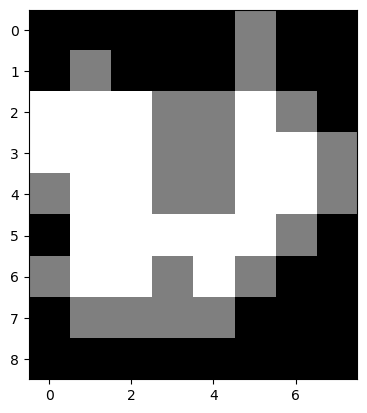

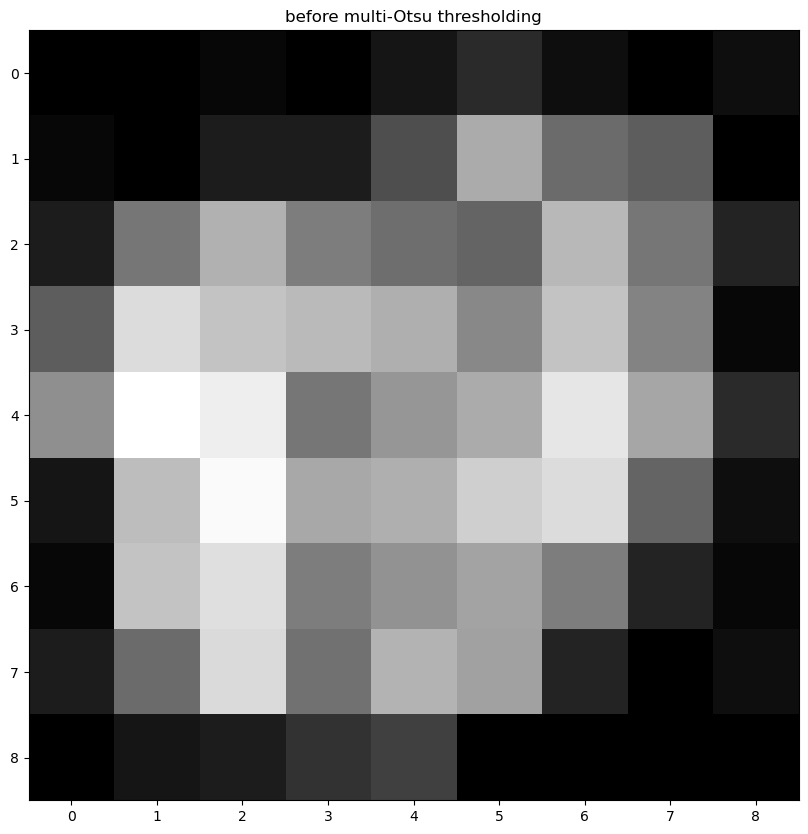

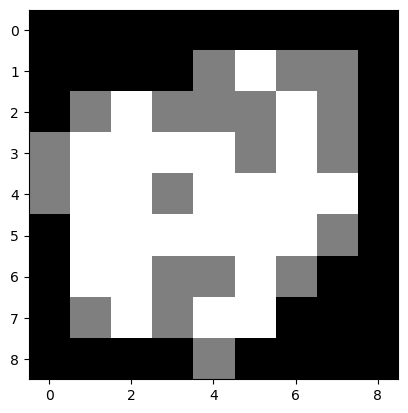

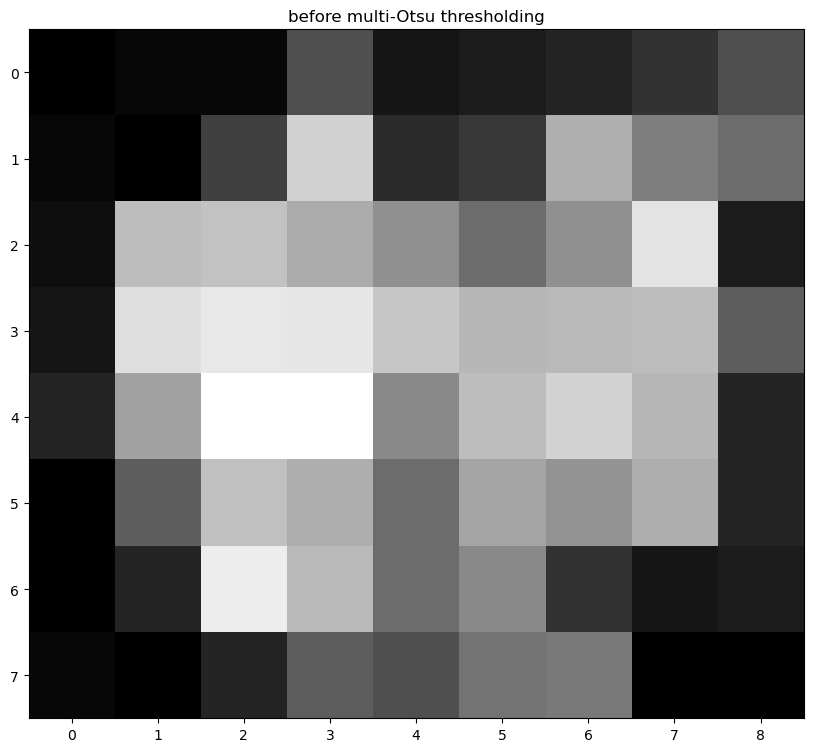

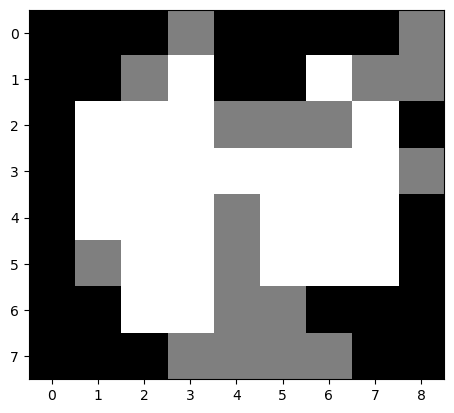

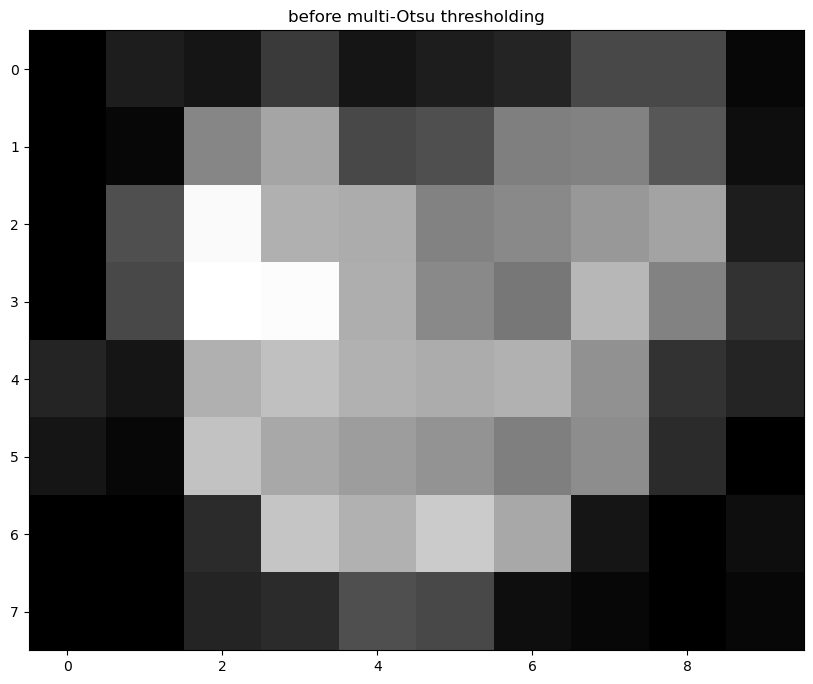

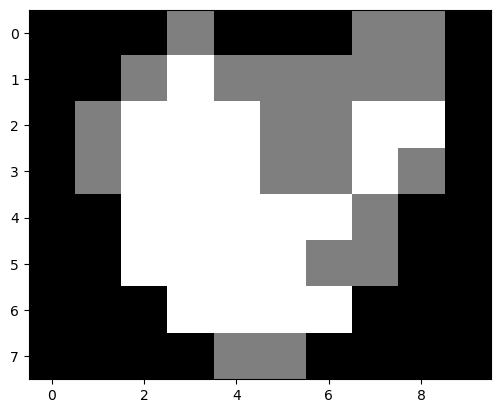

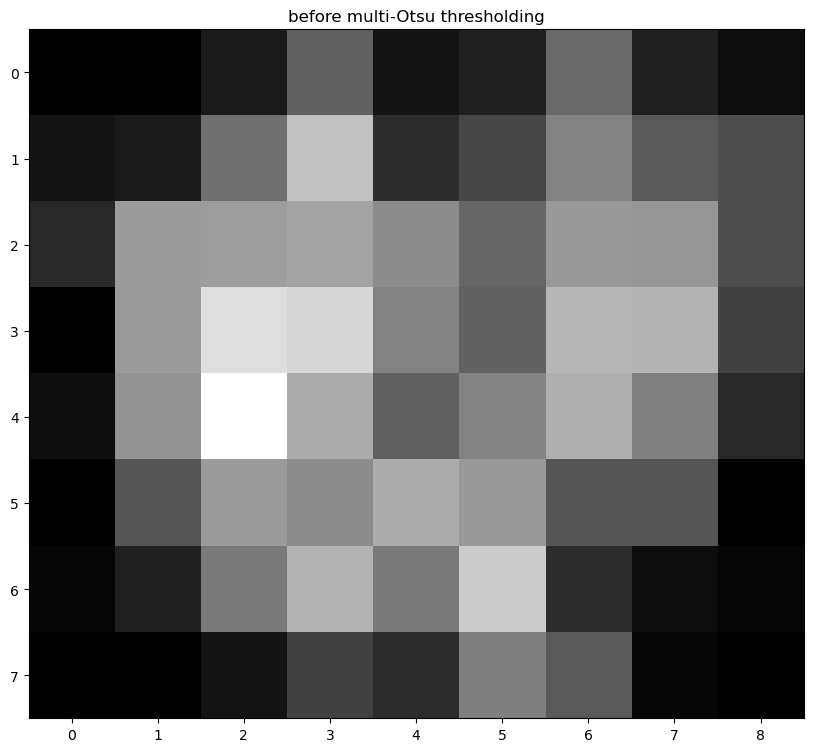

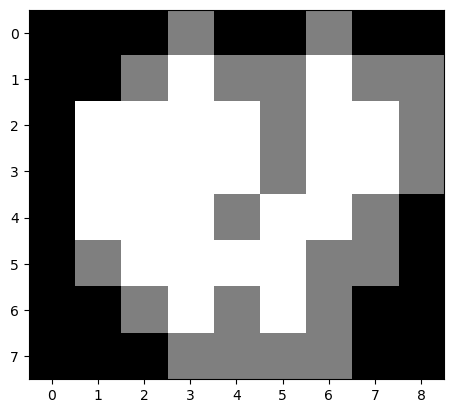

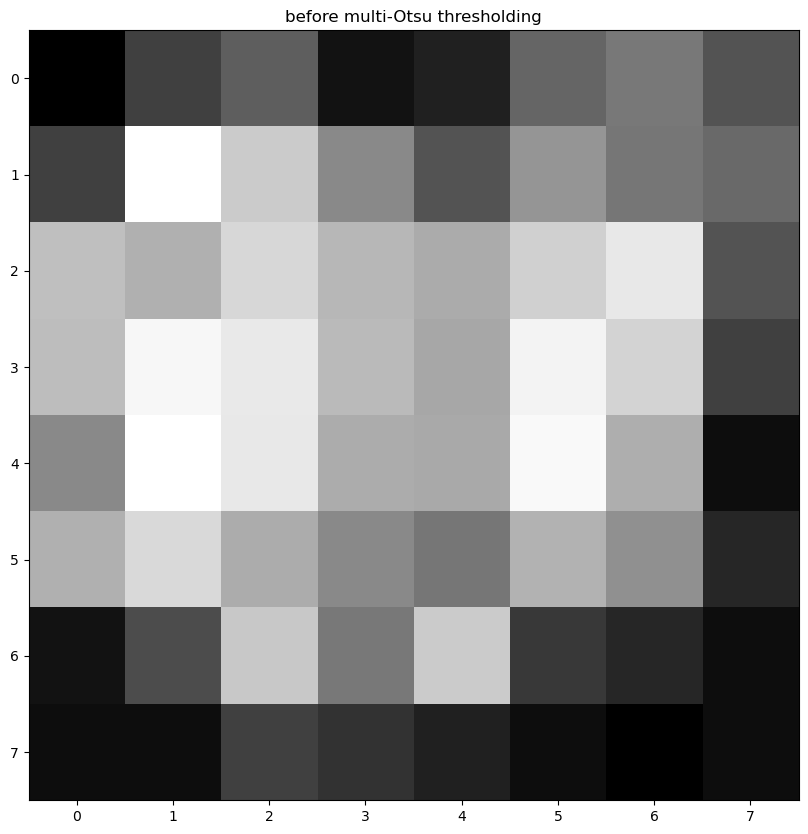

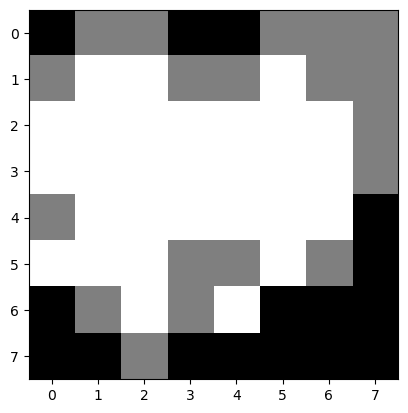

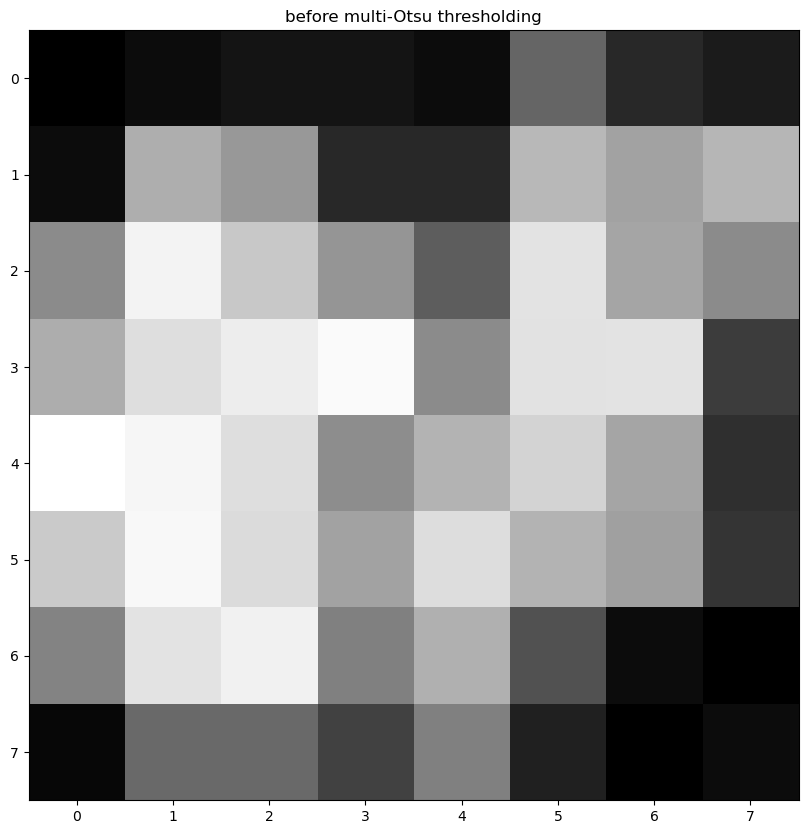

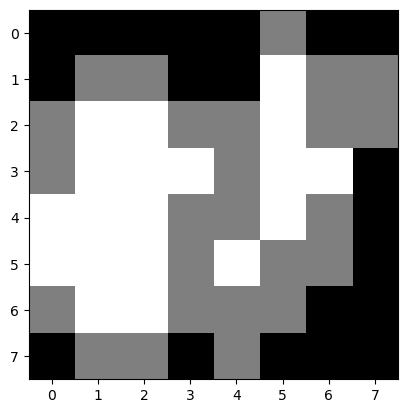

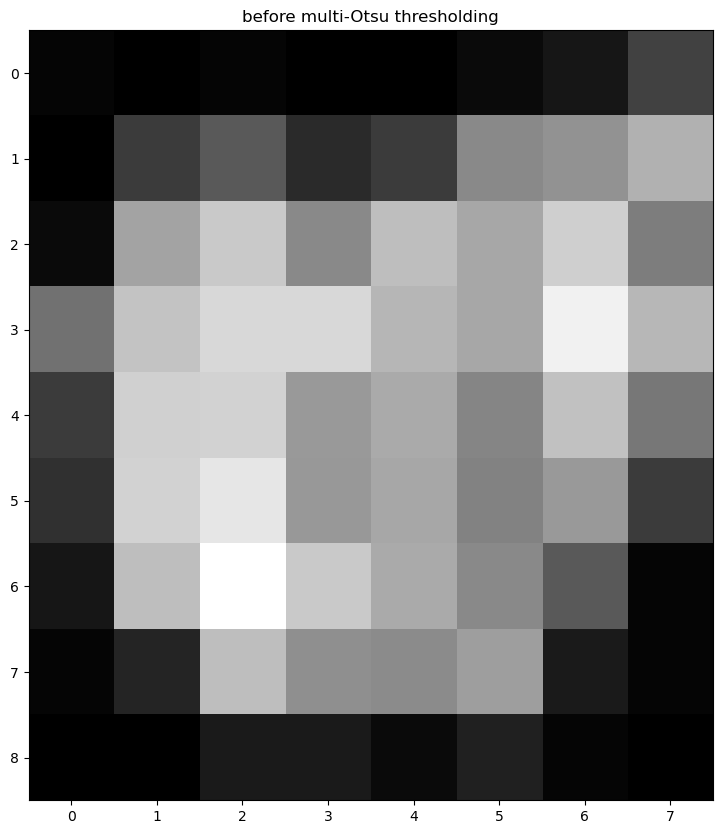

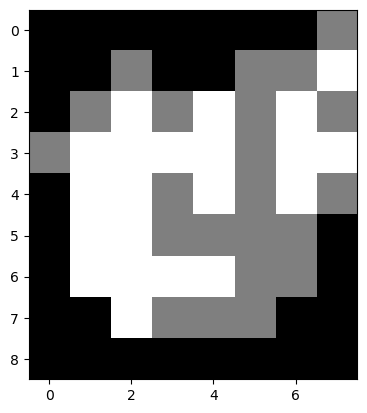

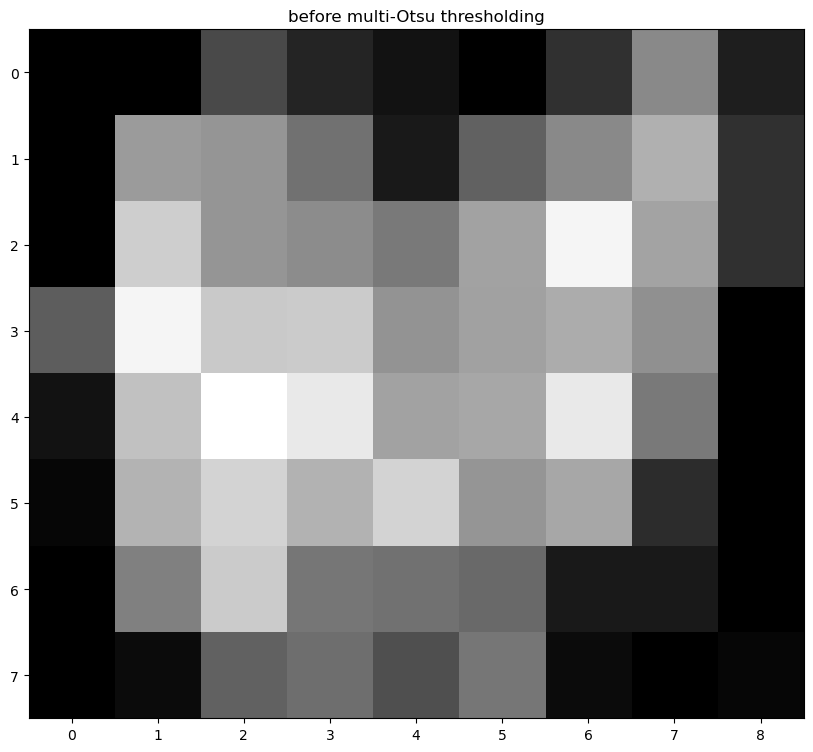

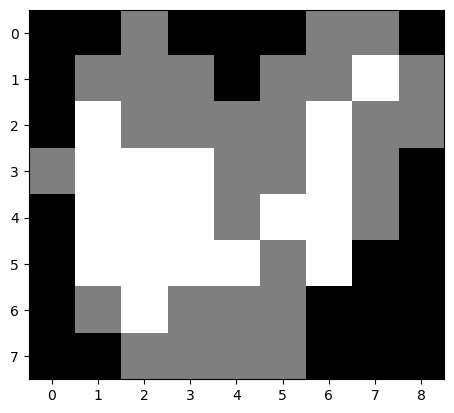

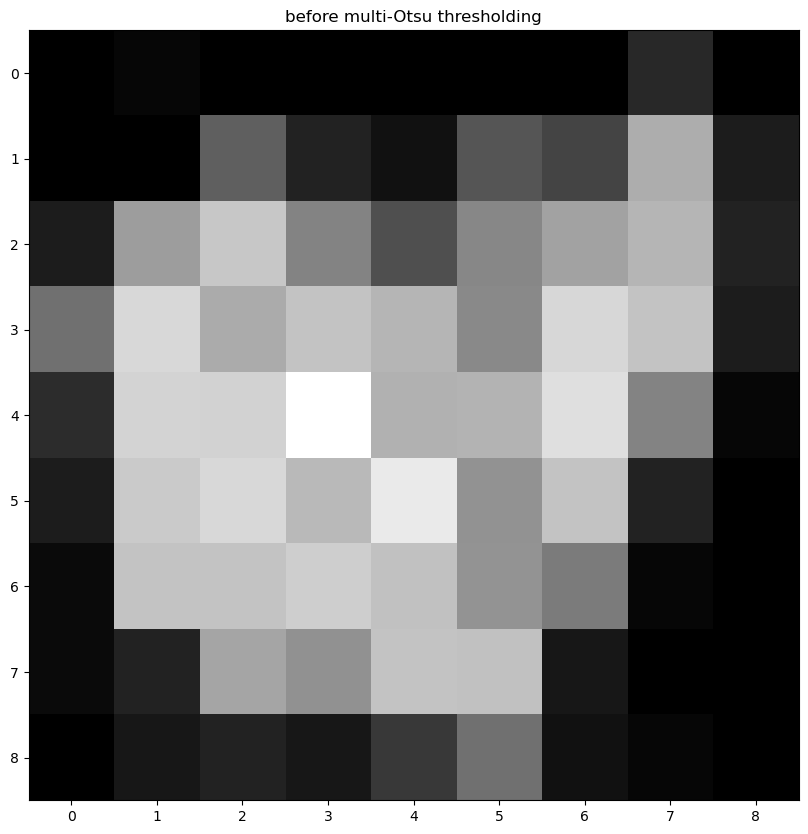

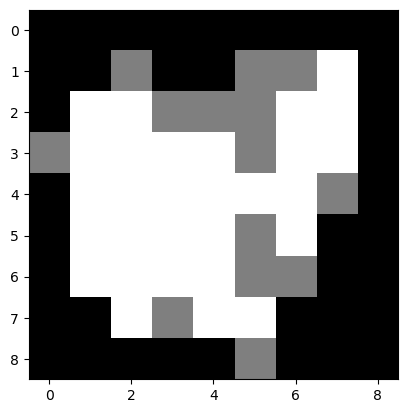

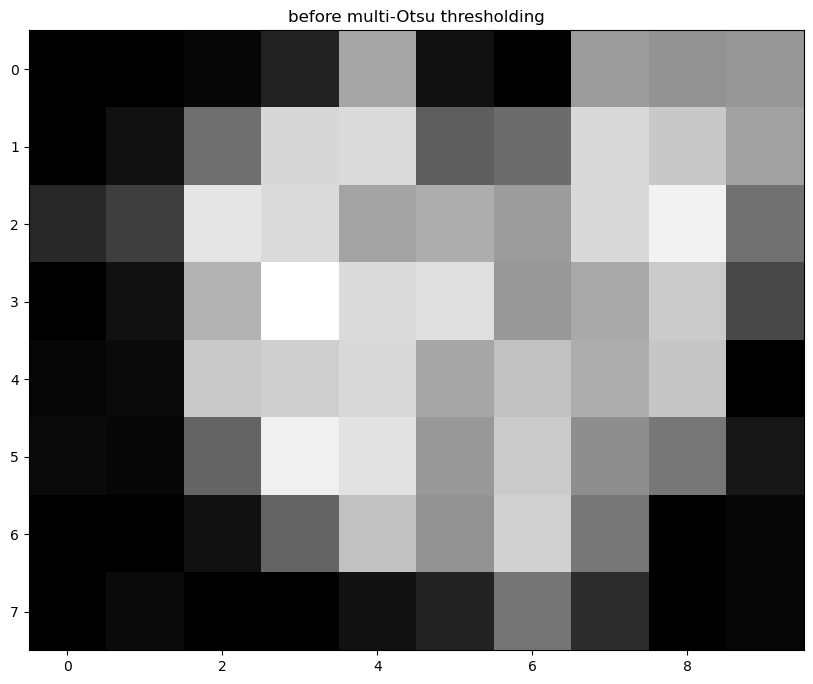

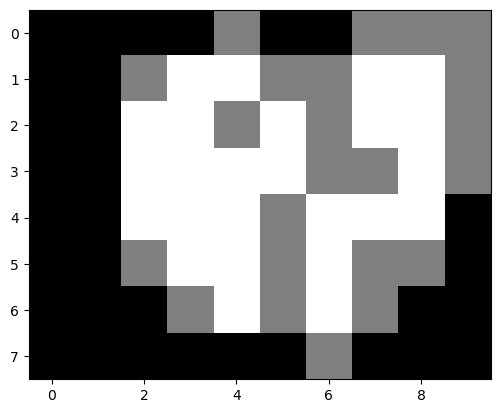

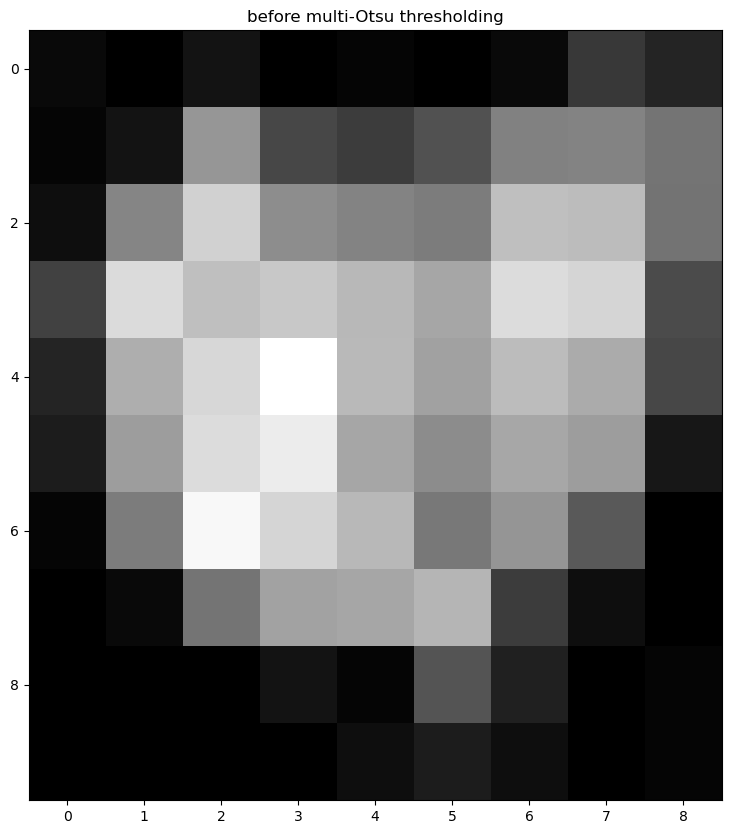

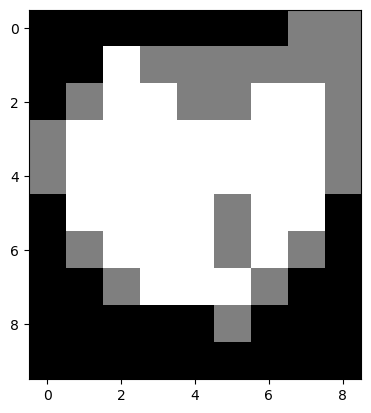

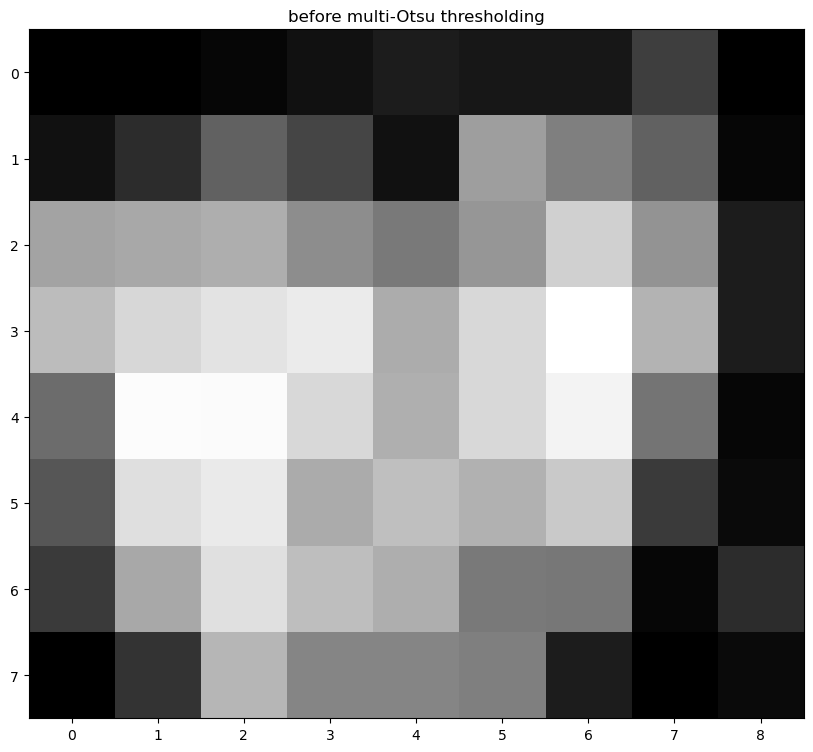

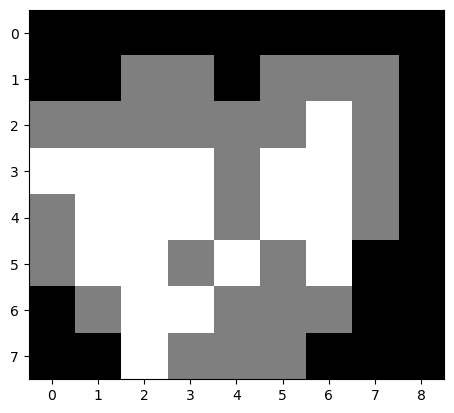

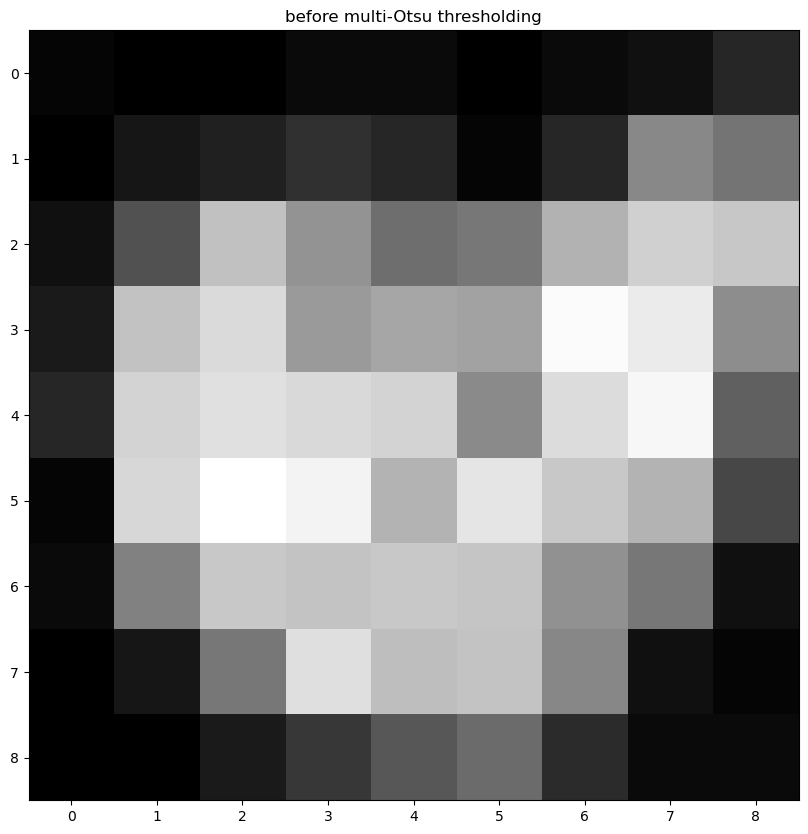

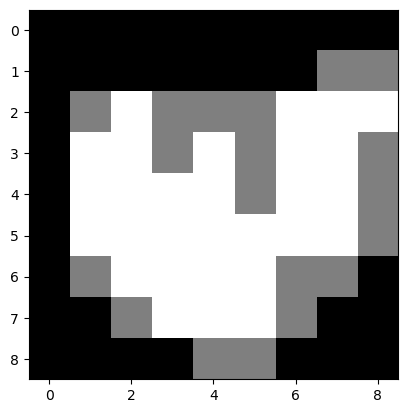

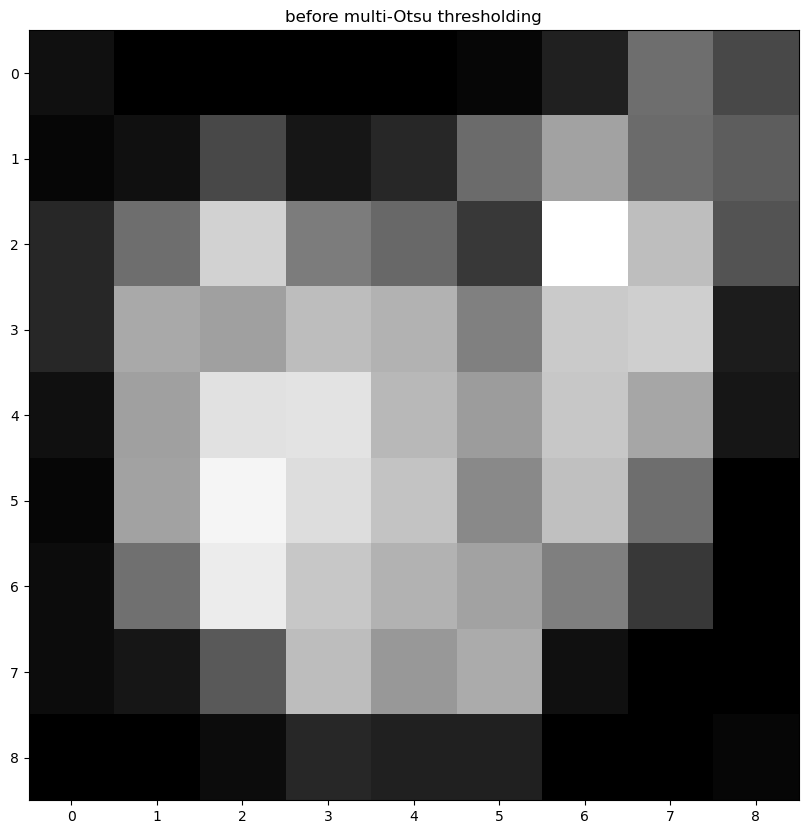

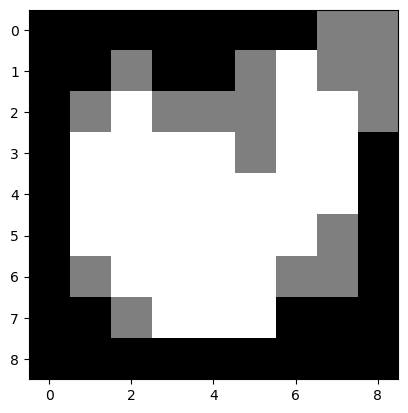

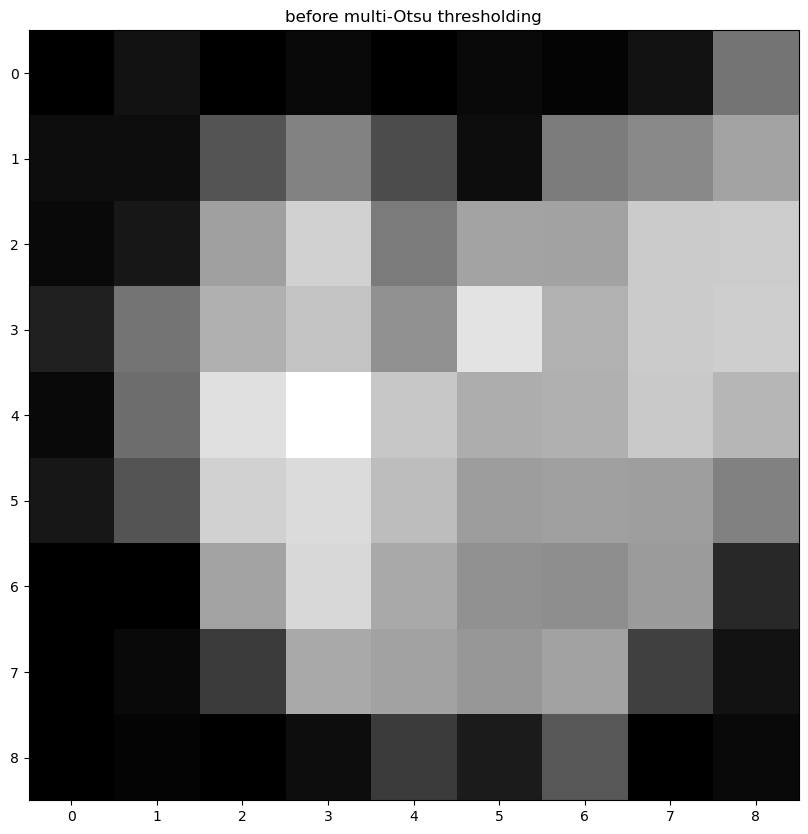

Deleting images from local for sequence 20230418-142321
Processing sequence 2/13: 20230421-065822
20230421-065822
extract images from server to local


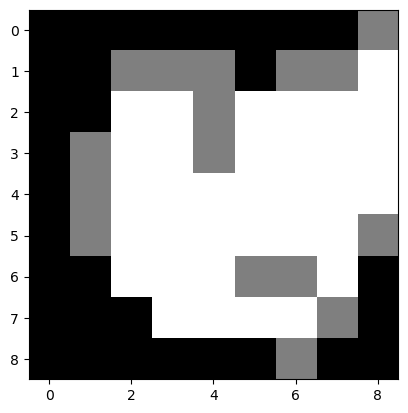

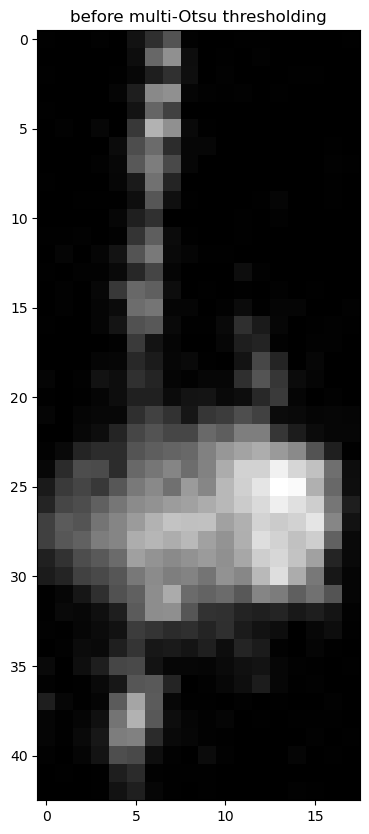

Deleting images from local for sequence 20230421-065822
Processing sequence 3/13: 20230421-073822
20230421-073822
extract images from server to local


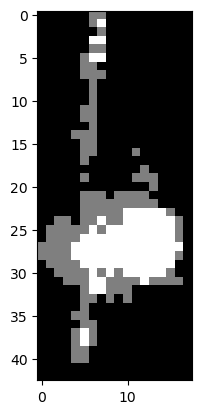

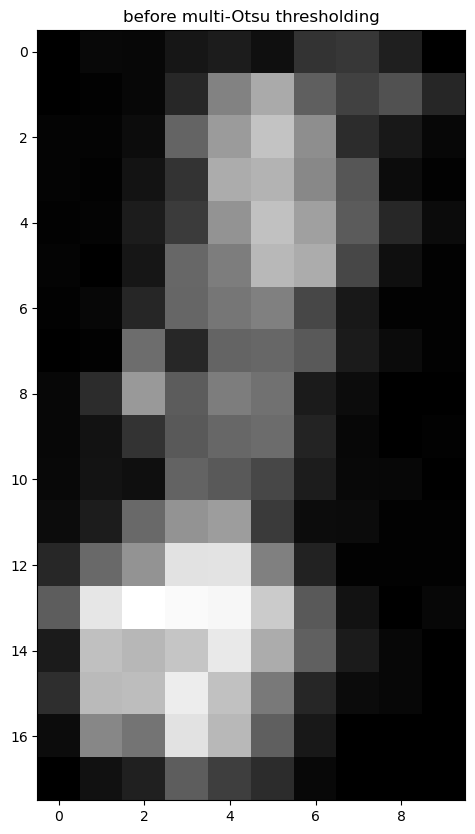

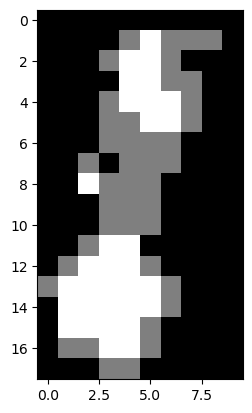

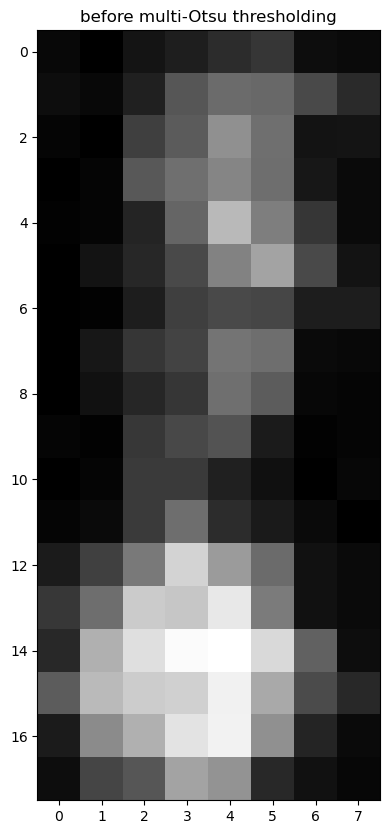

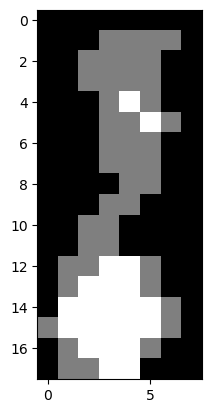

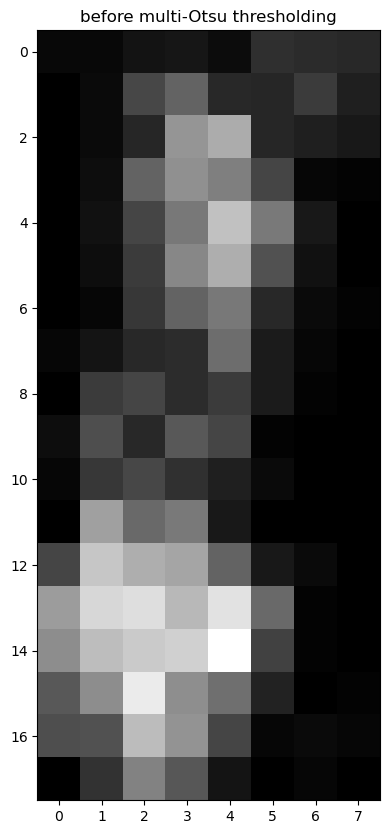

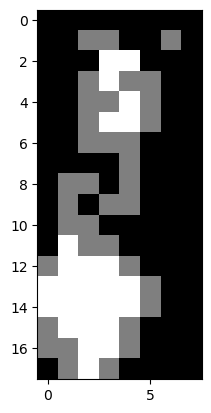

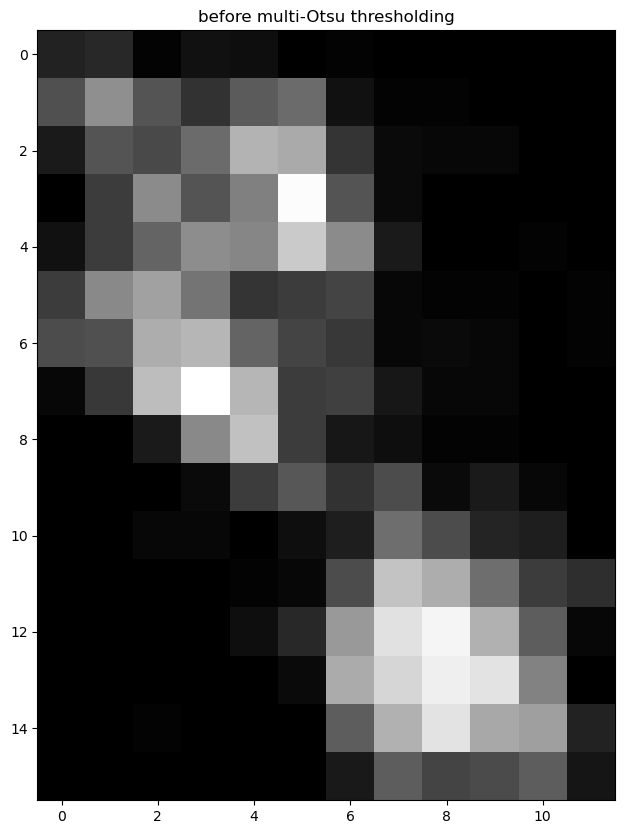

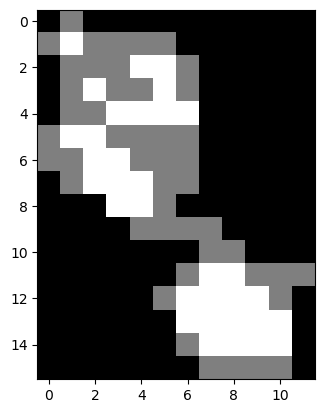

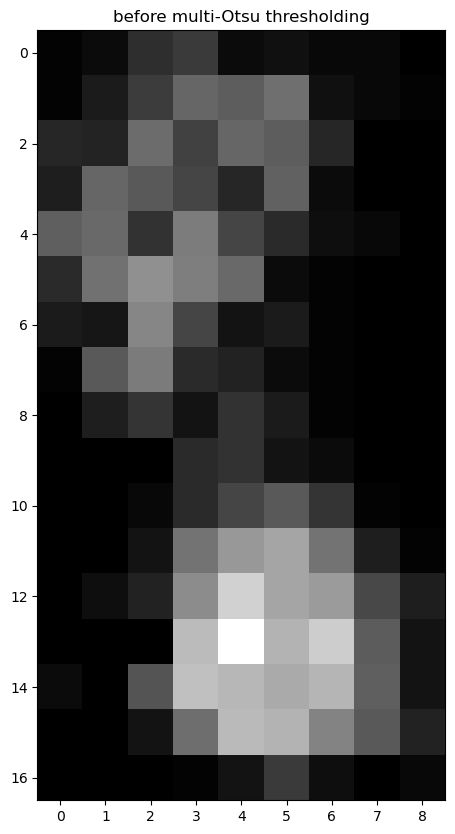

Deleting images from local for sequence 20230421-073822
Processing sequence 4/13: 20230421-185822
20230421-185822
extract images from server to local


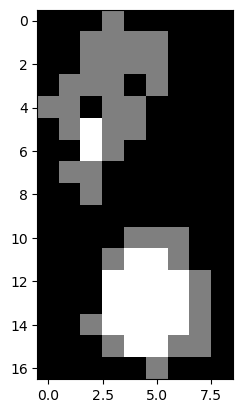

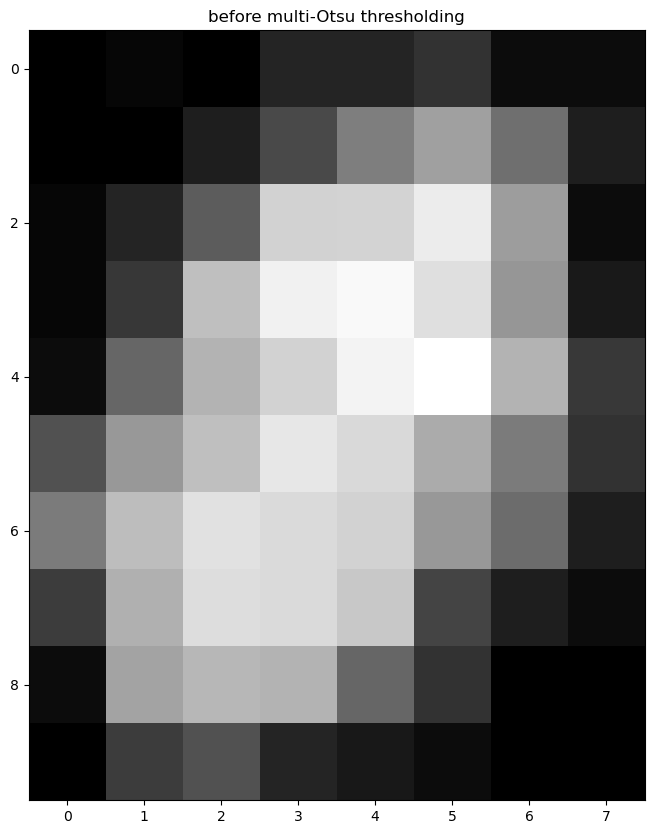

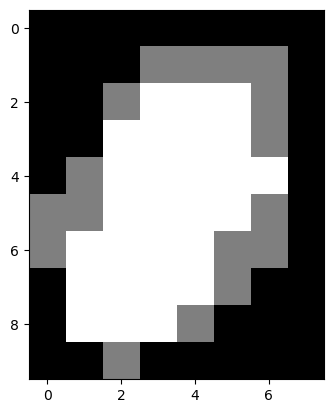

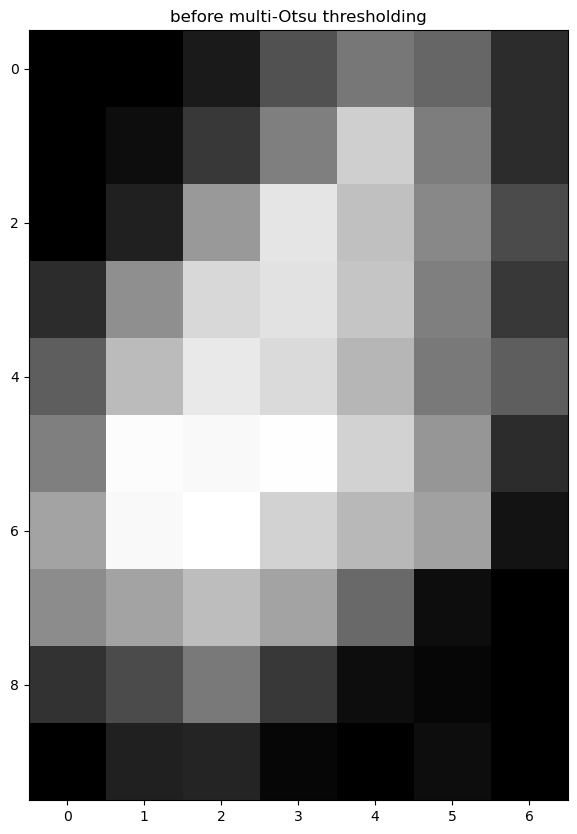

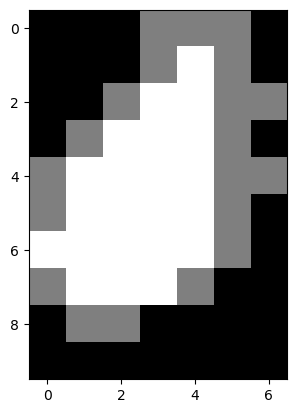

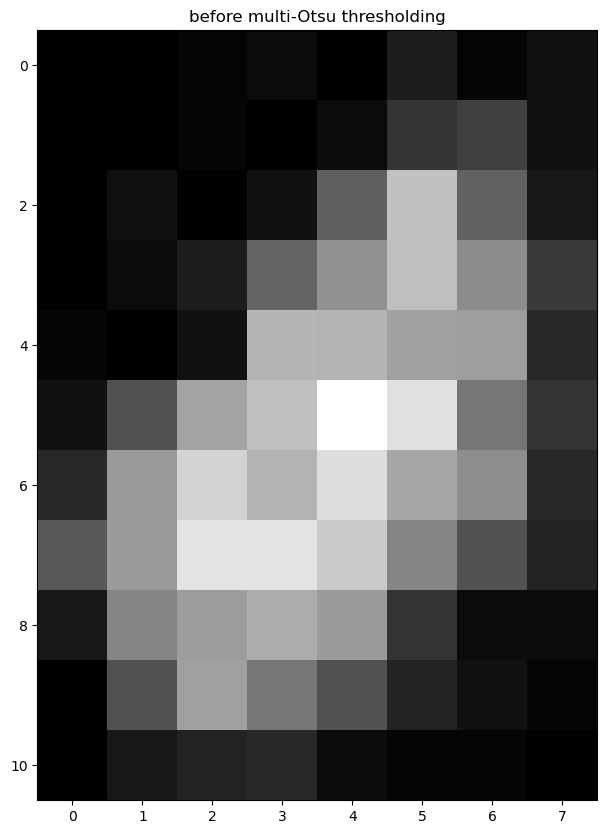

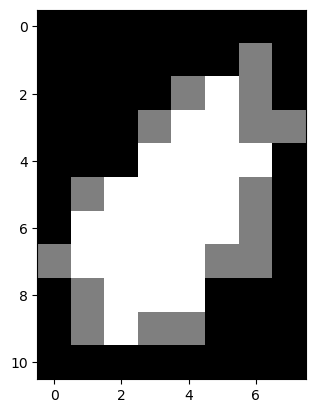

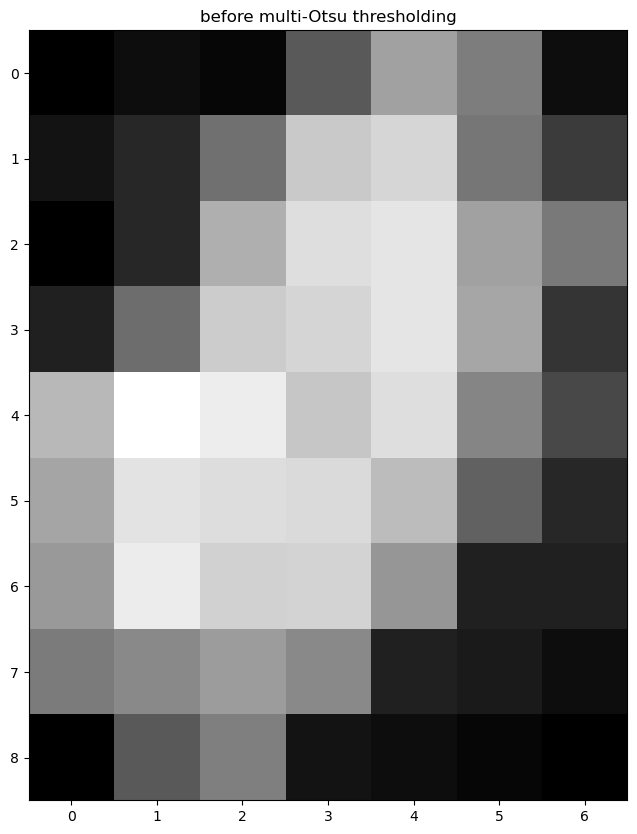

Deleting images from local for sequence 20230421-185822
Processing sequence 5/13: 20230423-001139
20230423-001139
extract images from server to local


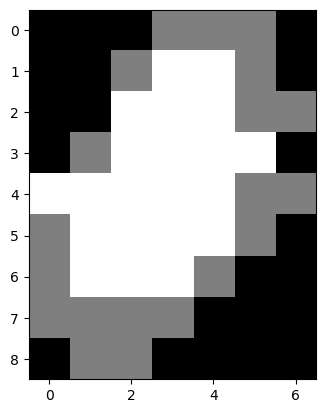

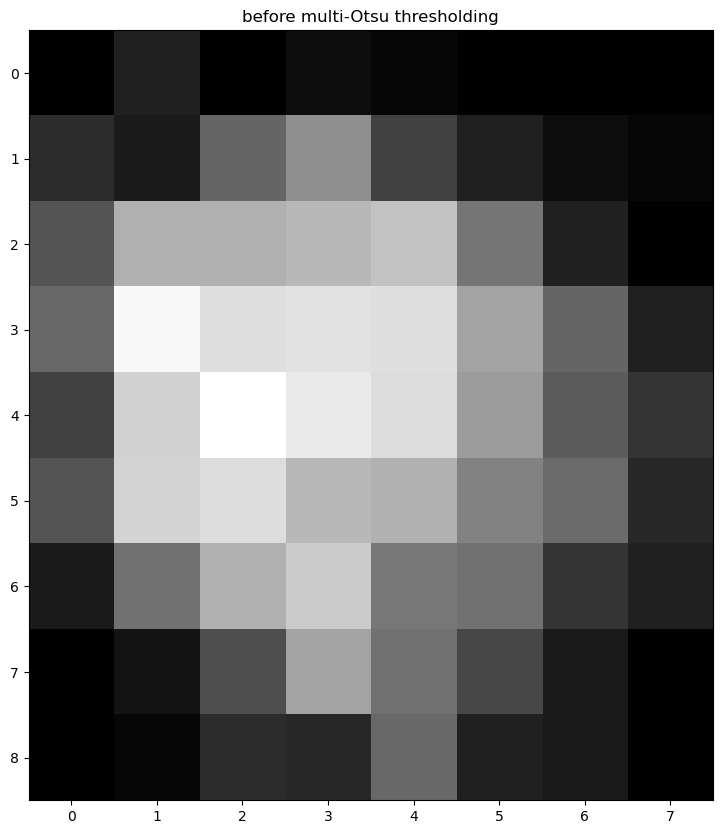

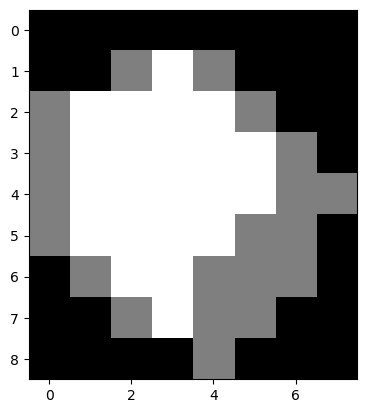

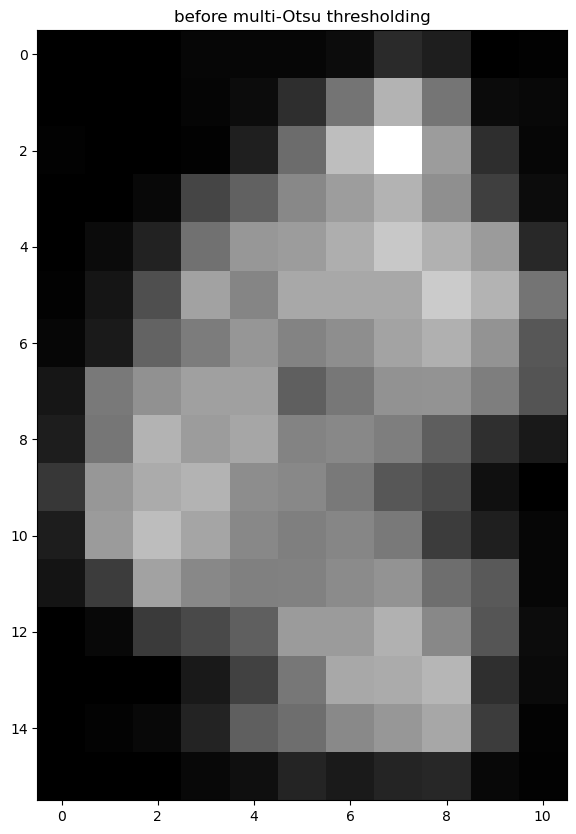

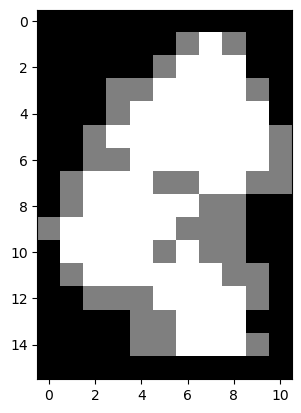

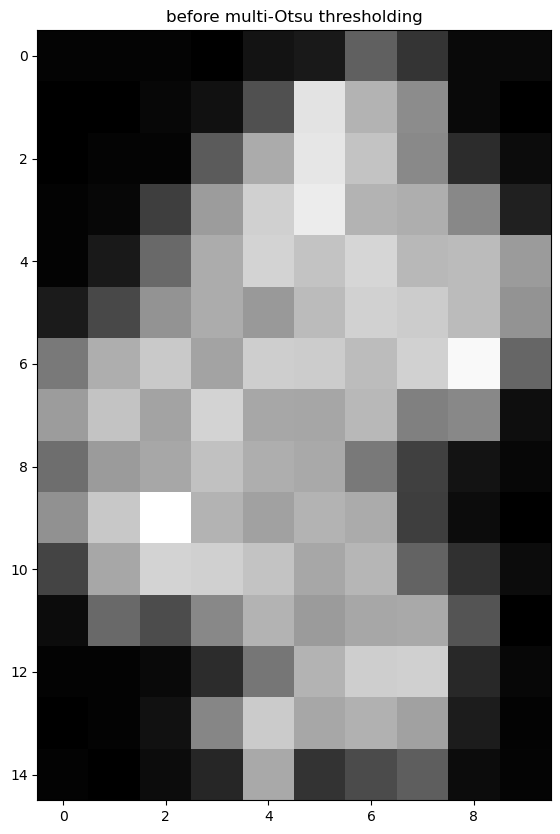

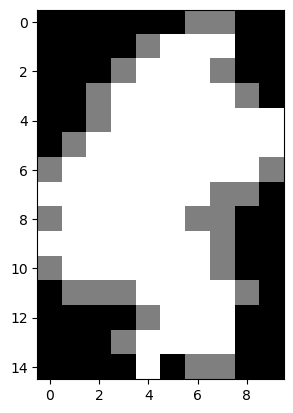

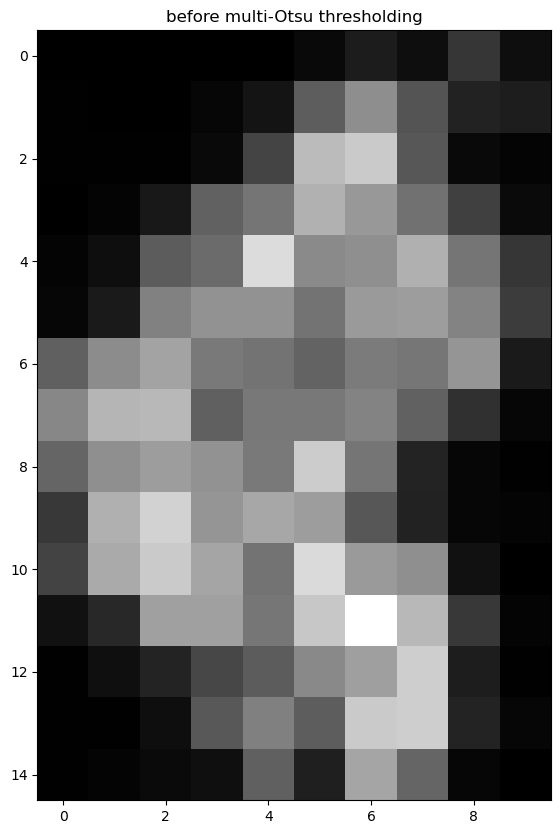

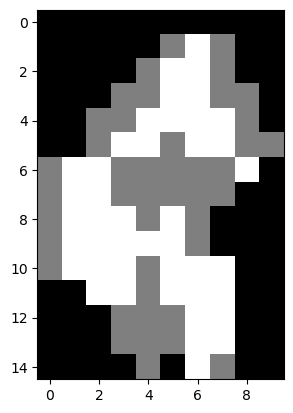

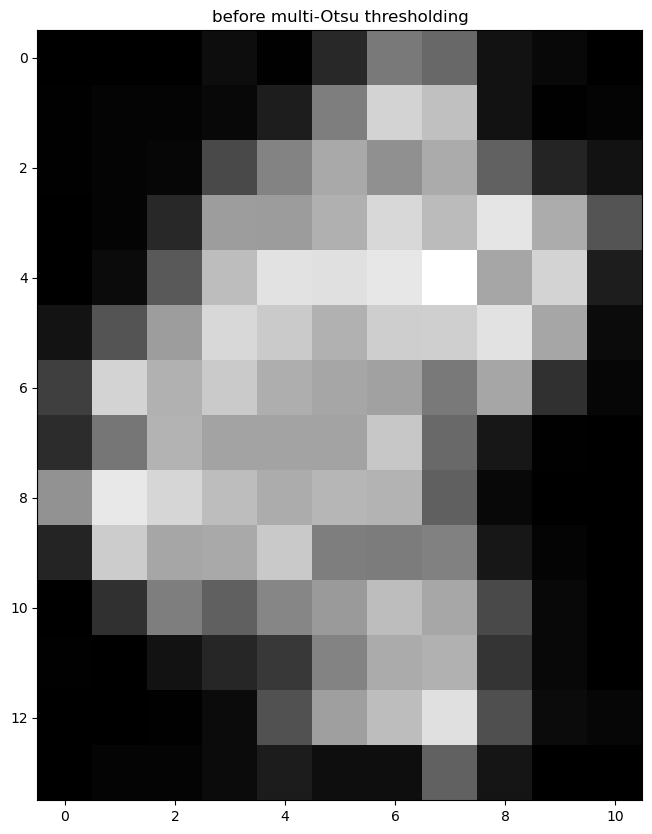

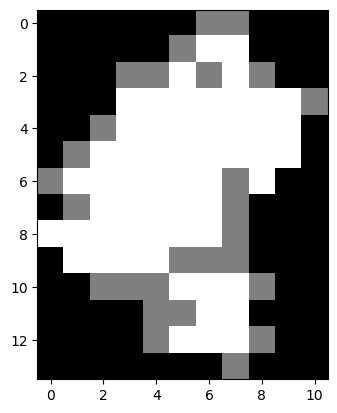

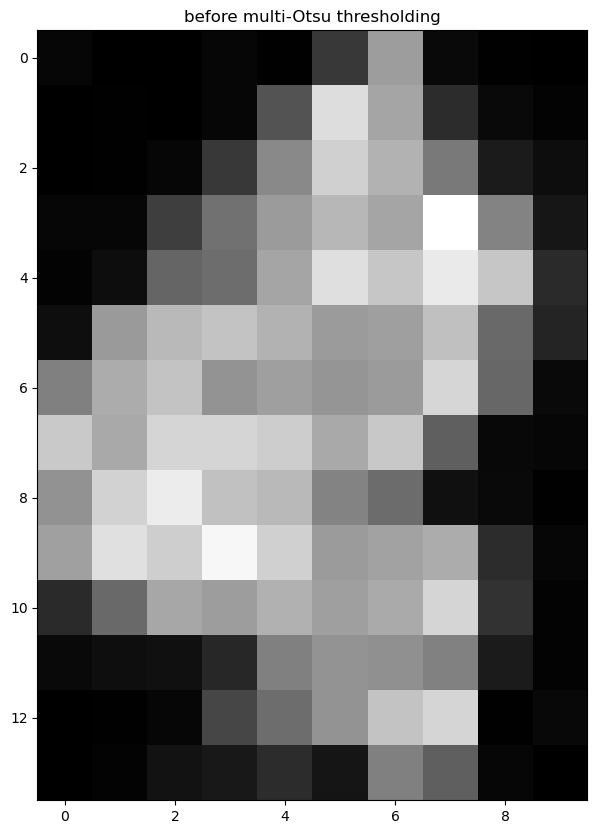

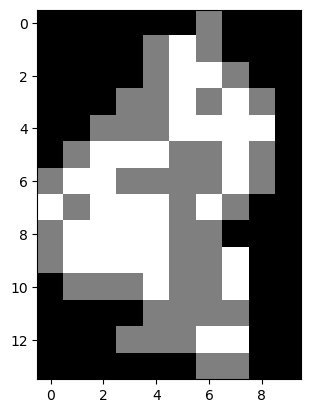

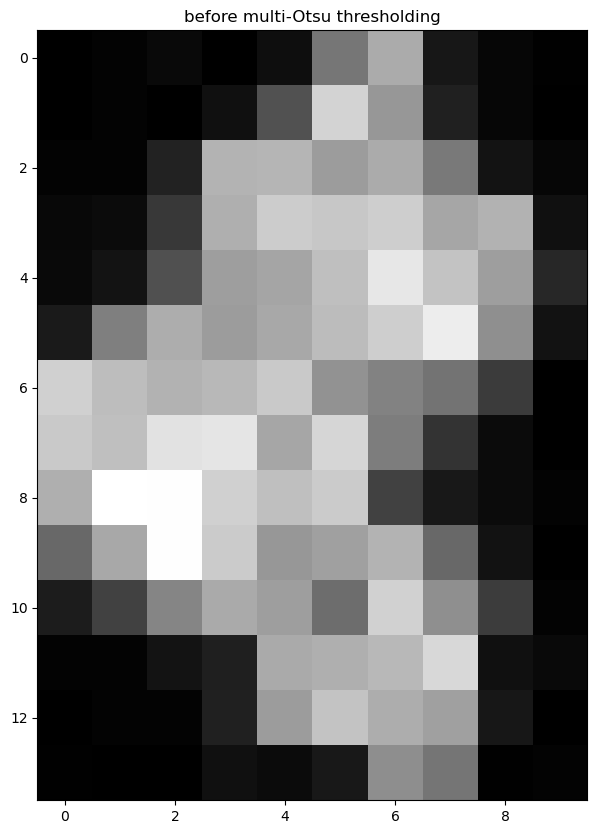

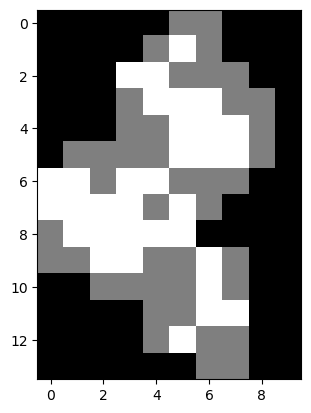

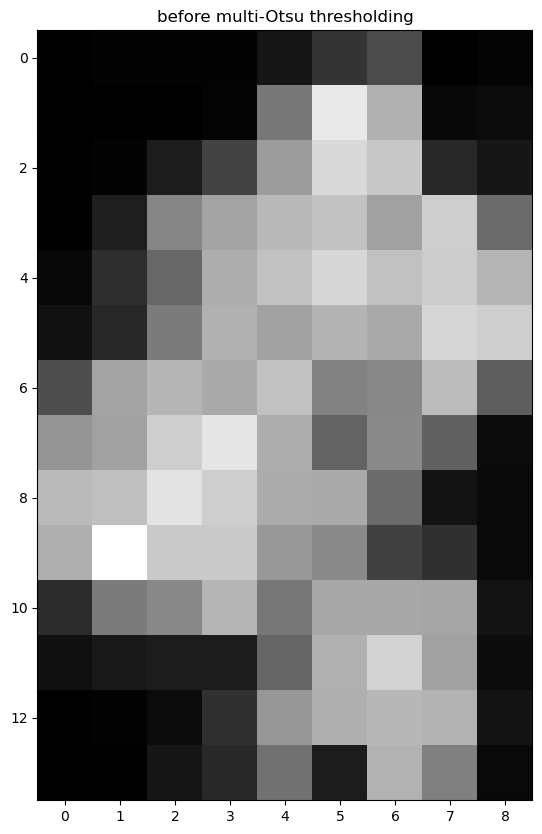

Deleting images from local for sequence 20230423-001139
Processing sequence 6/13: 20230423-181011
20230423-181011
extract images from server to local


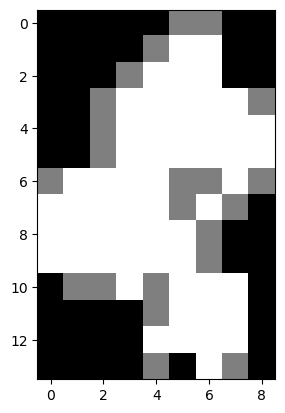

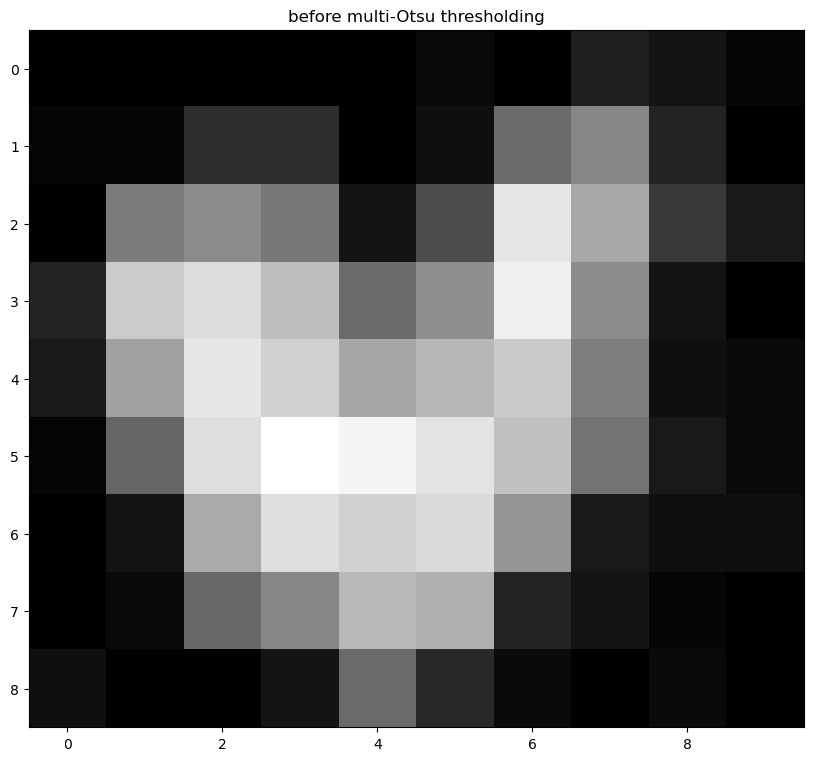

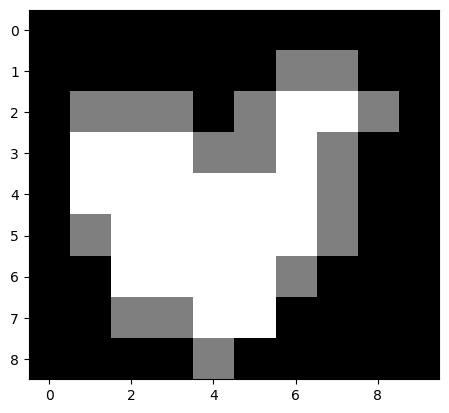

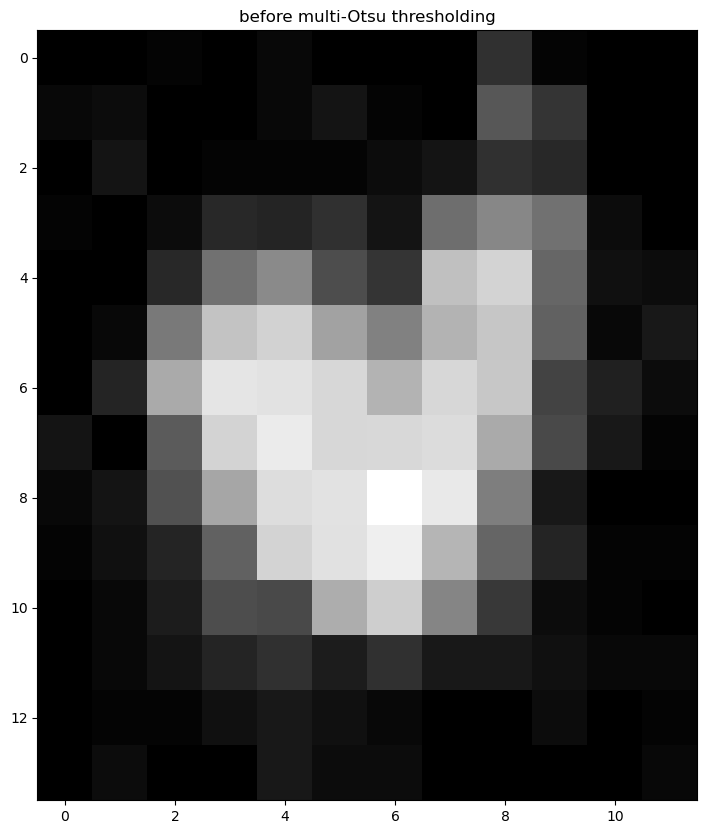

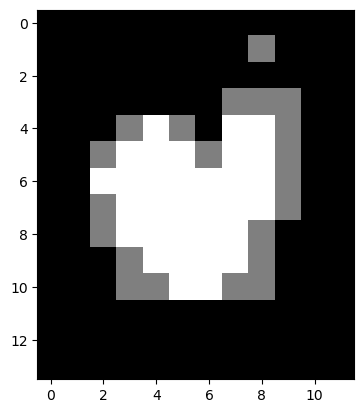

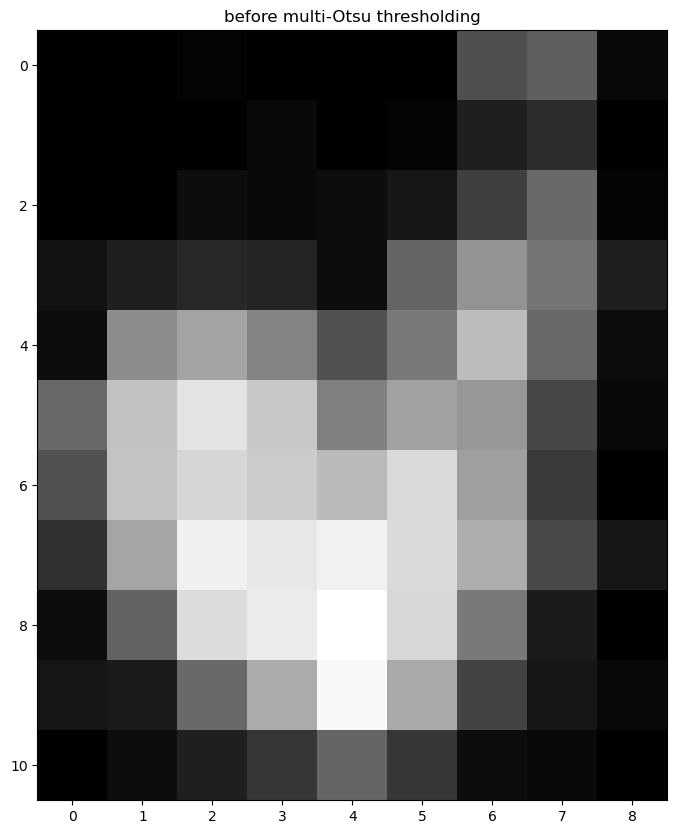

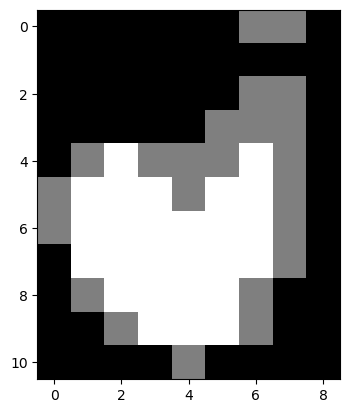

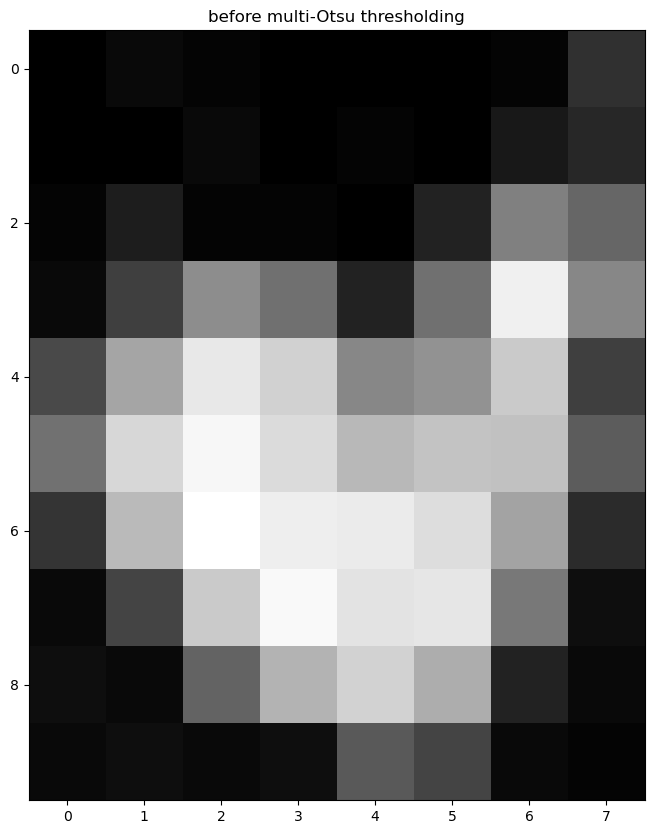

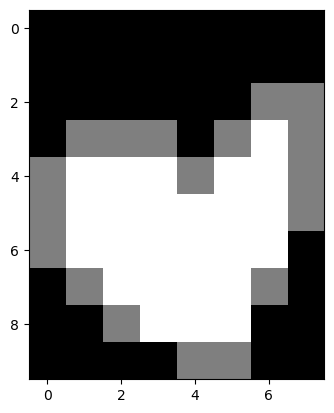

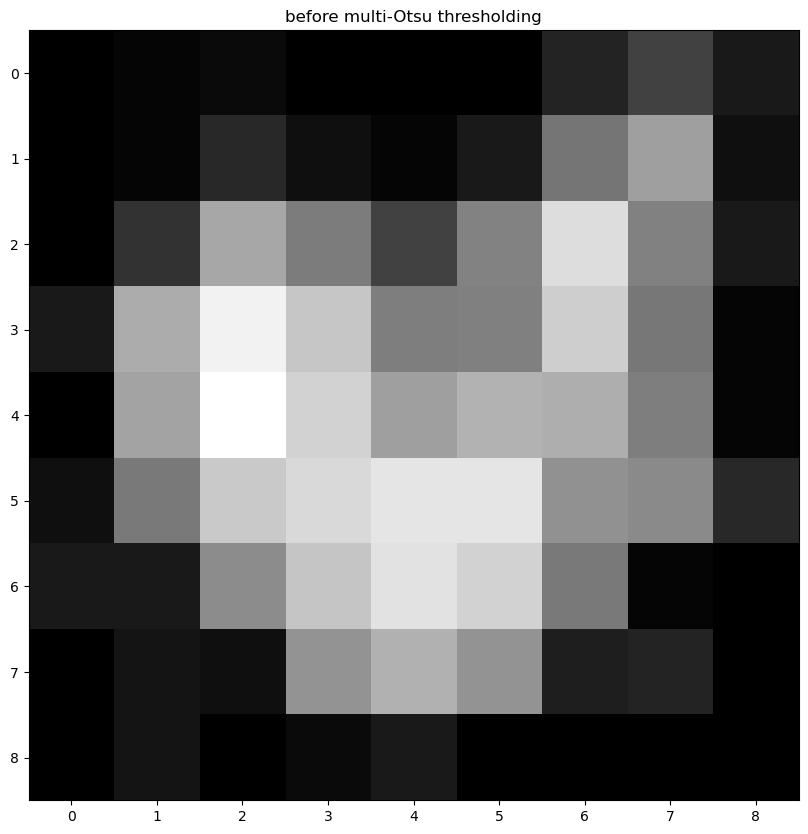

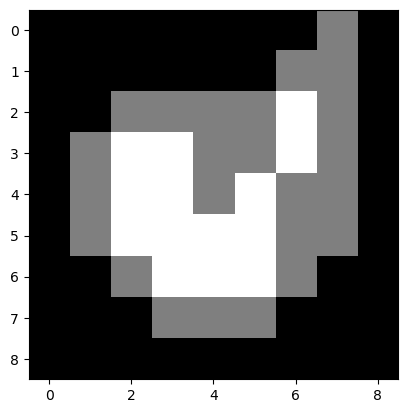

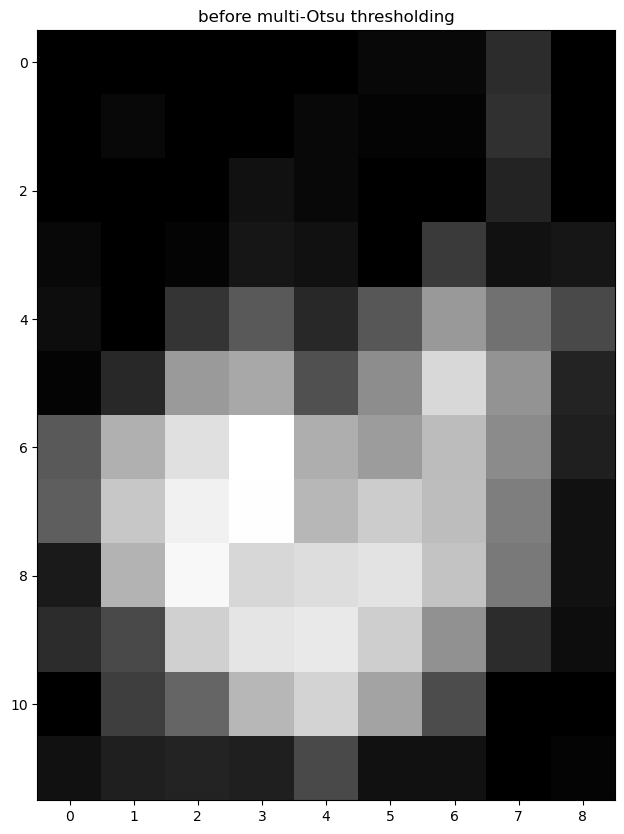

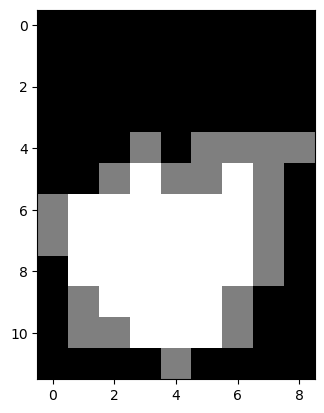

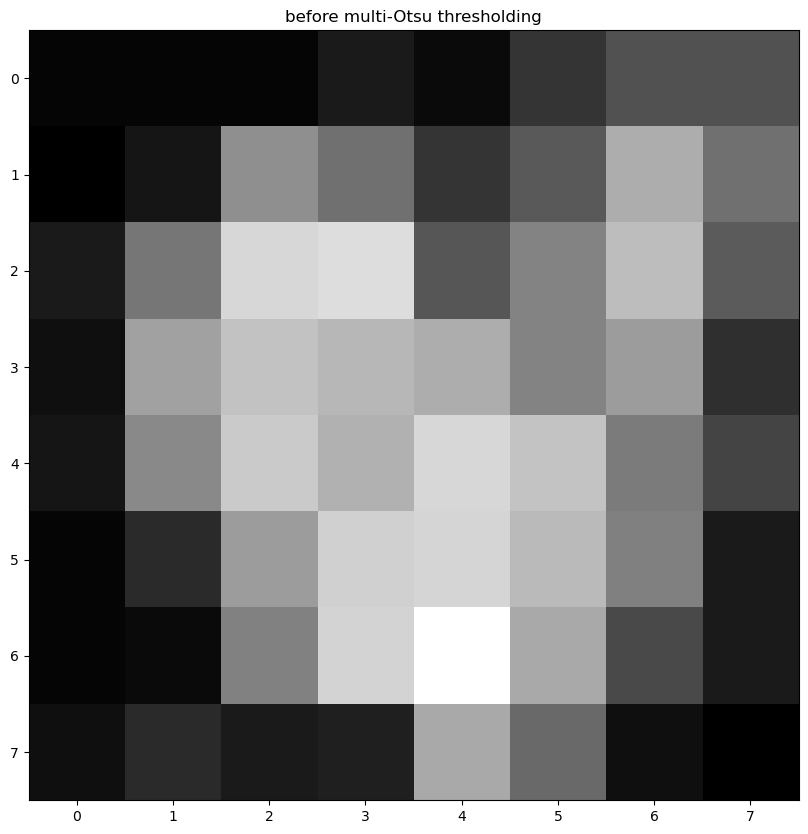

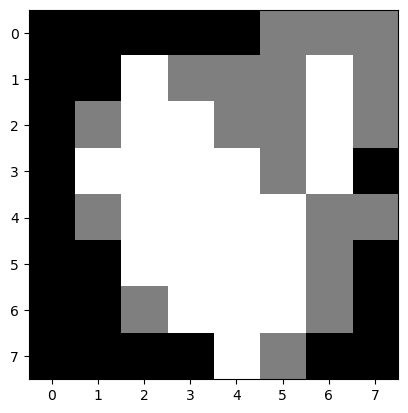

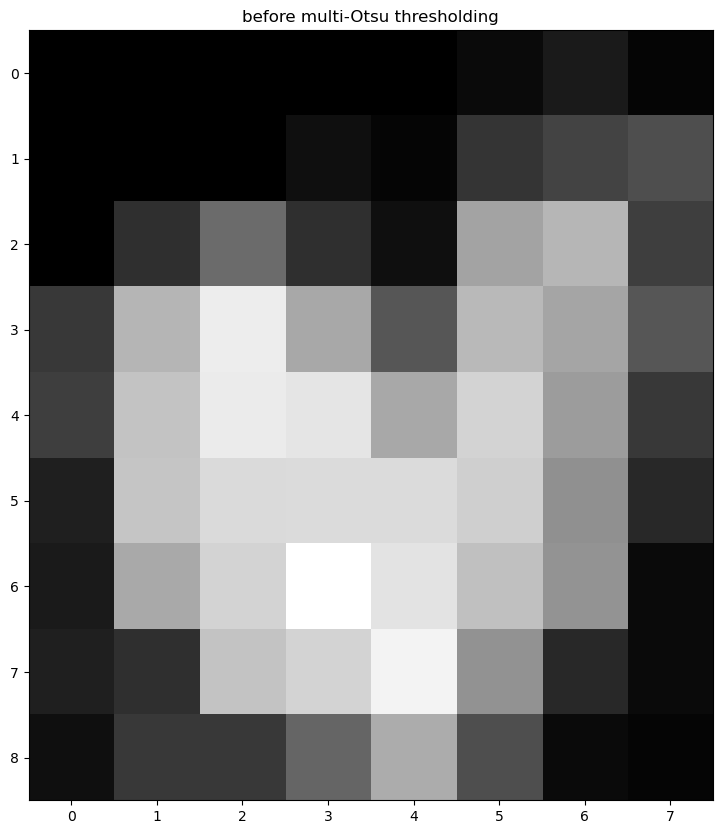

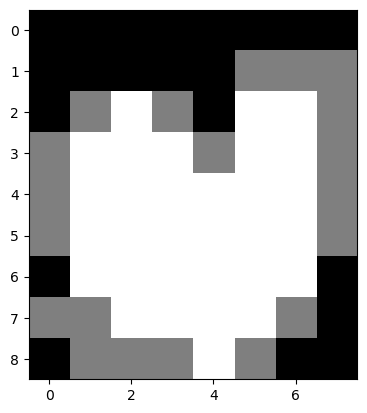

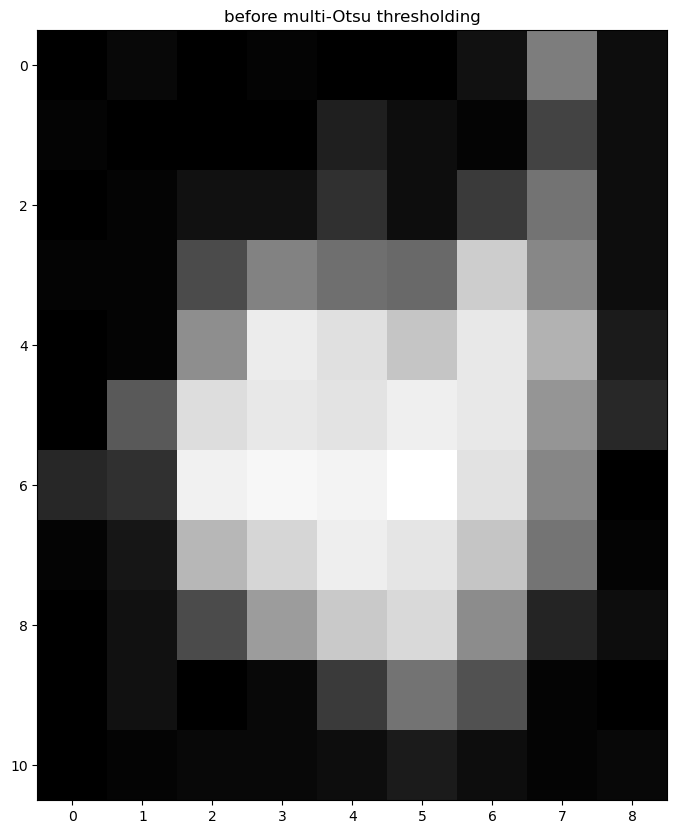

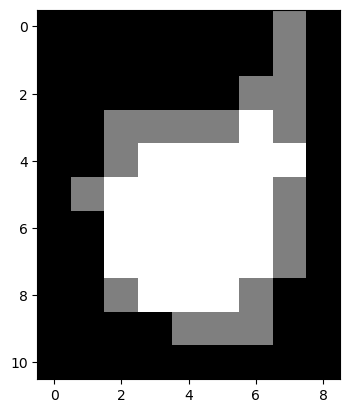

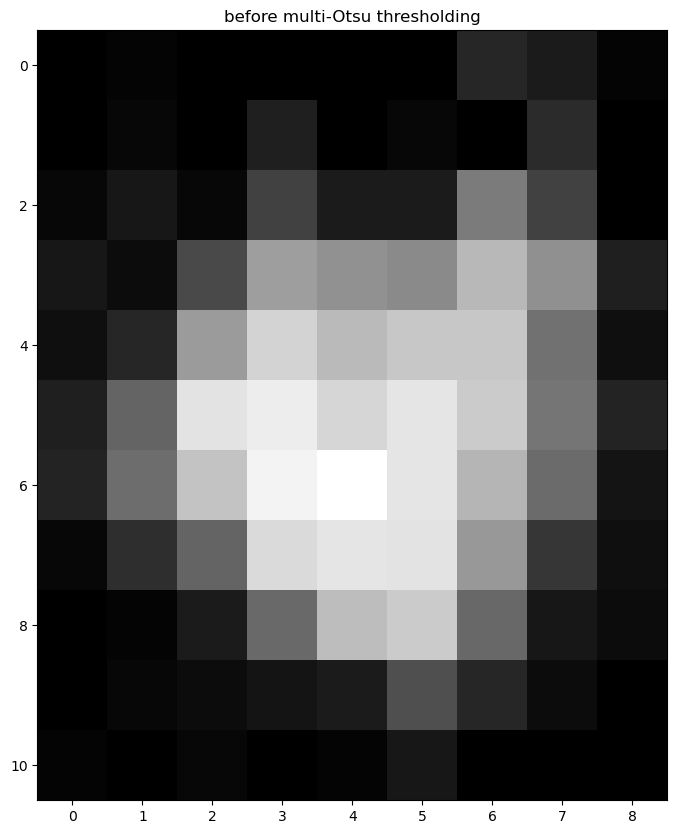

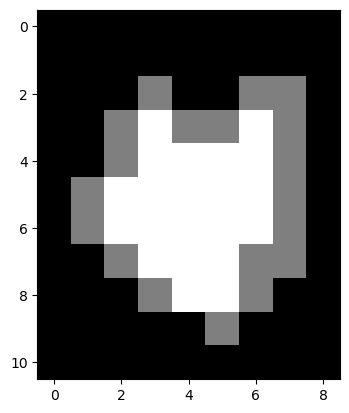

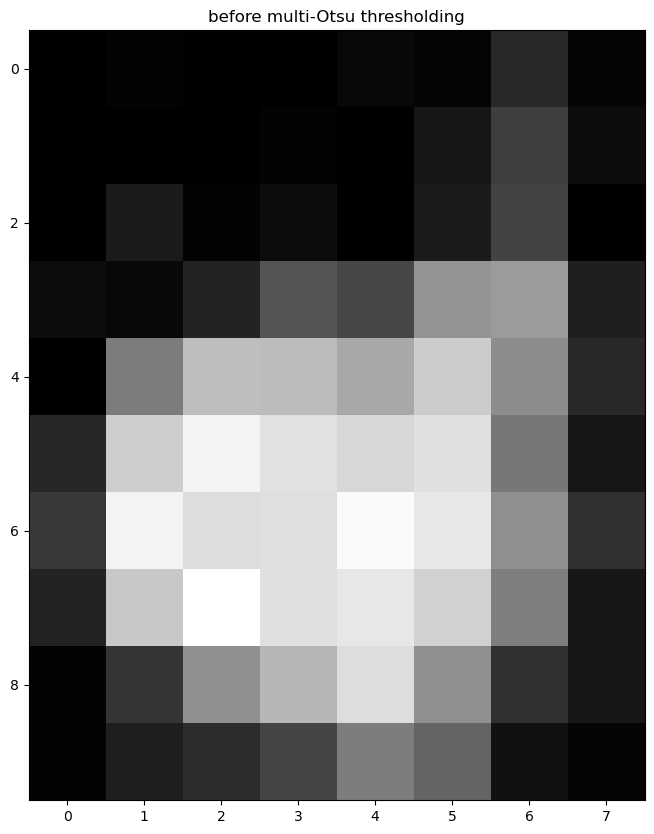

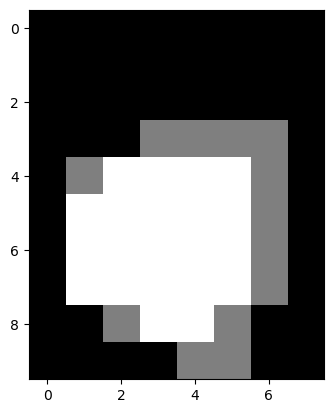

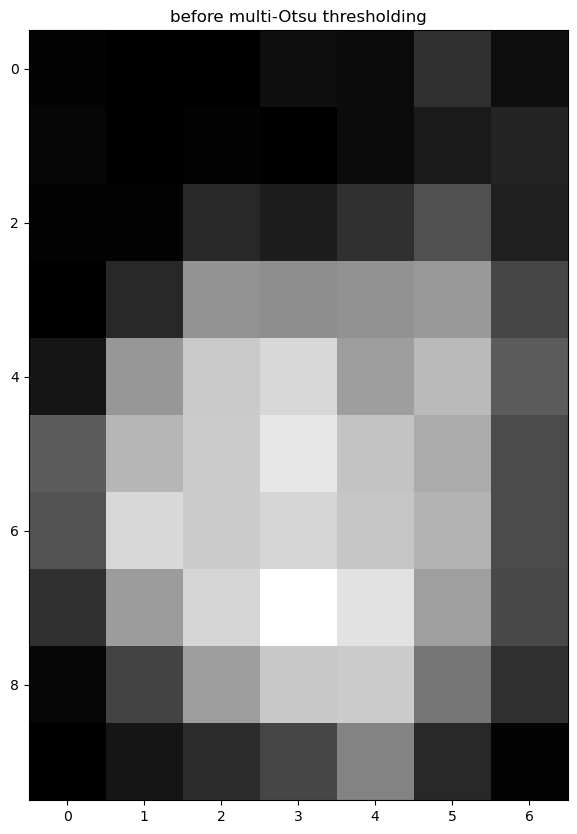

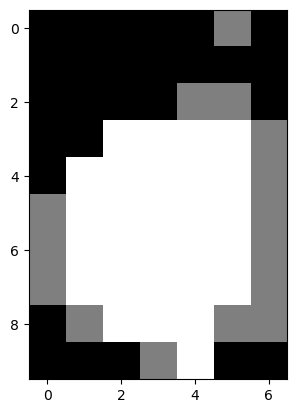

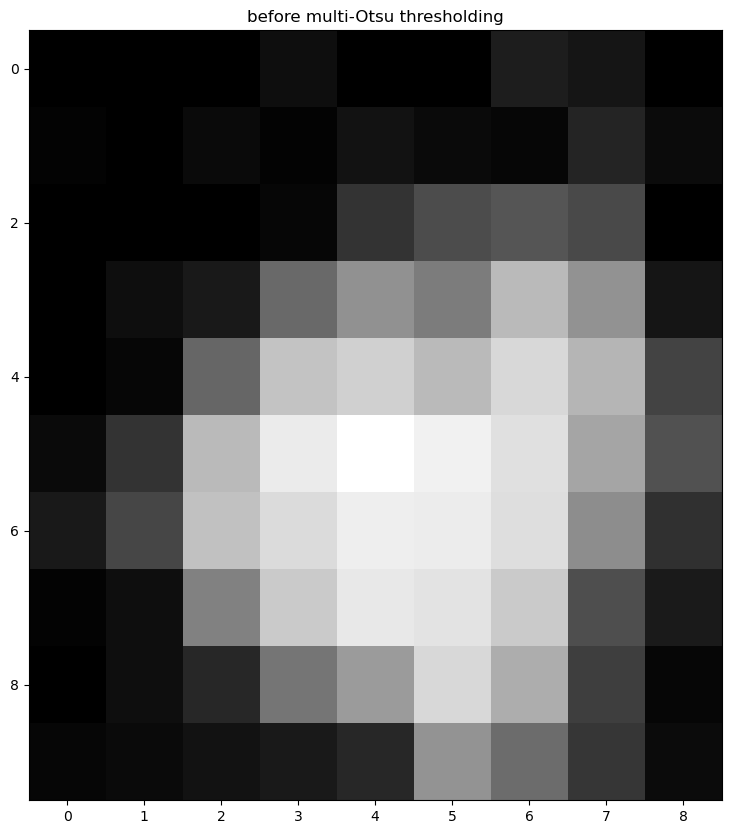

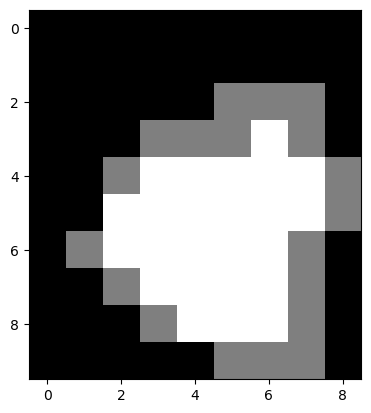

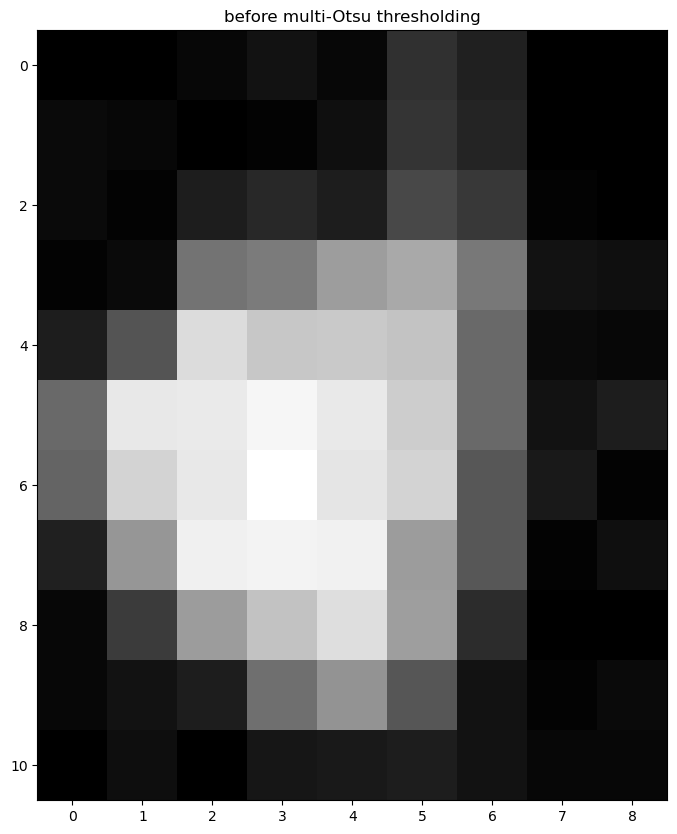

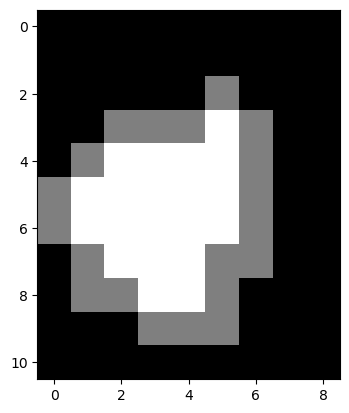

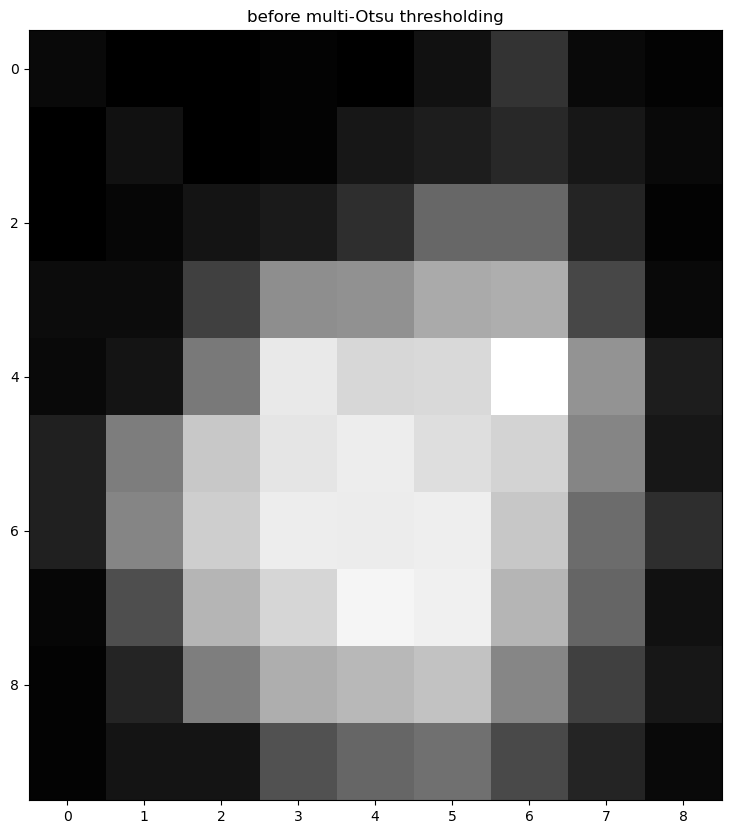

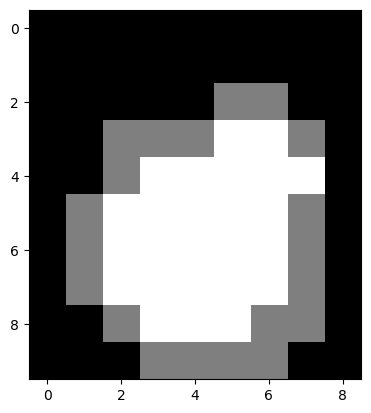

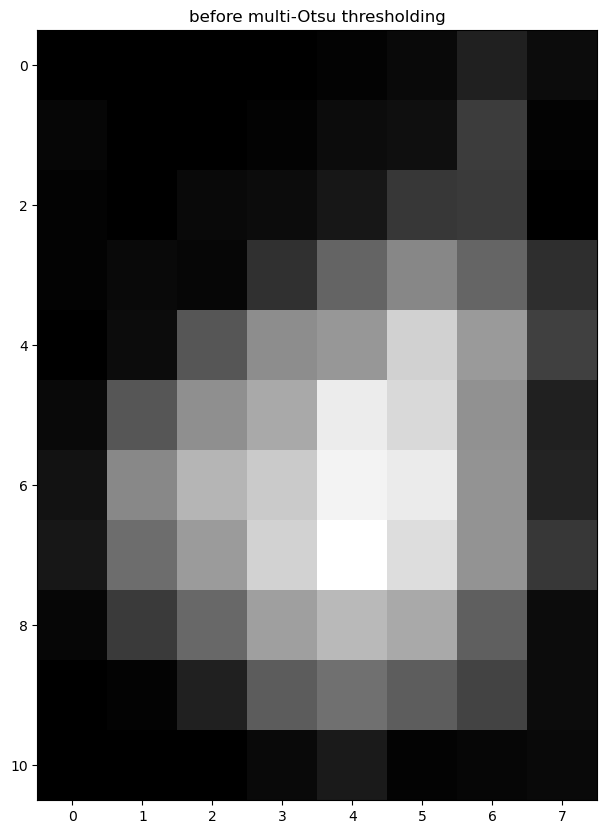

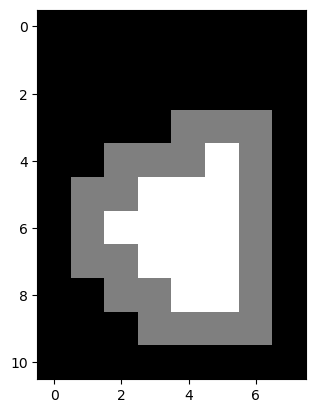

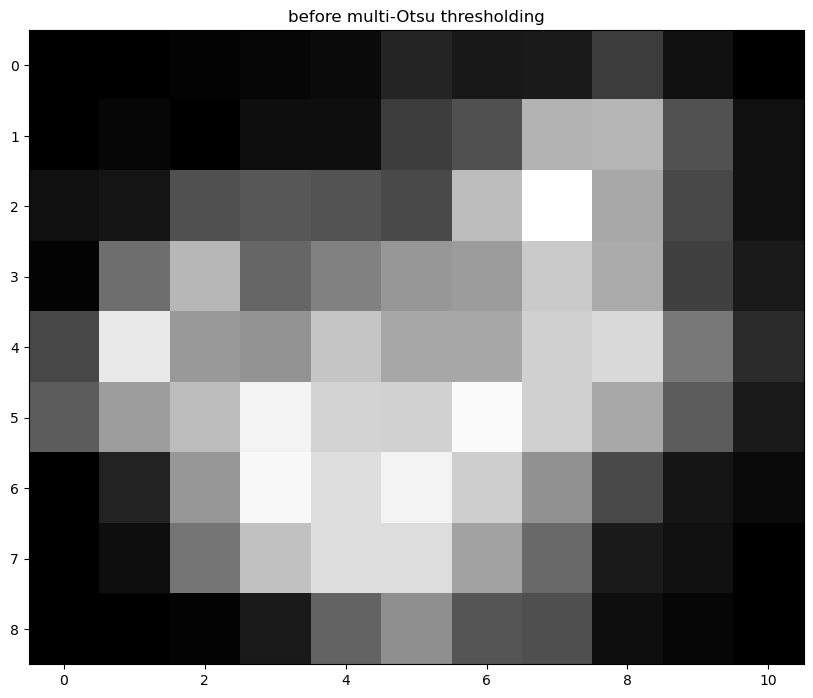

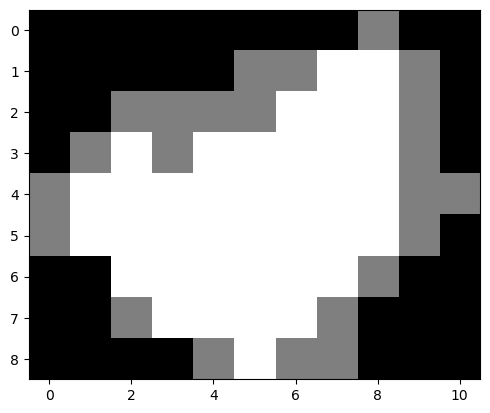

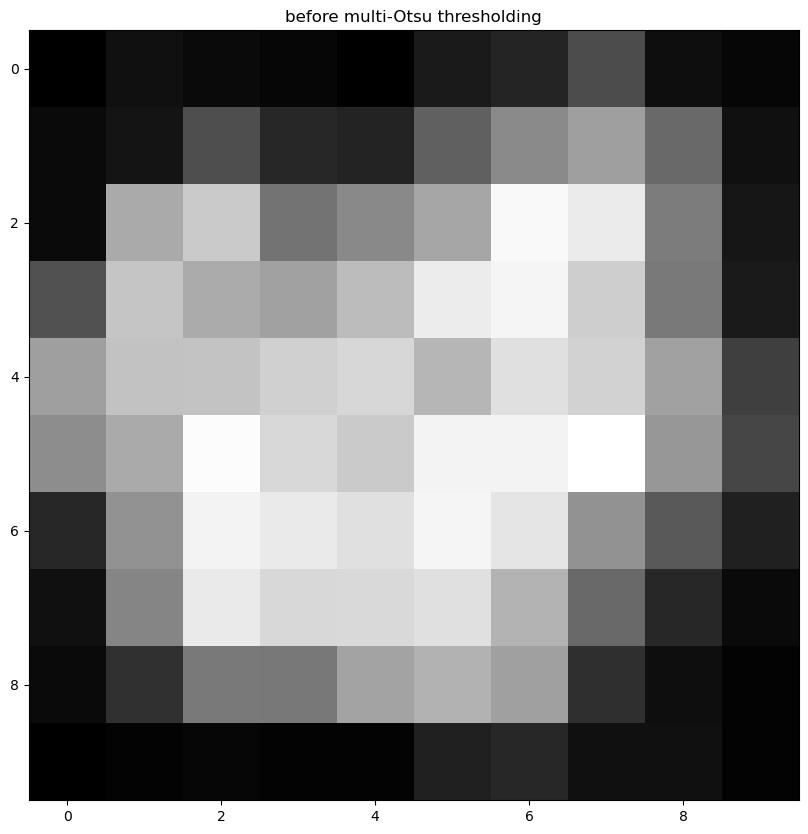

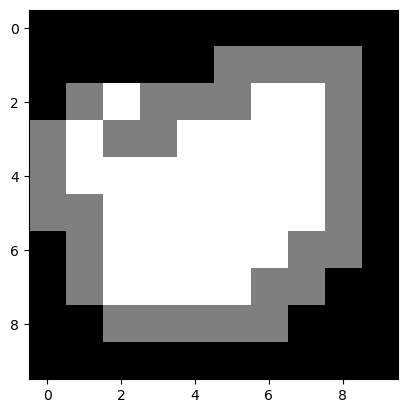

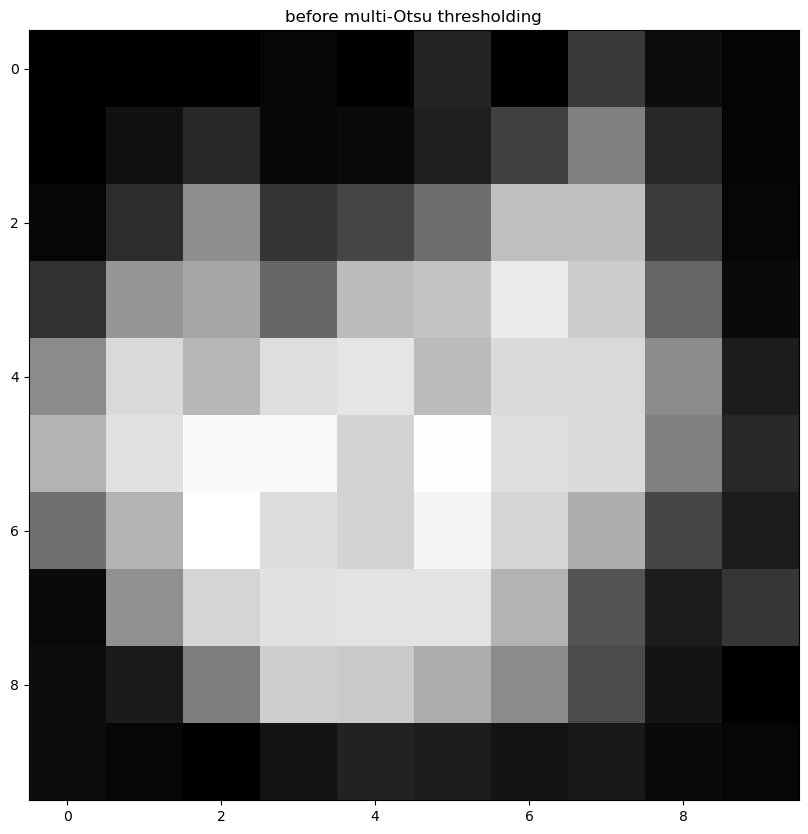

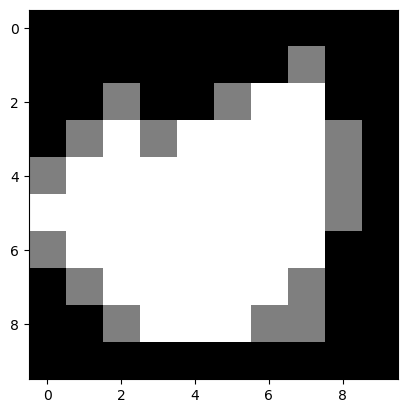

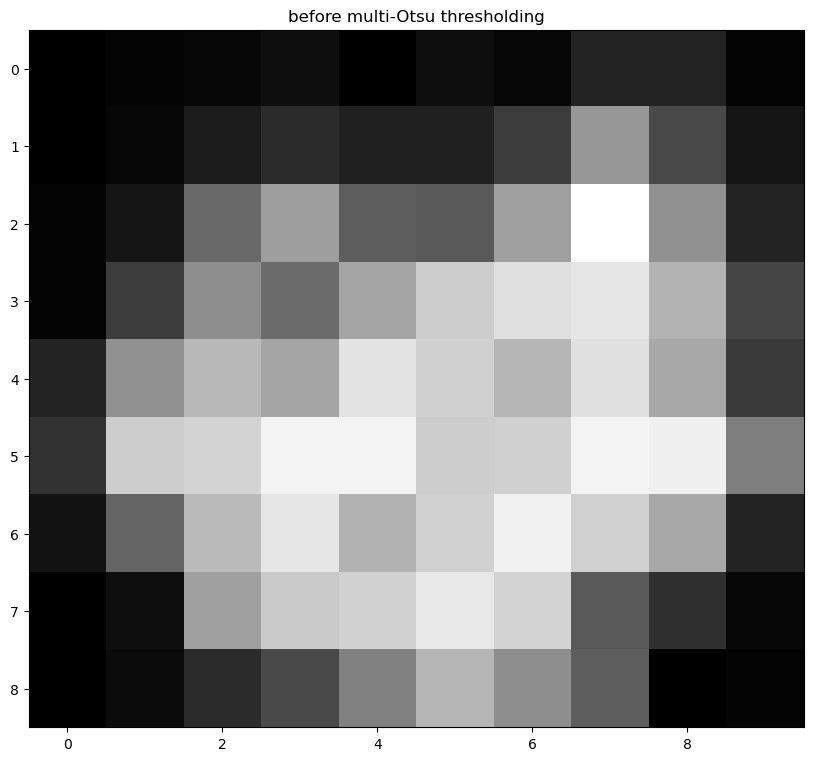

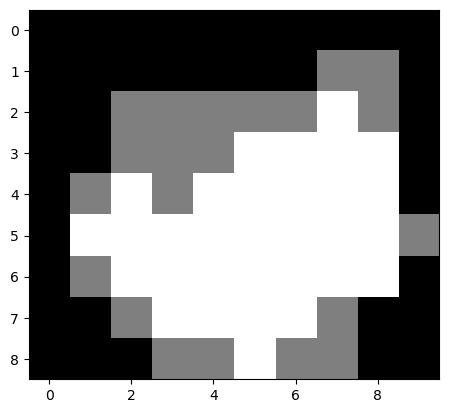

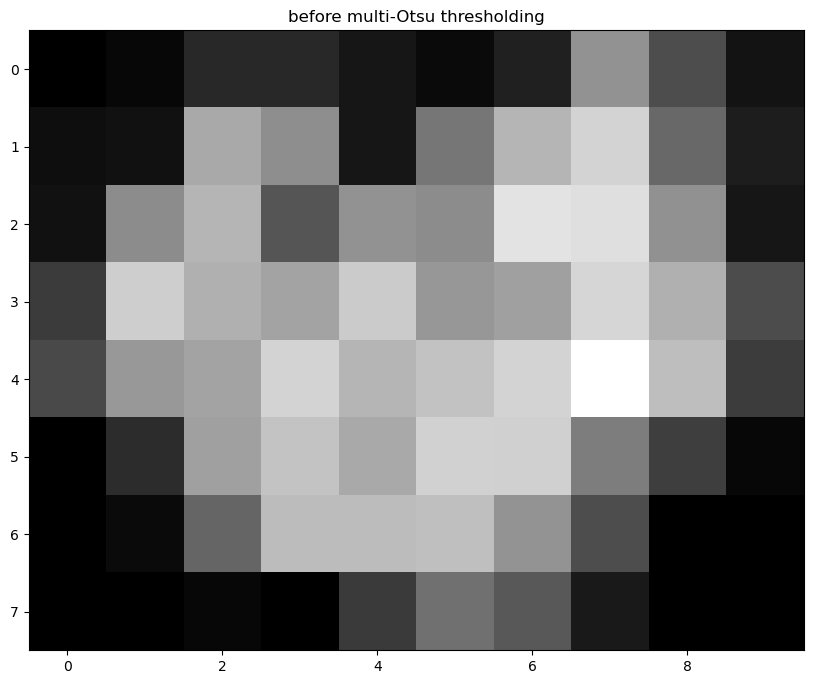

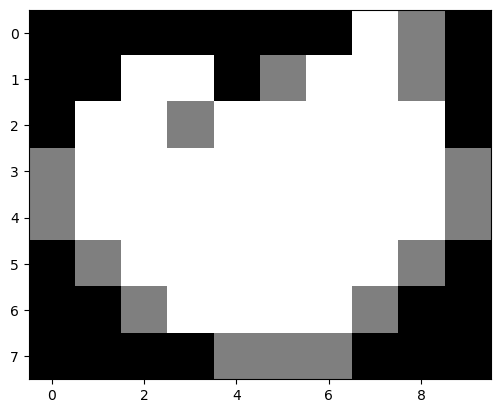

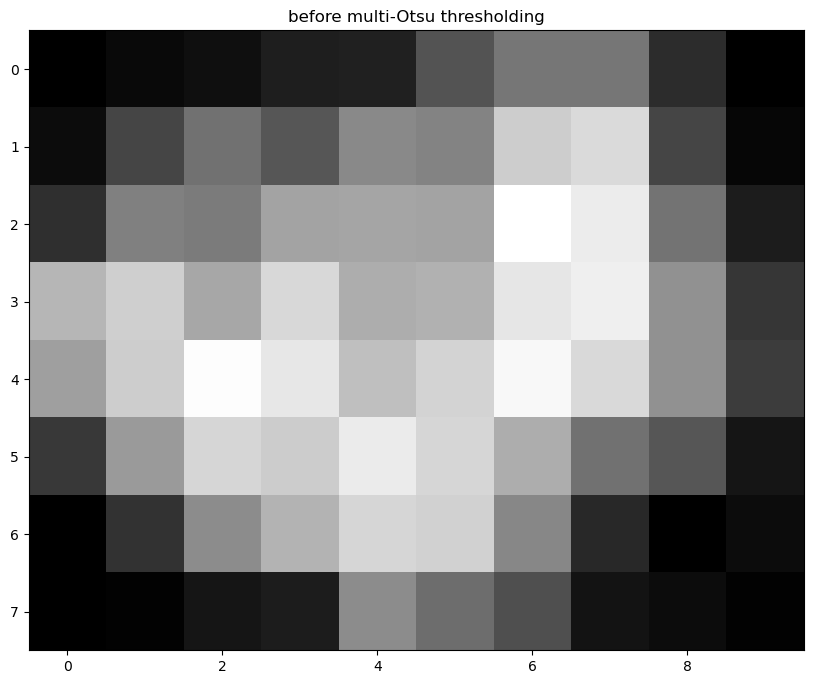

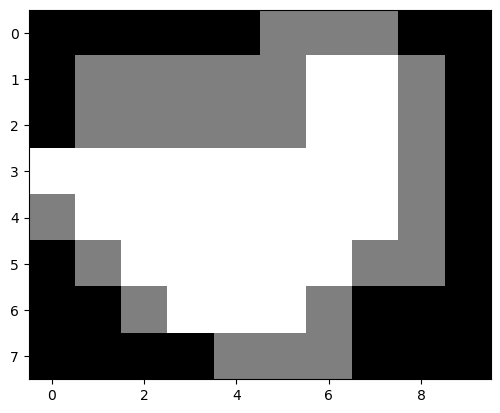

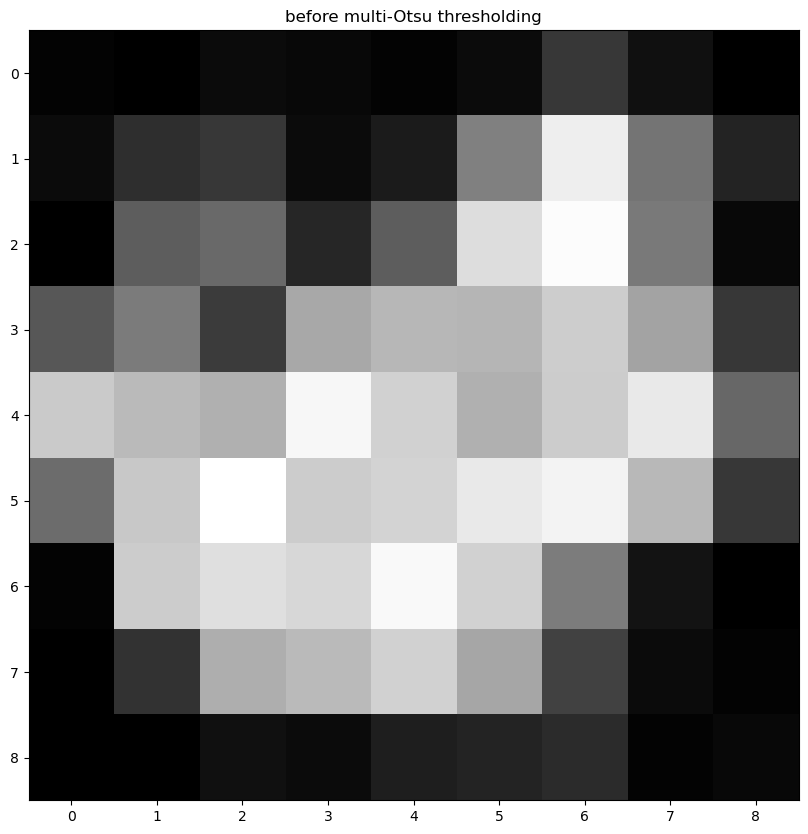

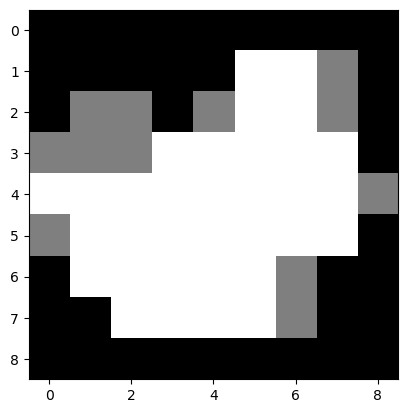

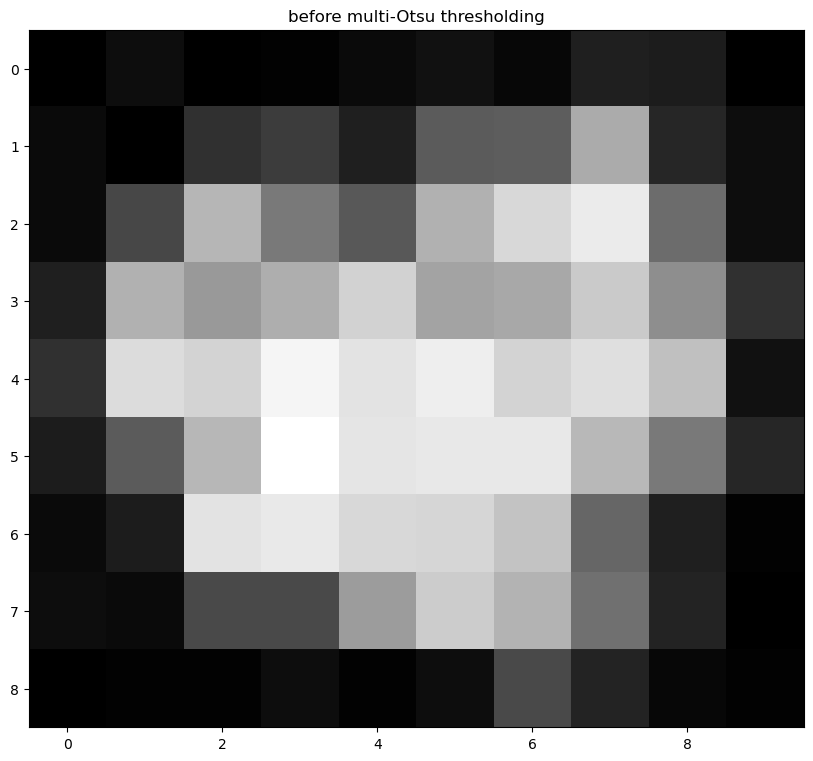

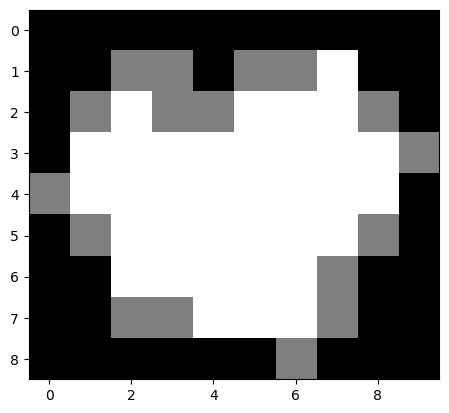

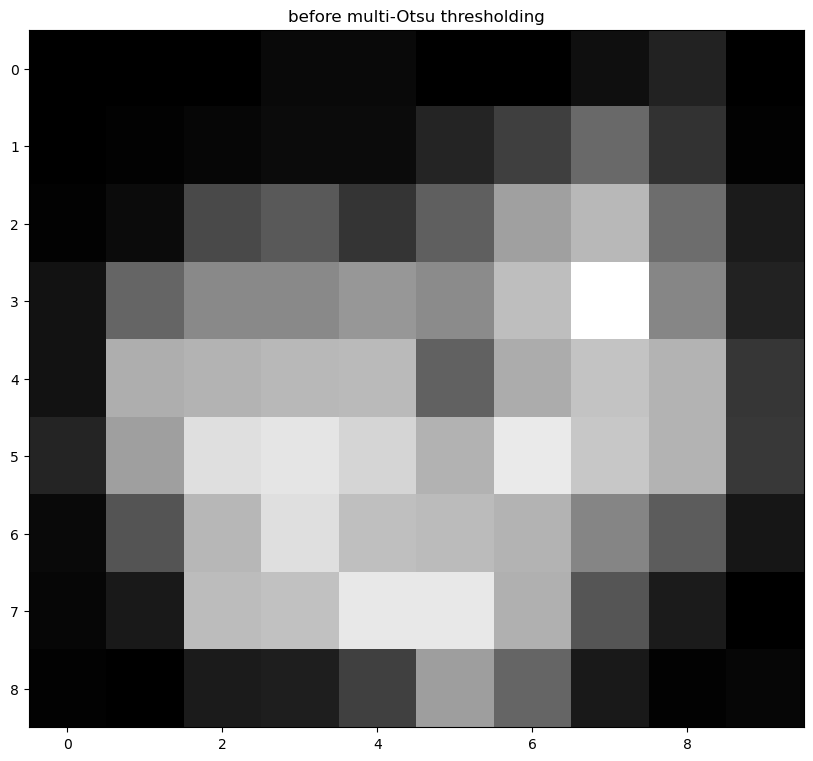

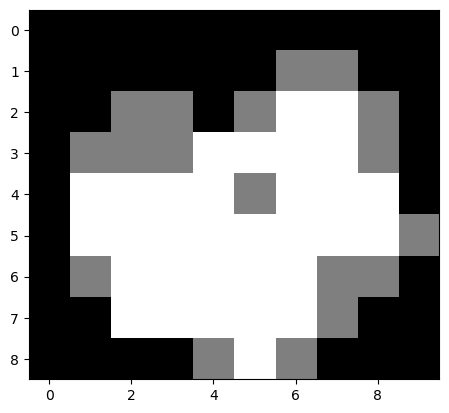

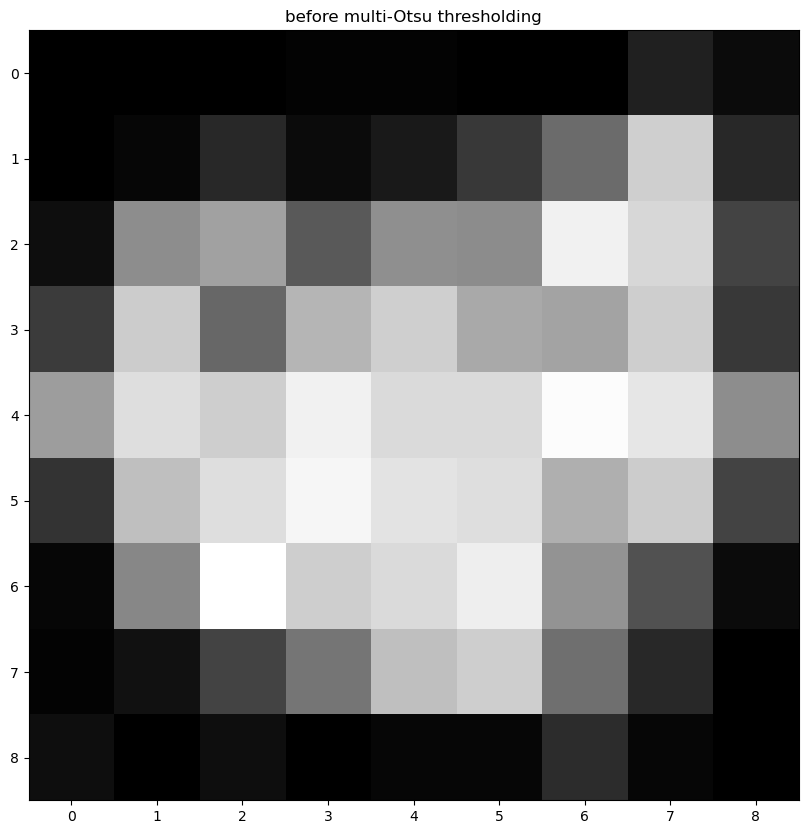

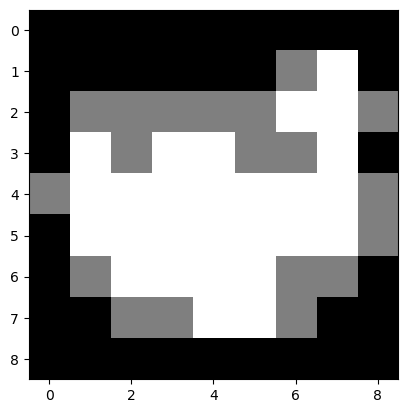

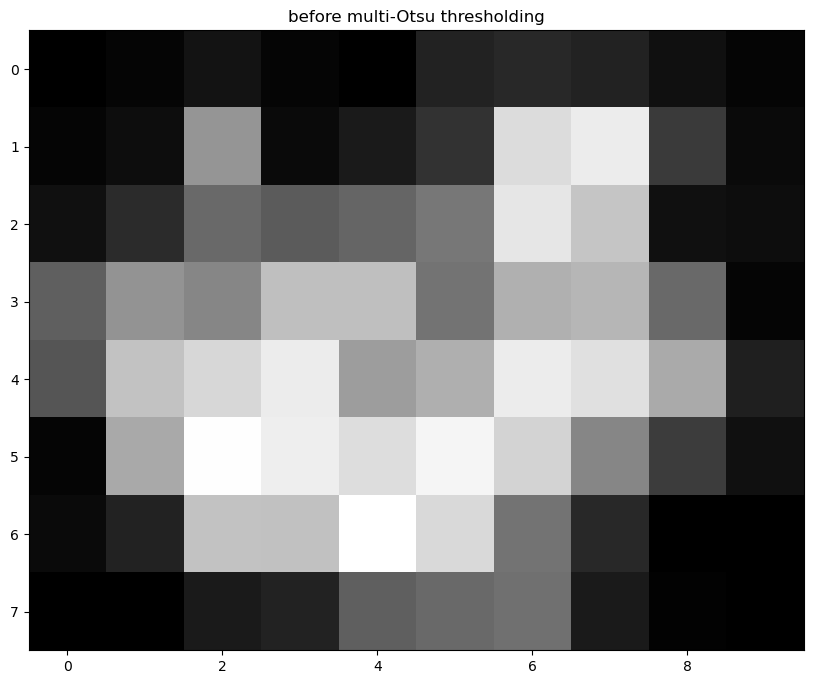

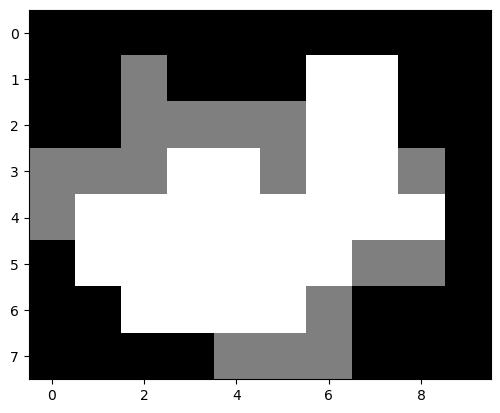

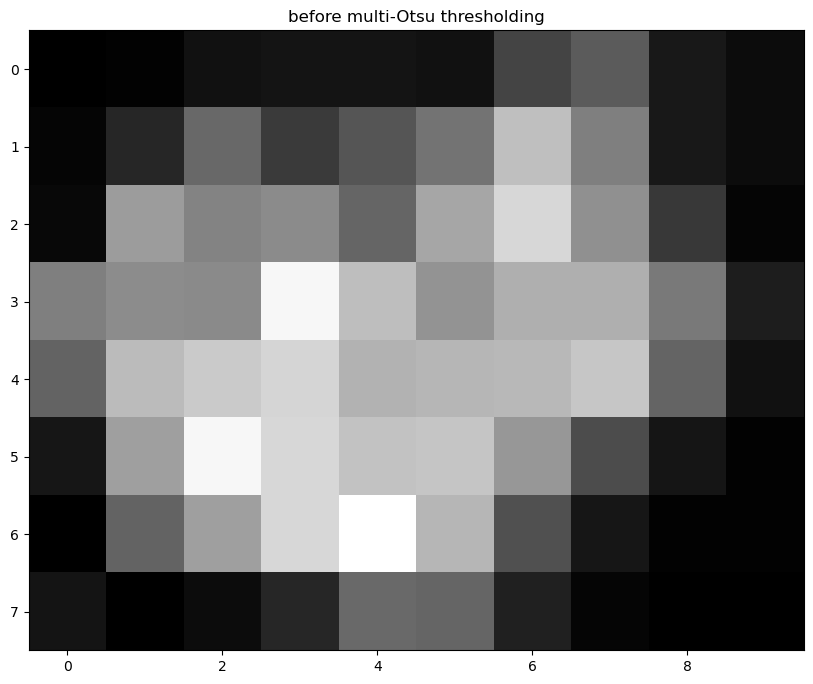

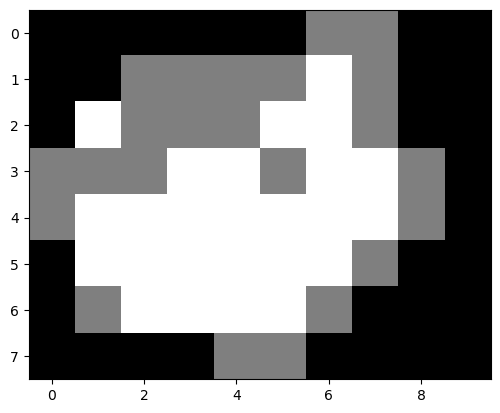

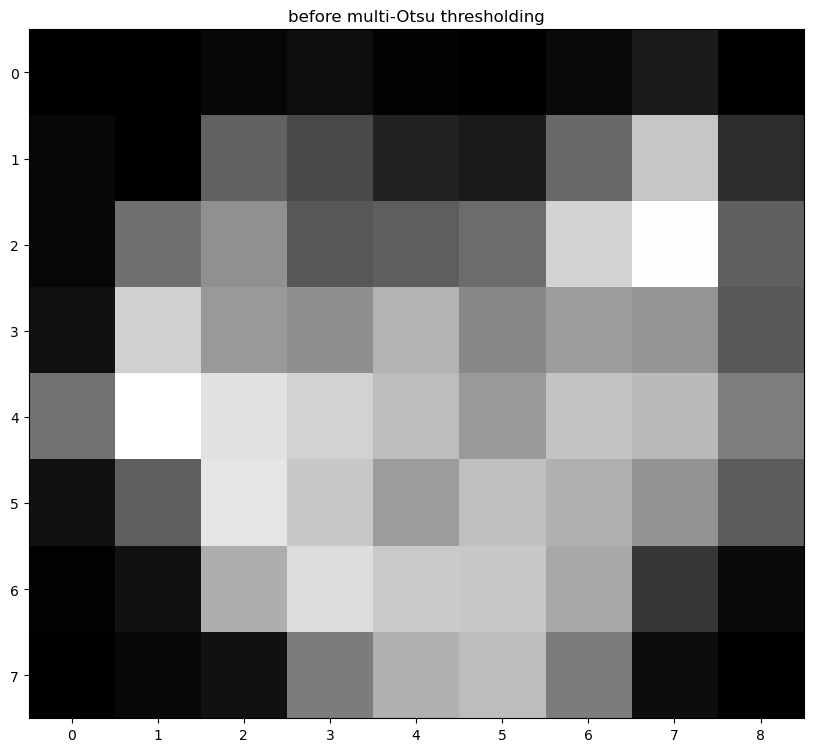

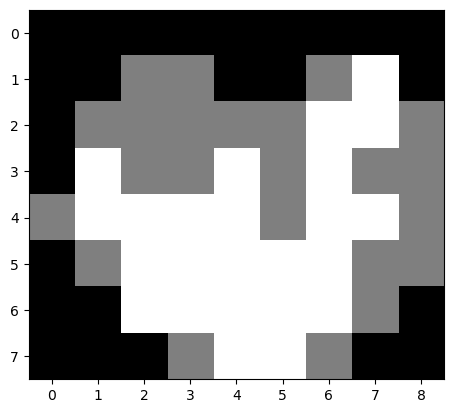

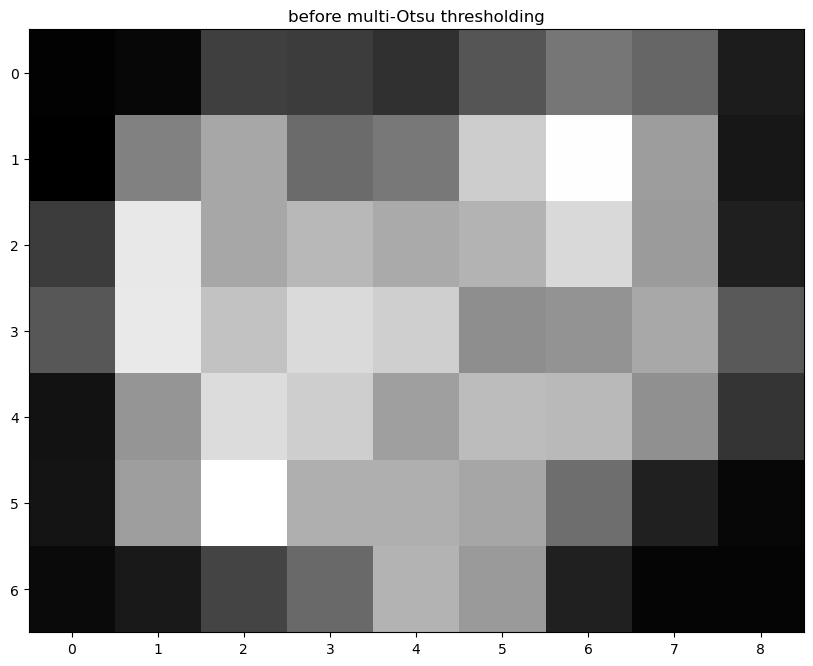

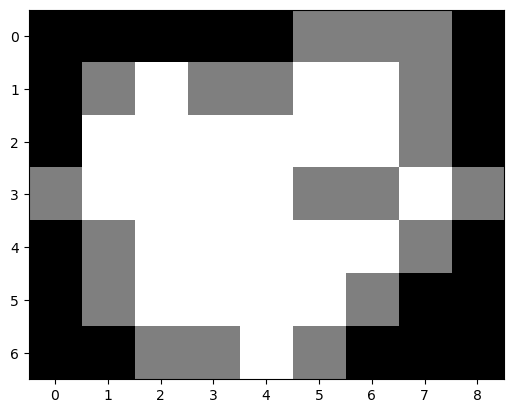

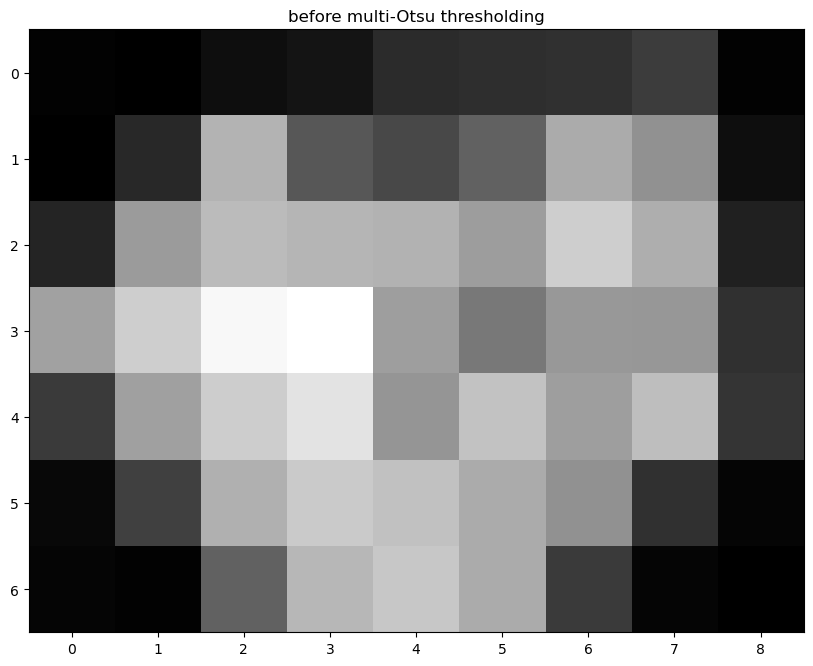

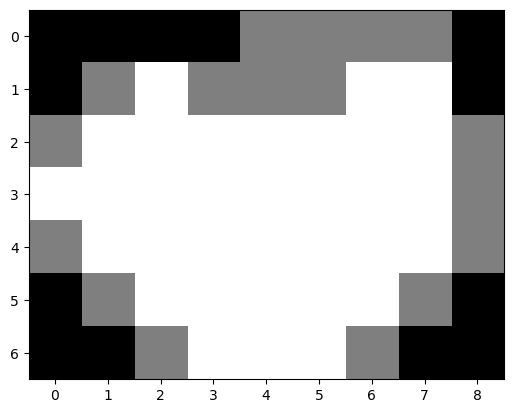

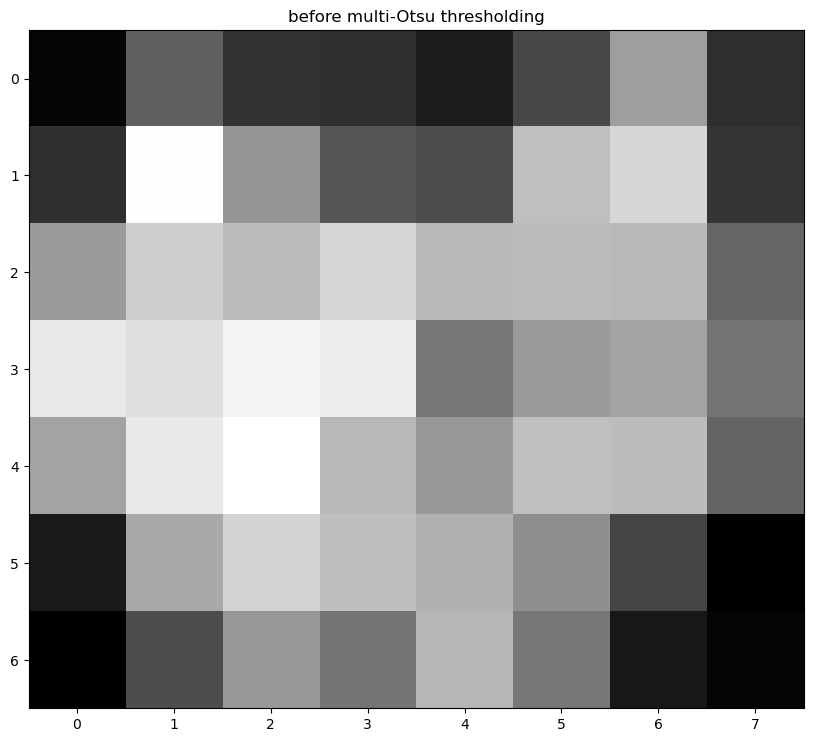

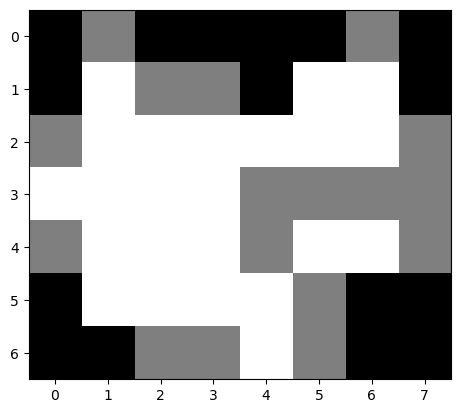

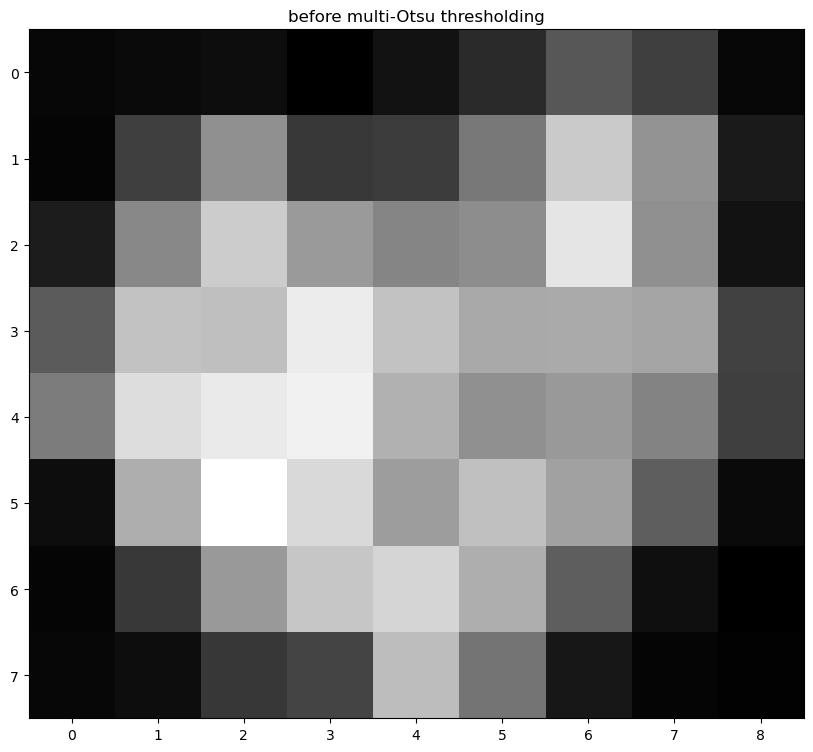

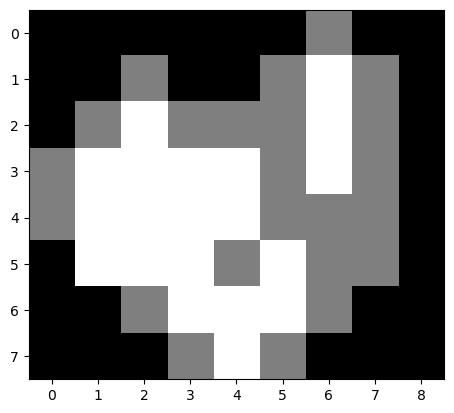

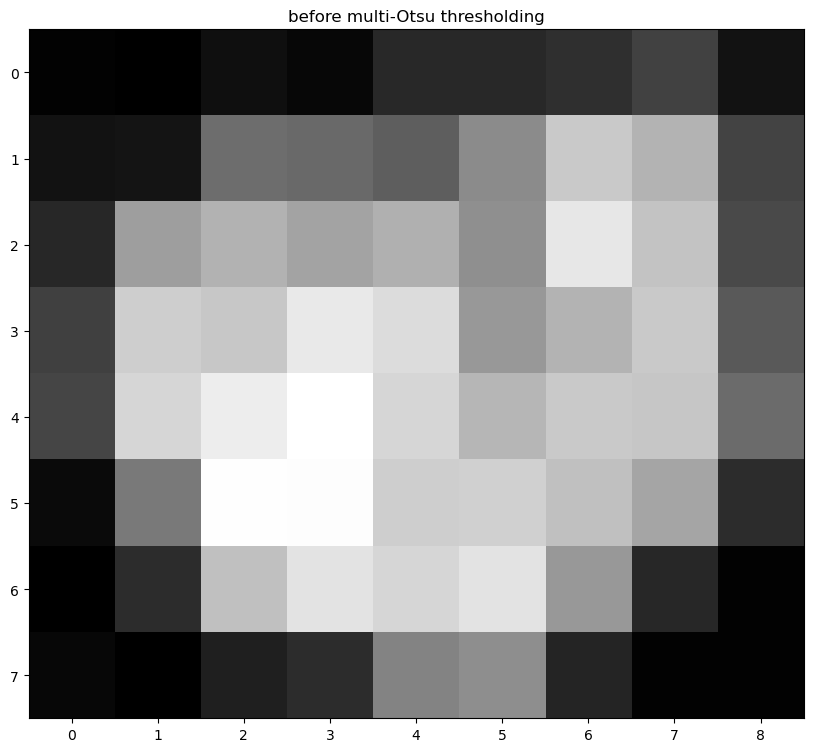

Deleting images from local for sequence 20230423-181011
Processing sequence 7/13: 20230425-183809
20230425-183809
extract images from server to local


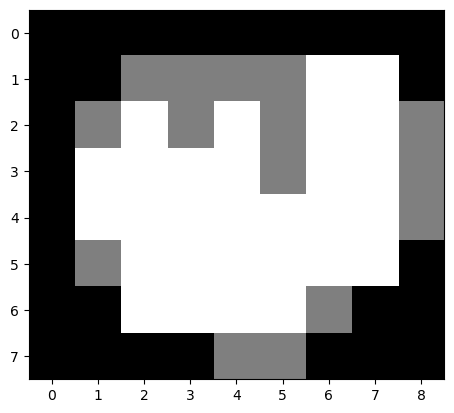

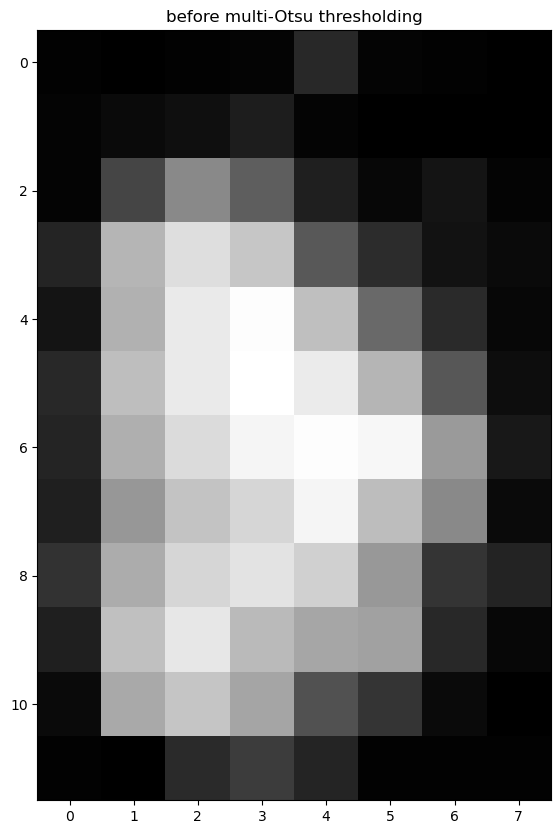

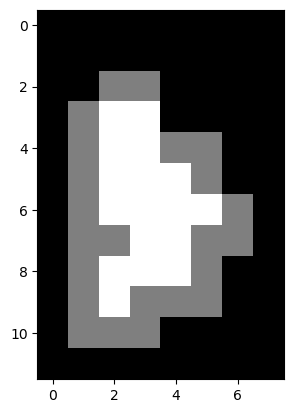

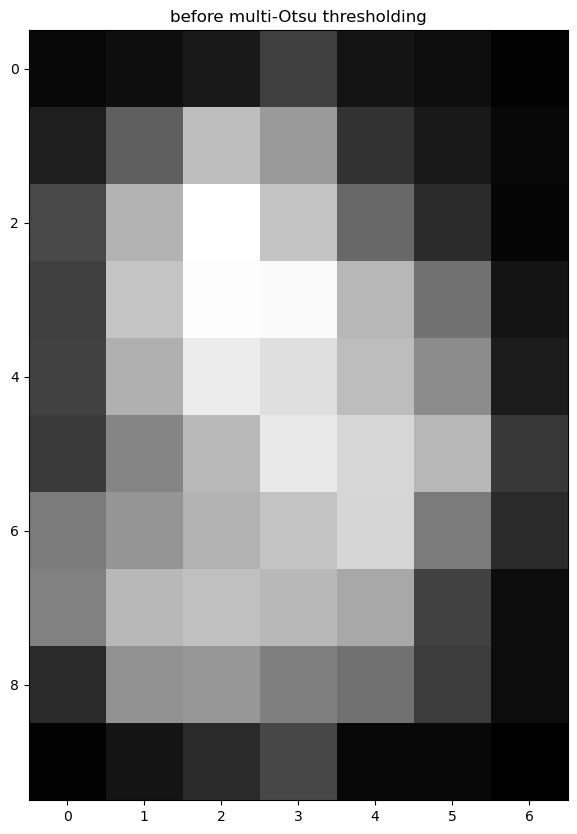

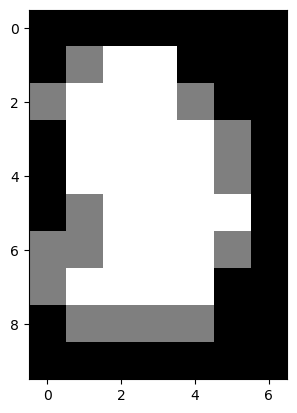

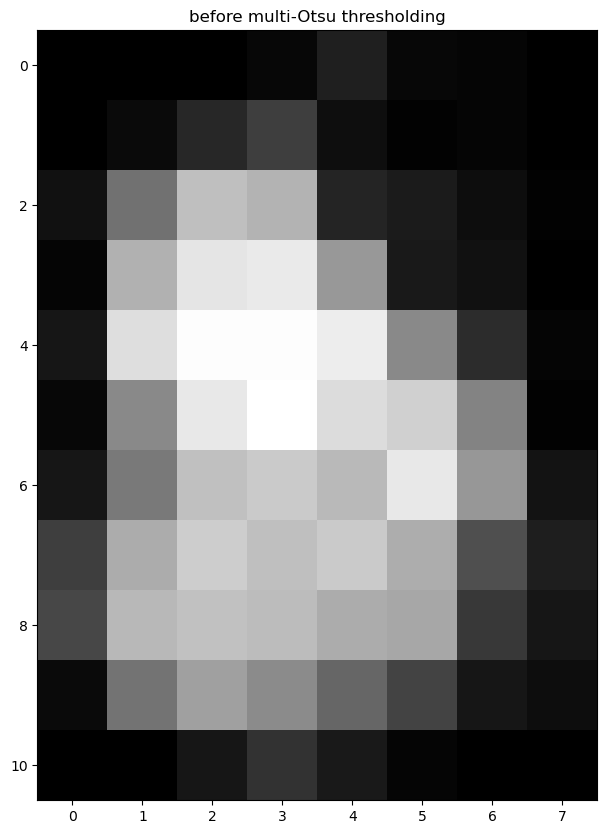

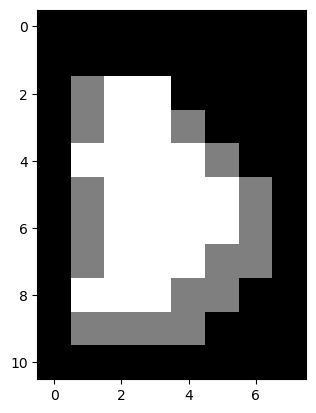

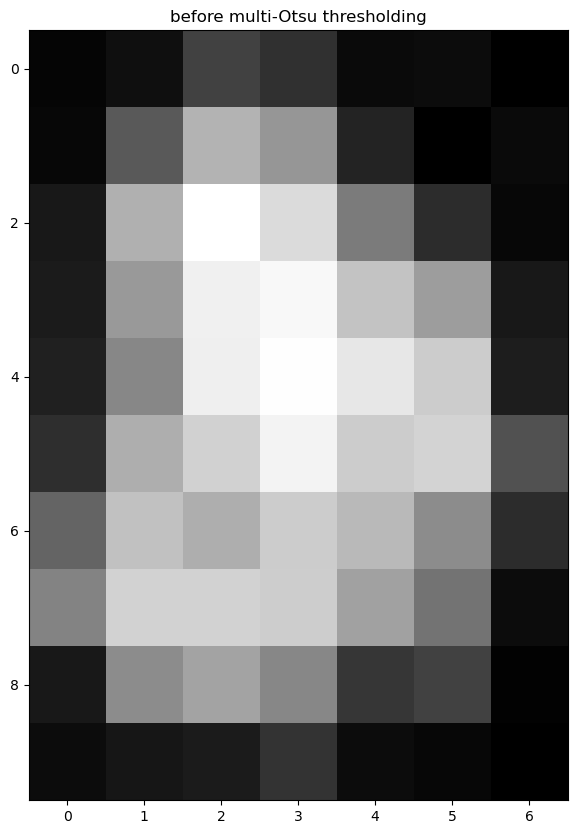

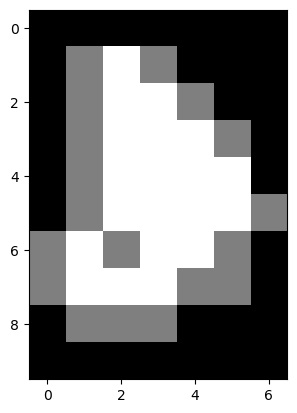

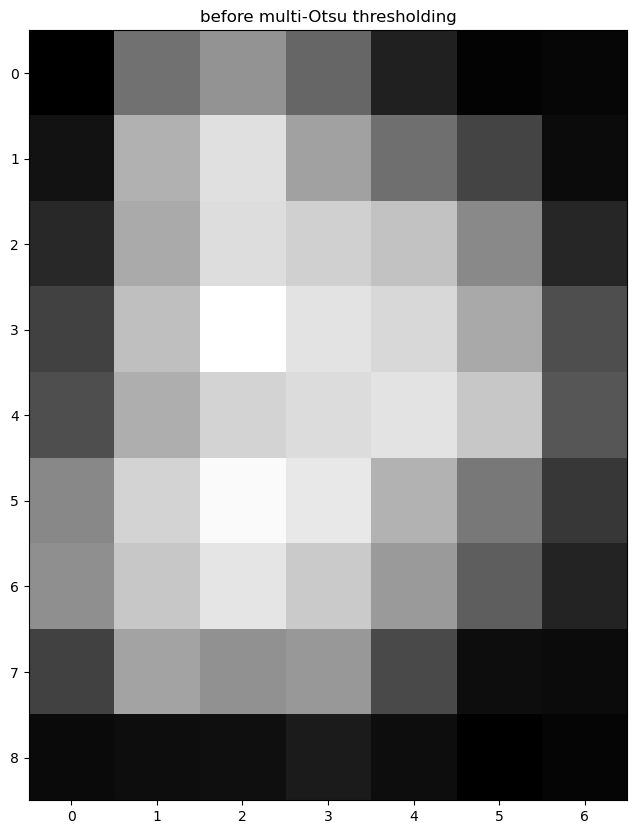

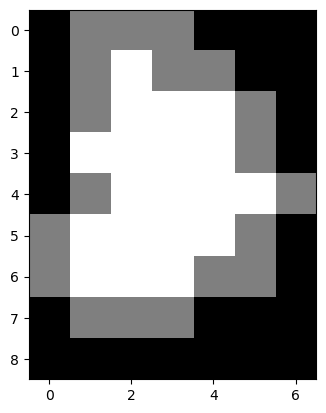

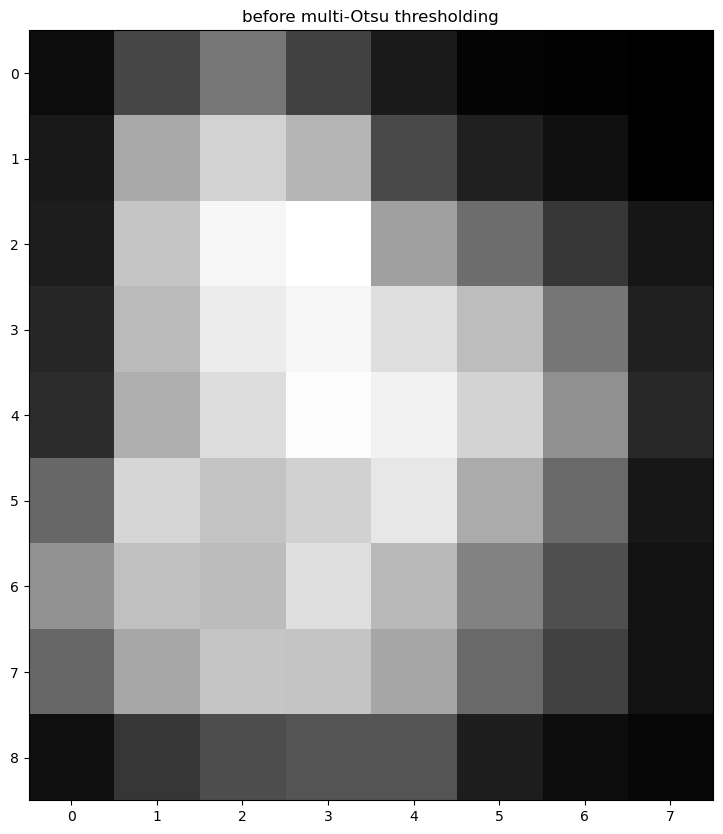

Deleting images from local for sequence 20230425-183809
Processing sequence 8/13: 20230426-055807
20230426-055807
extract images from server to local


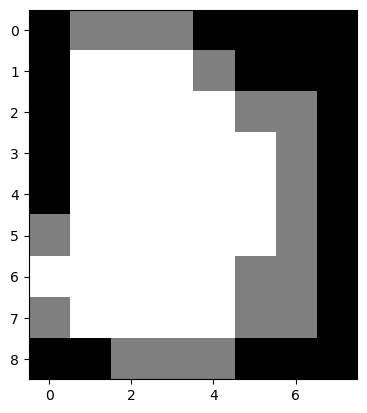

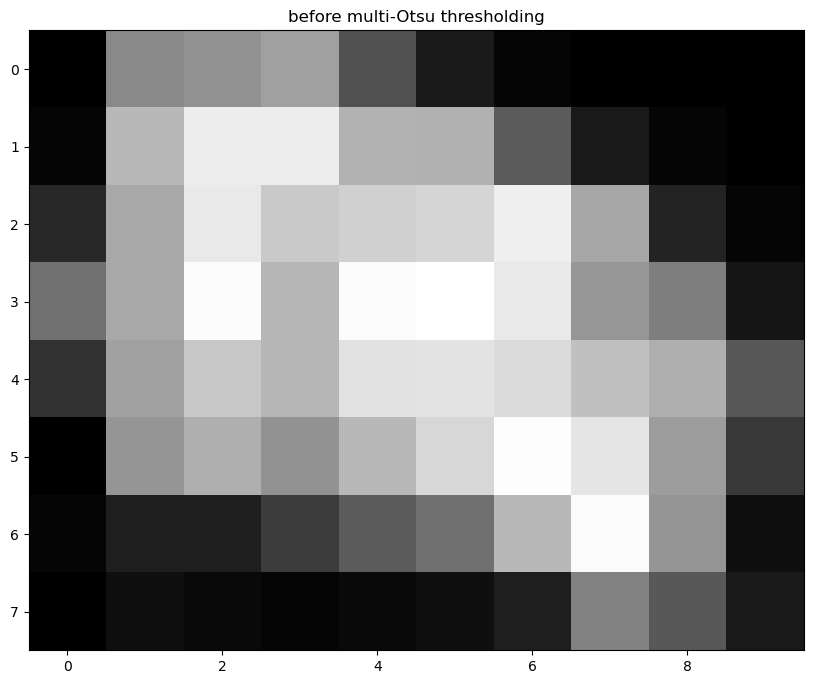

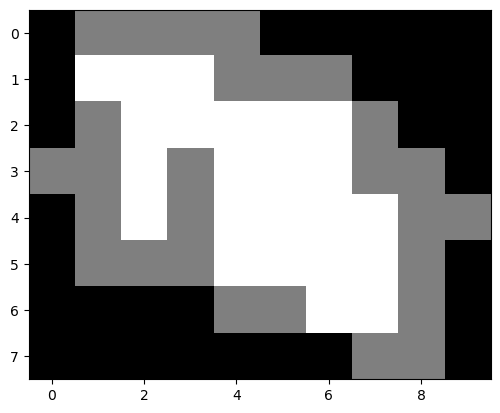

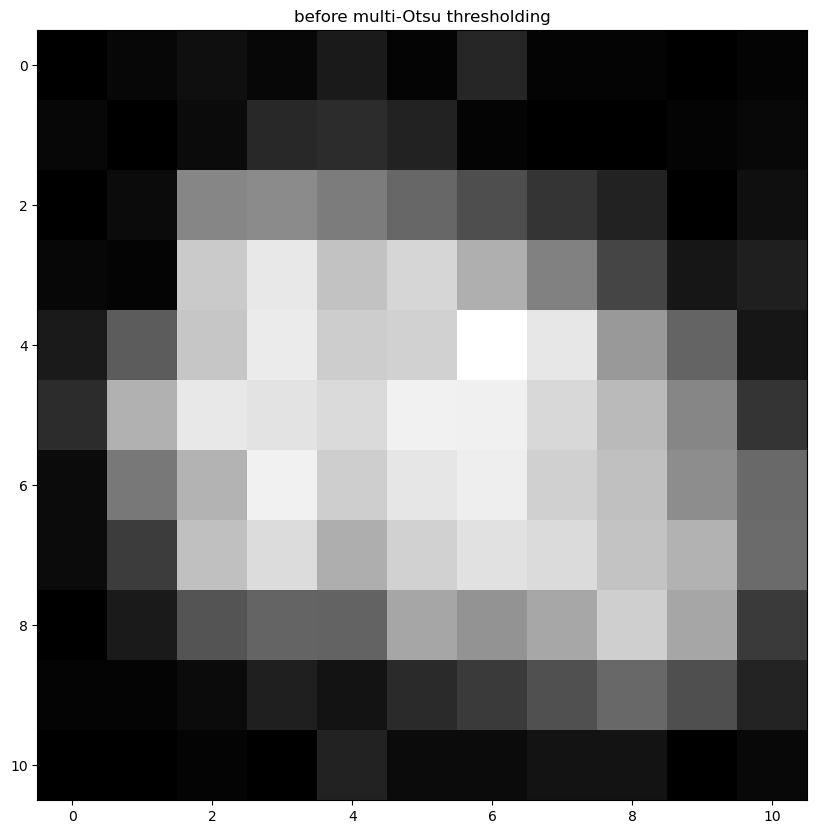

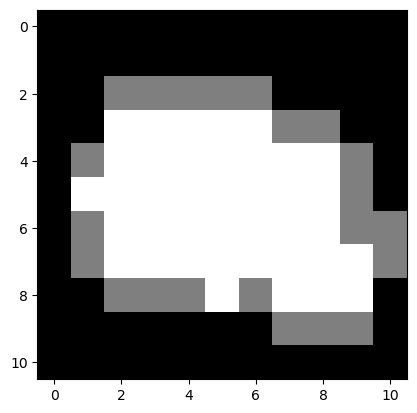

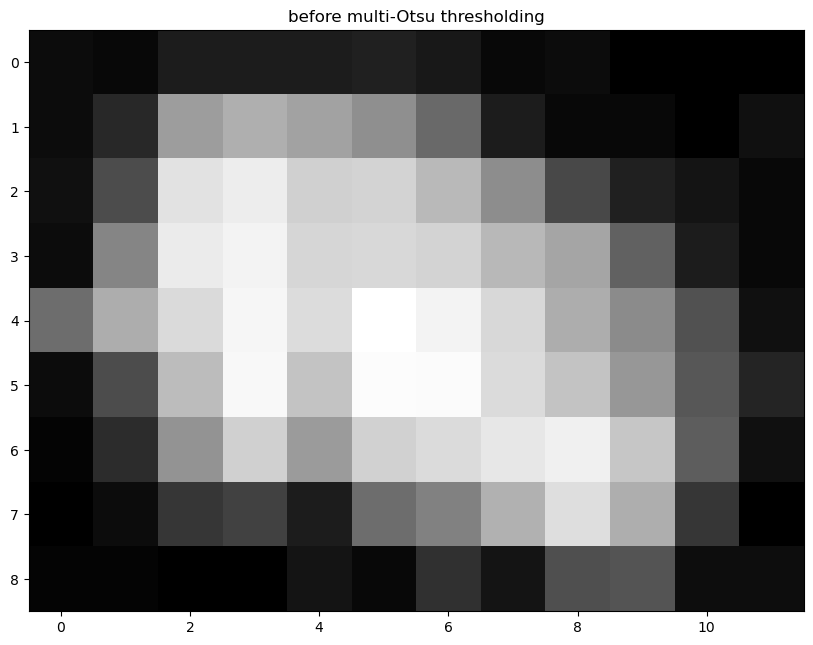

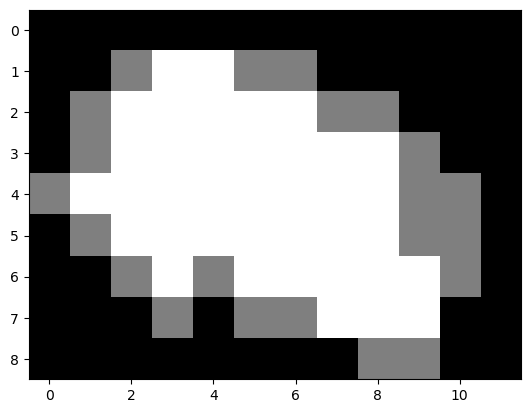

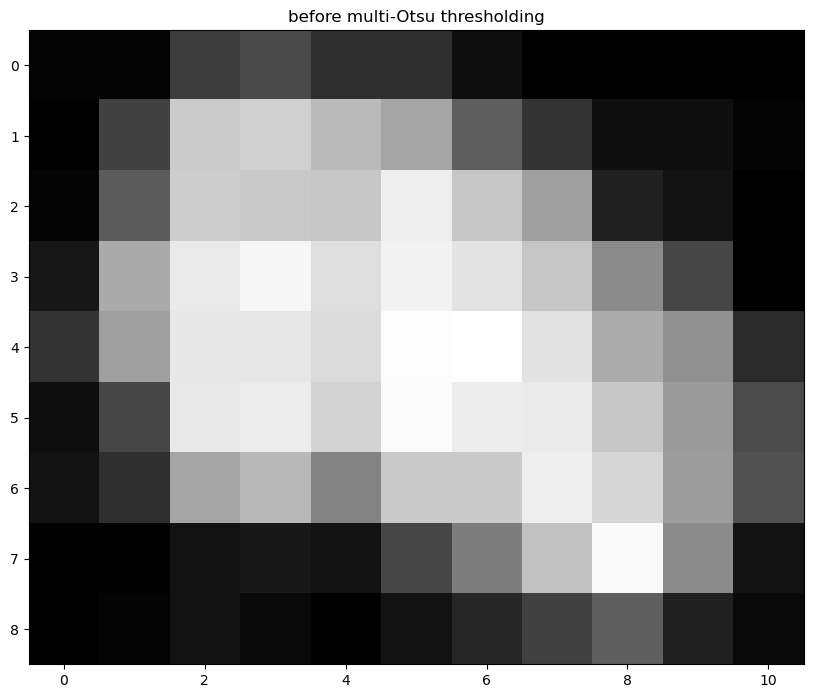

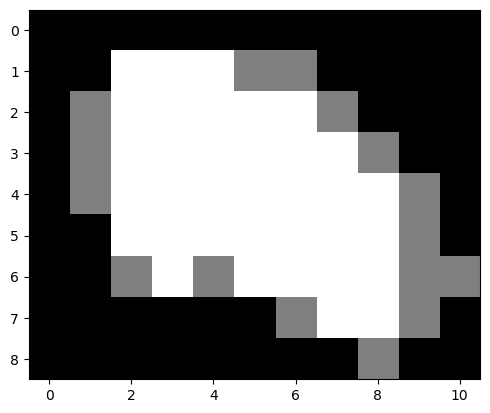

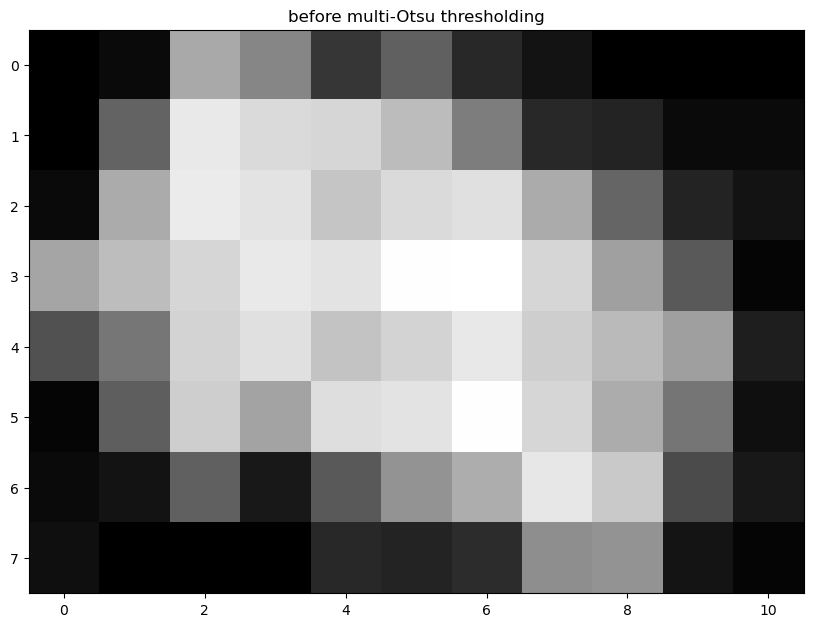

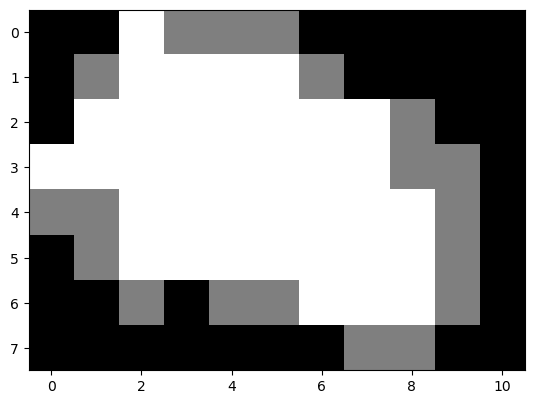

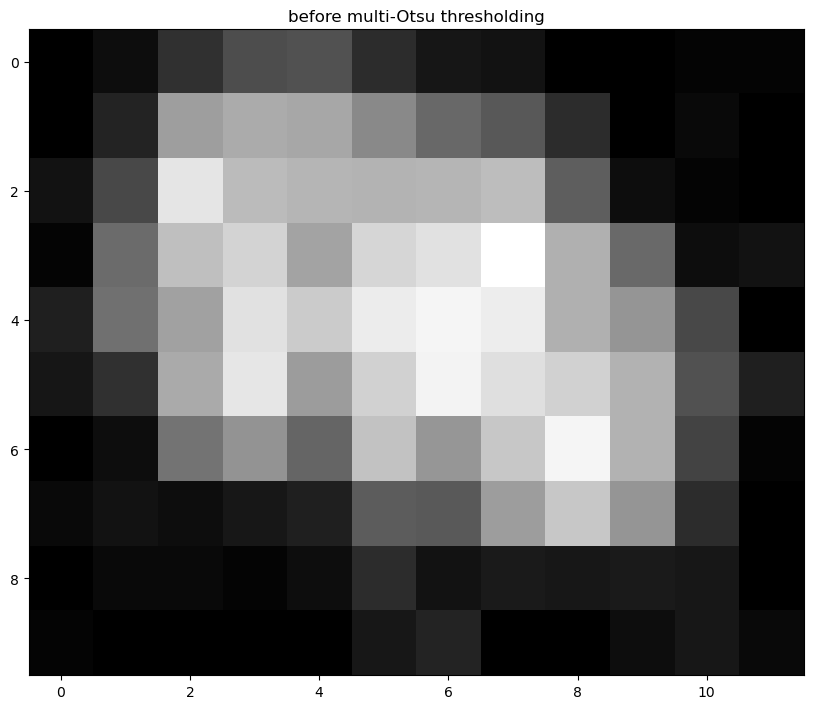

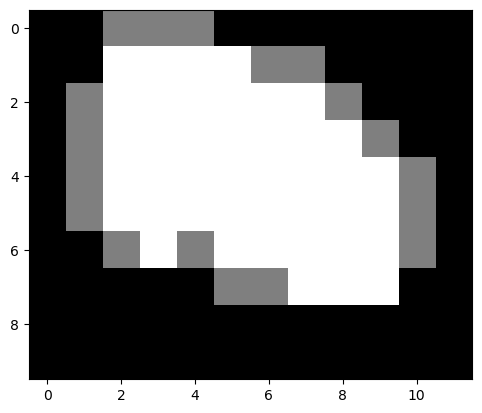

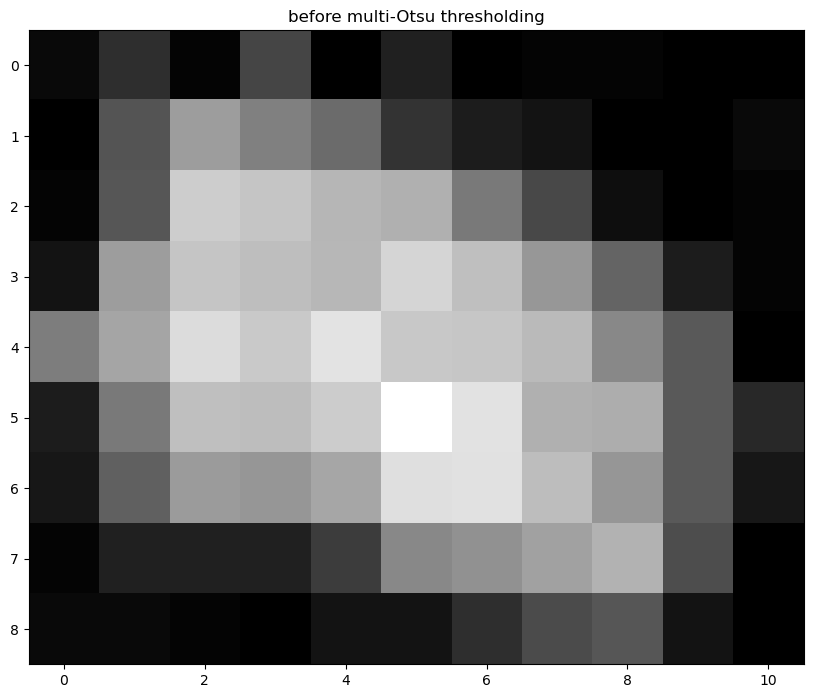

Deleting images from local for sequence 20230426-055807
Processing sequence 9/13: 20230428-035517
20230428-035517
extract images from server to local


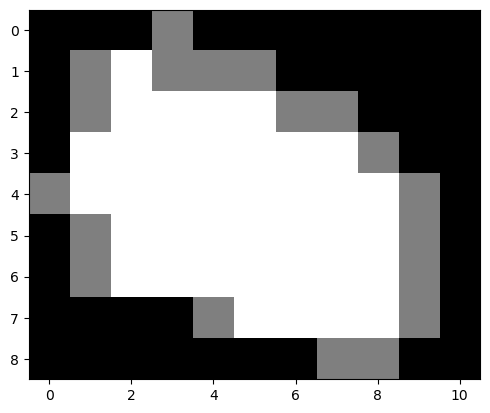

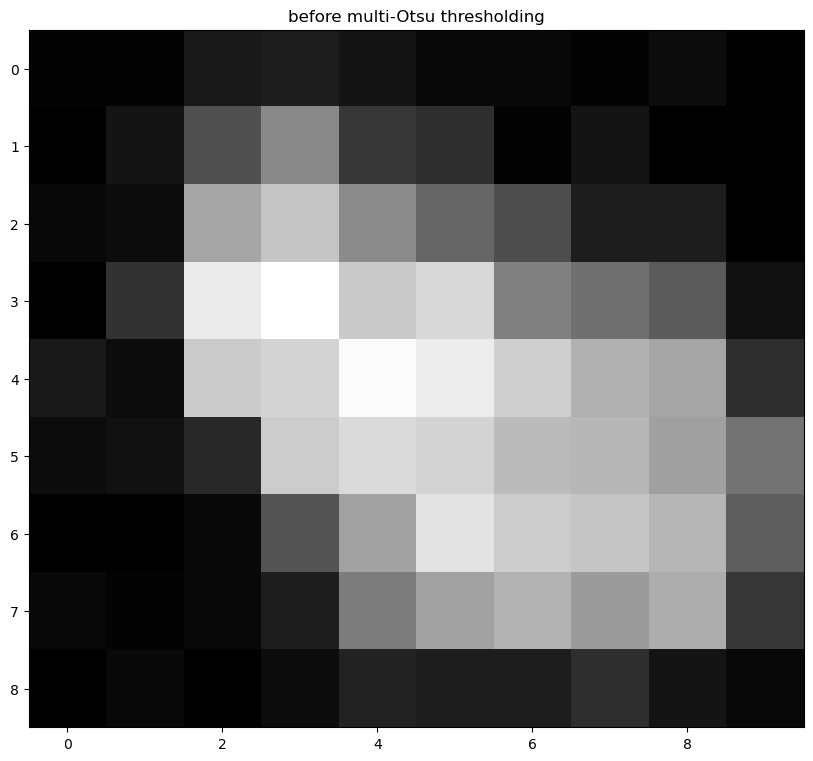

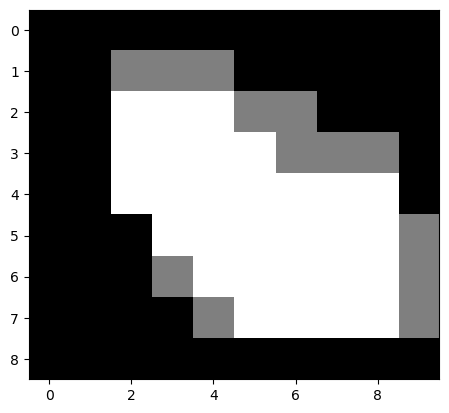

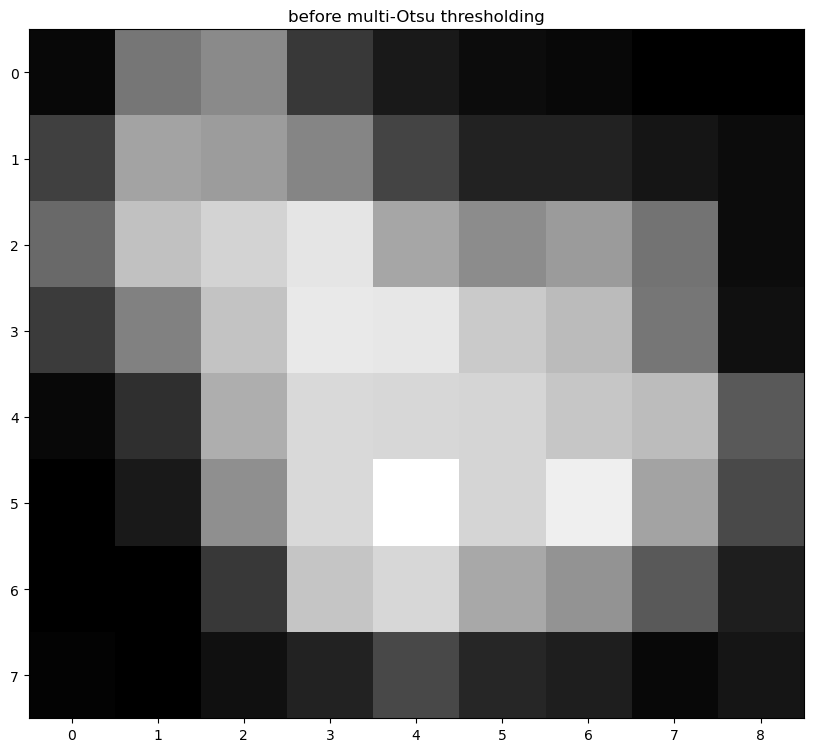

Deleting images from local for sequence 20230428-035517
Processing sequence 10/13: 20230428-055517
20230428-055517
extract images from server to local


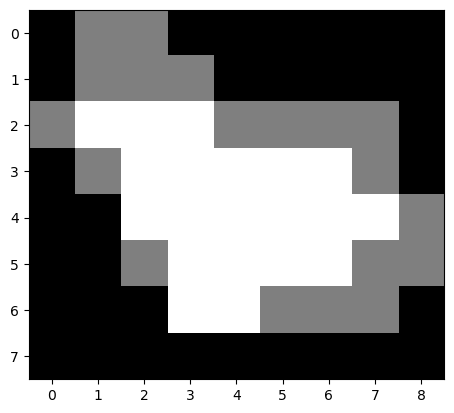

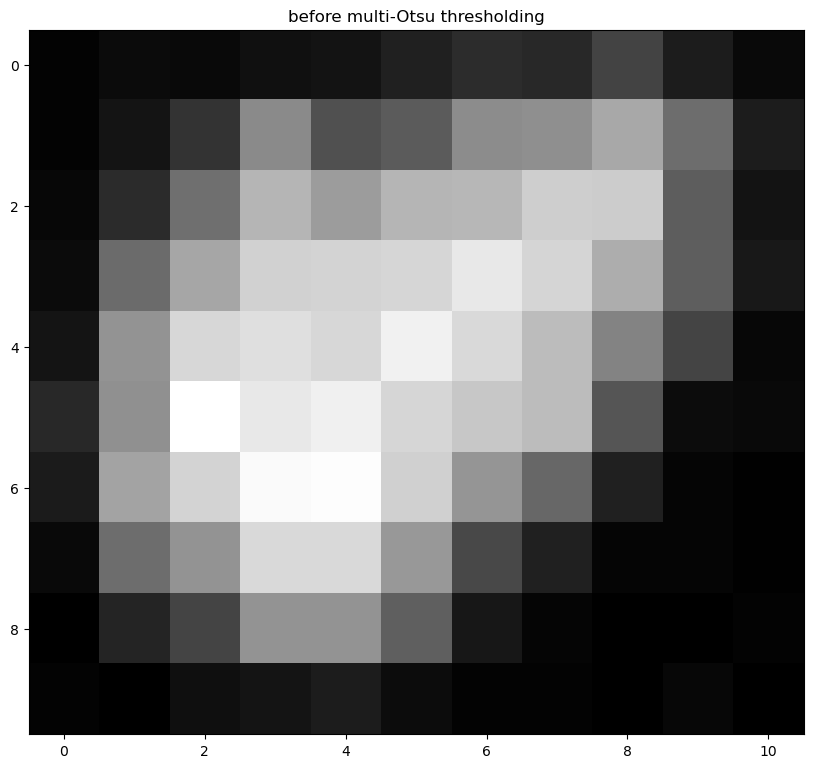

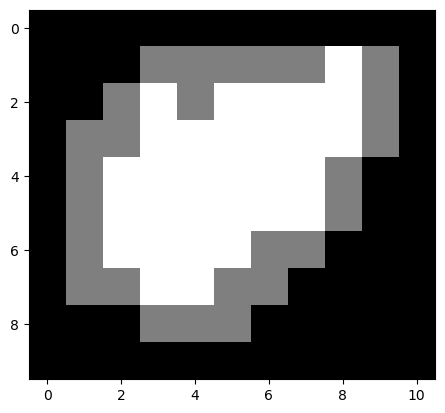

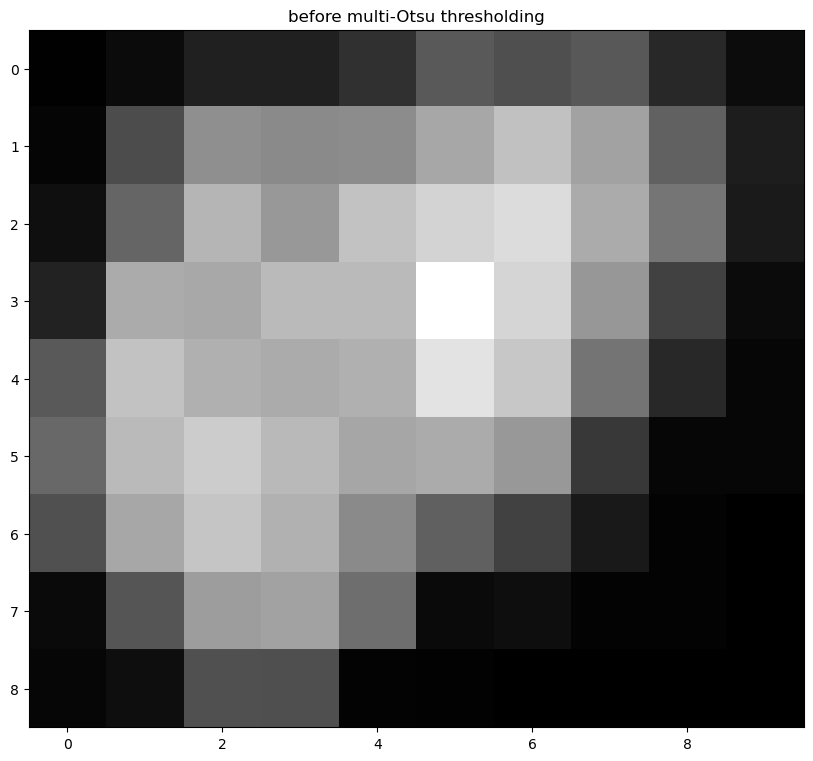

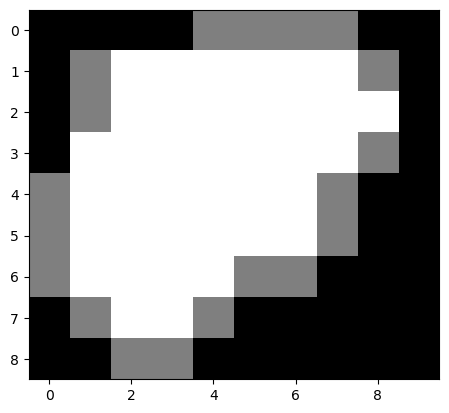

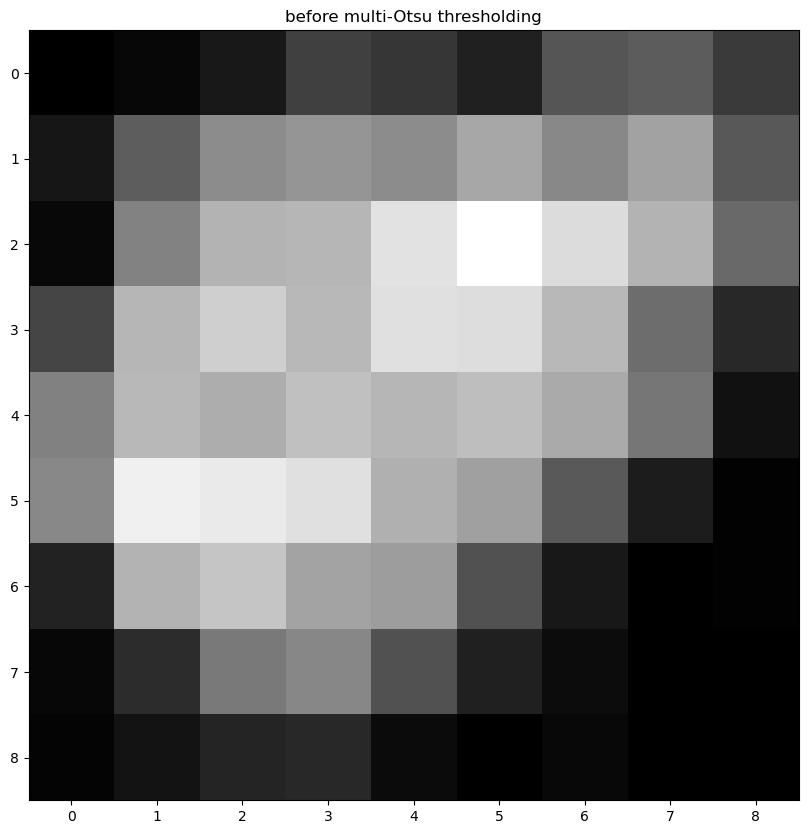

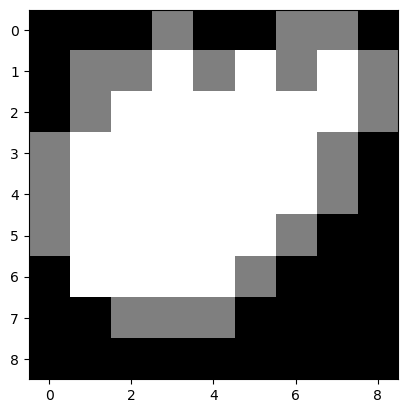

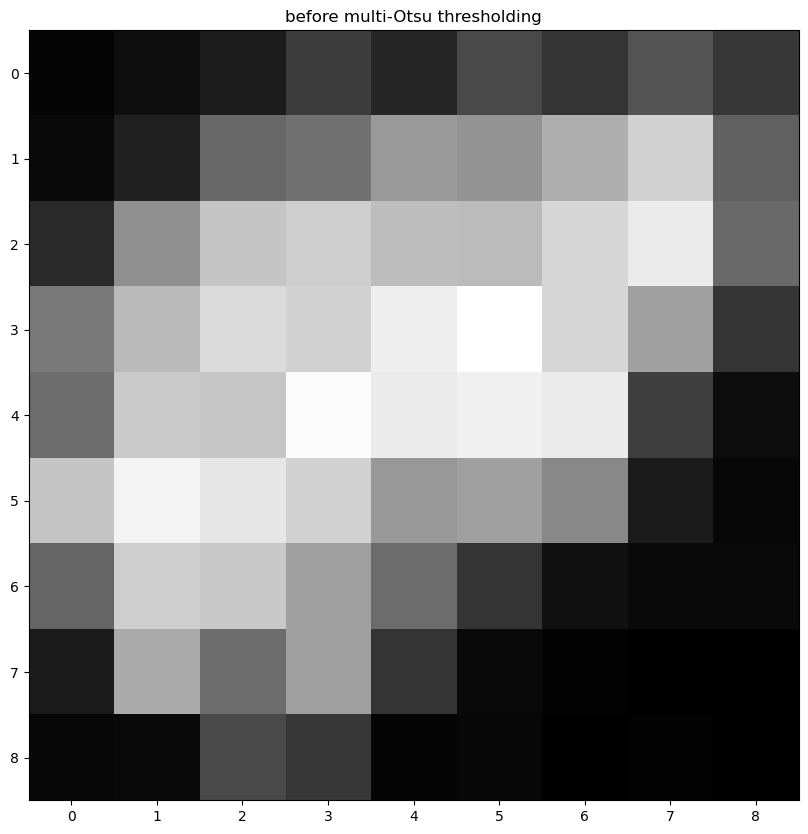

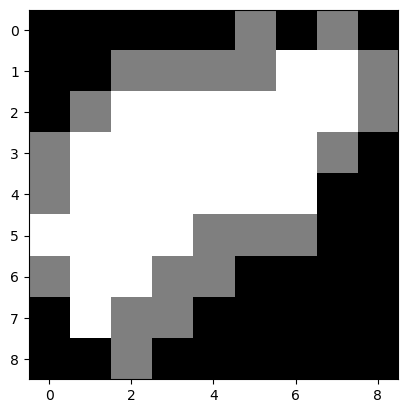

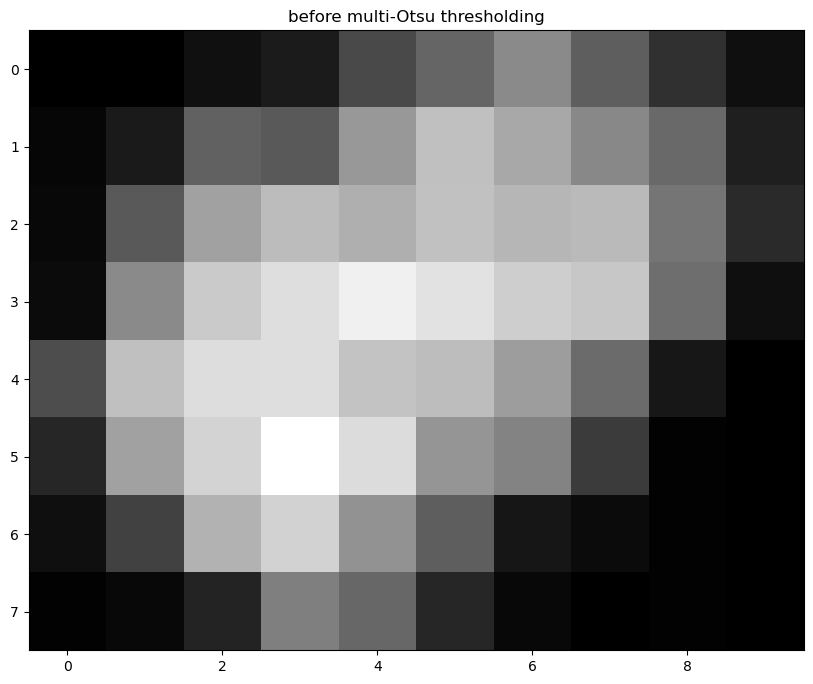

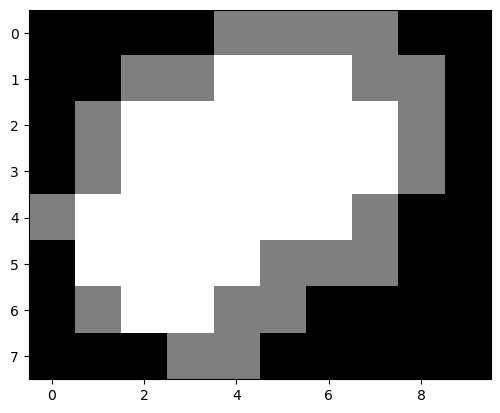

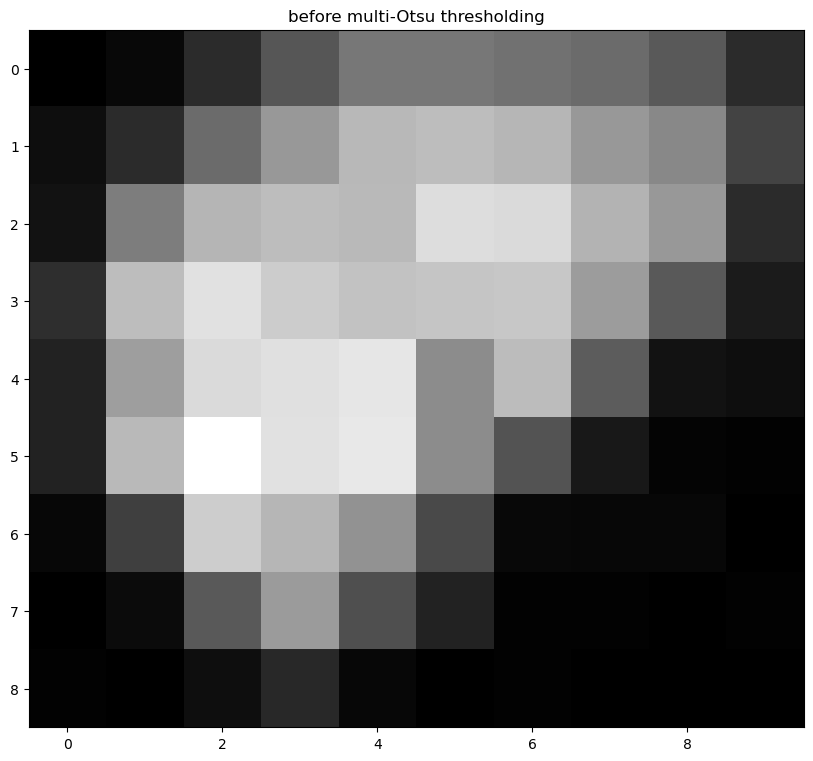

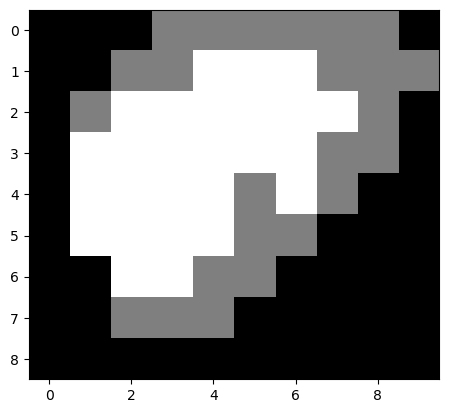

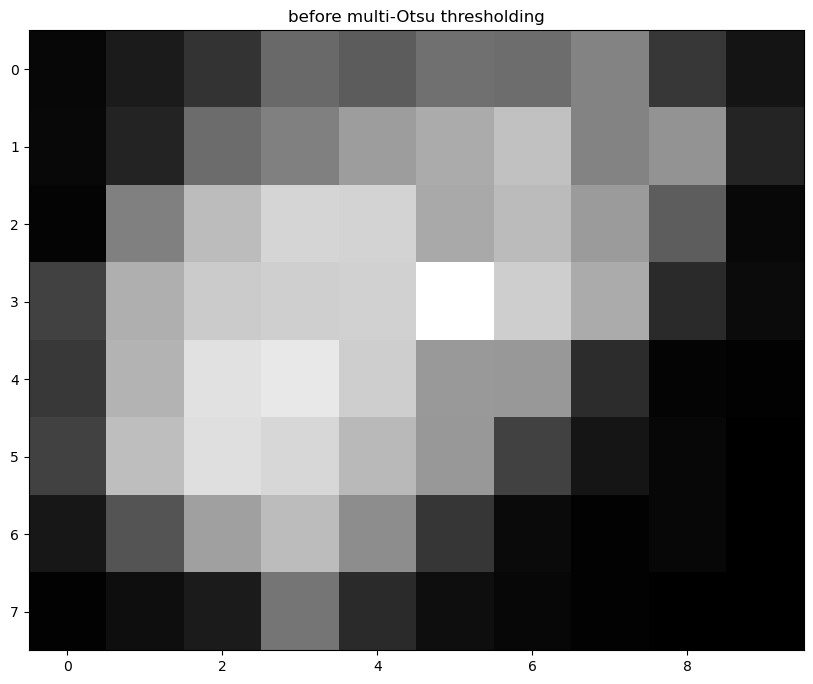

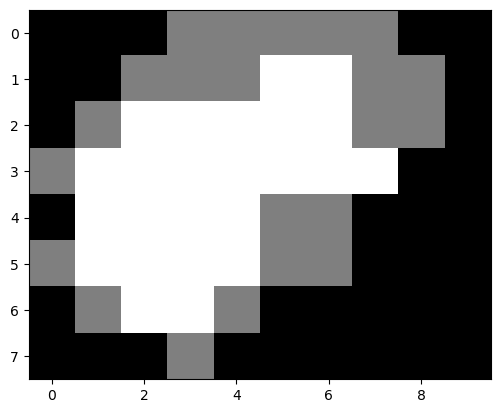

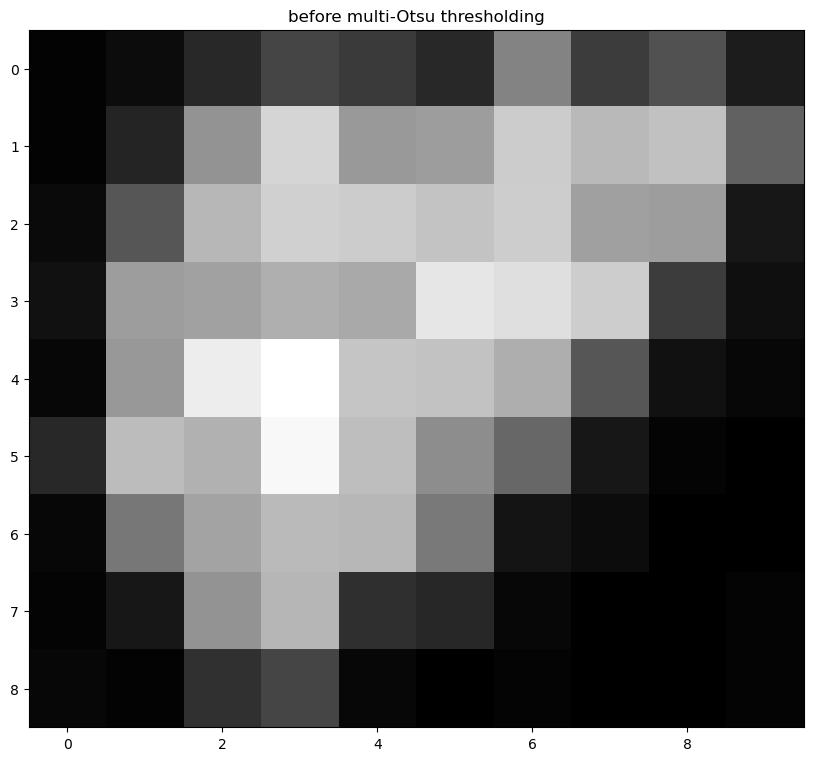

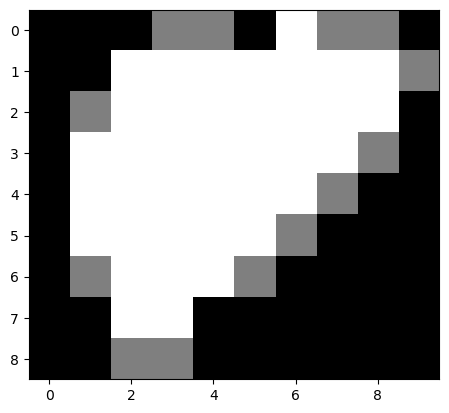

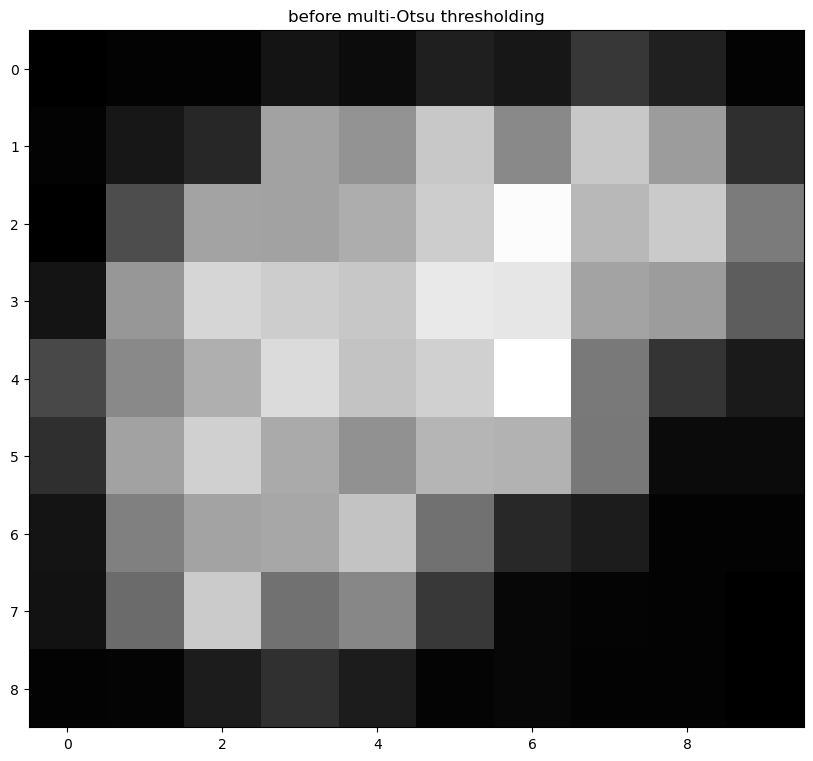

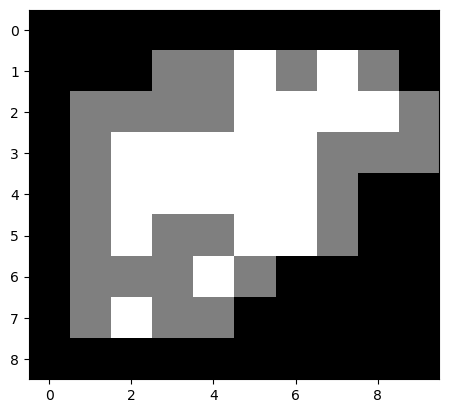

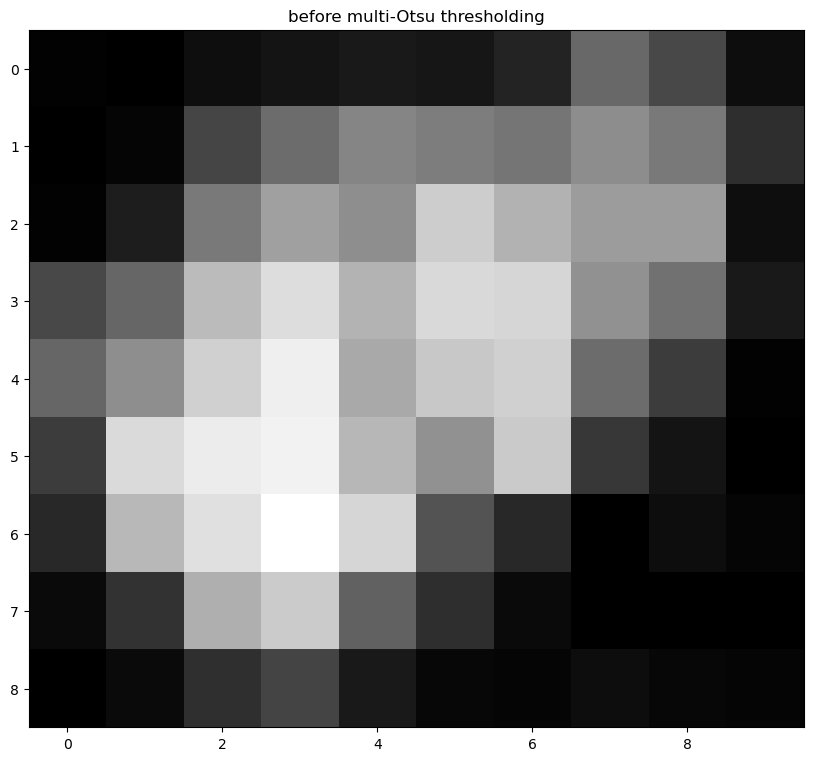

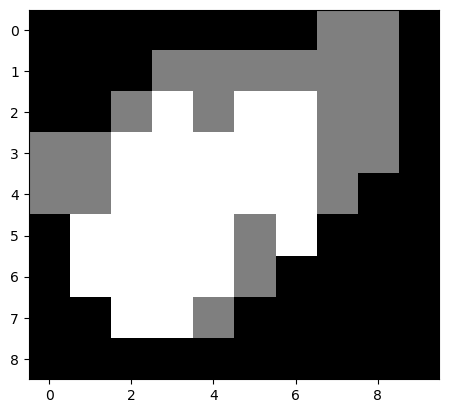

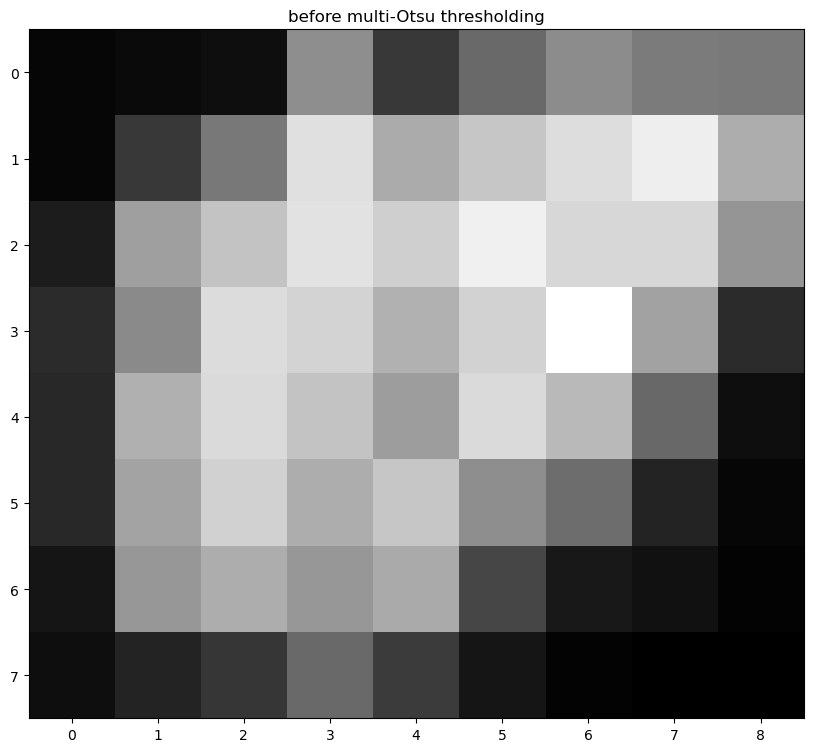

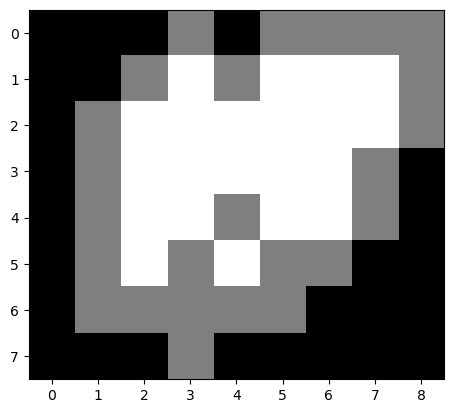

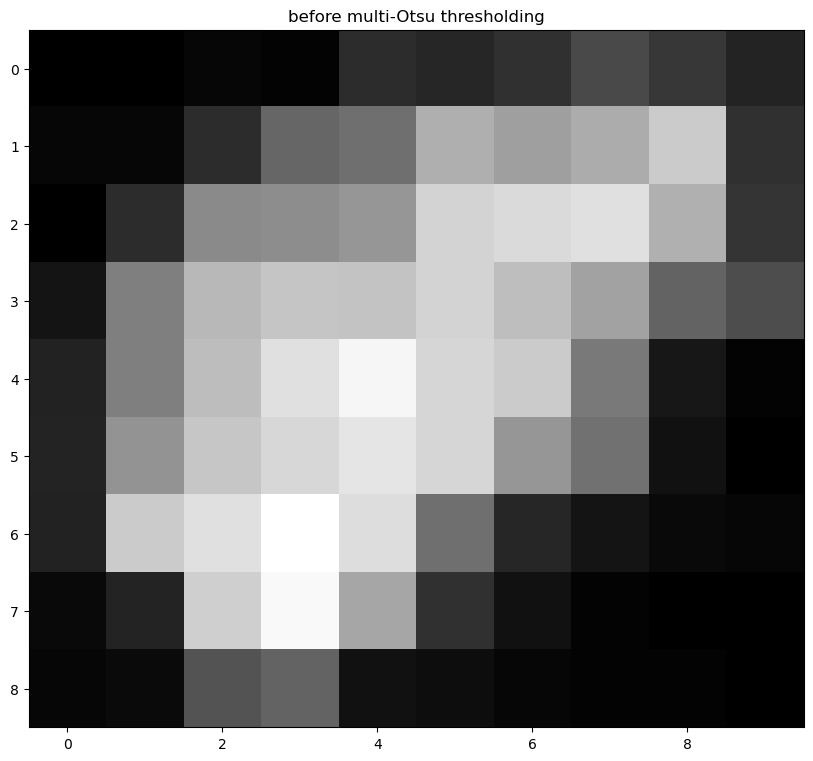

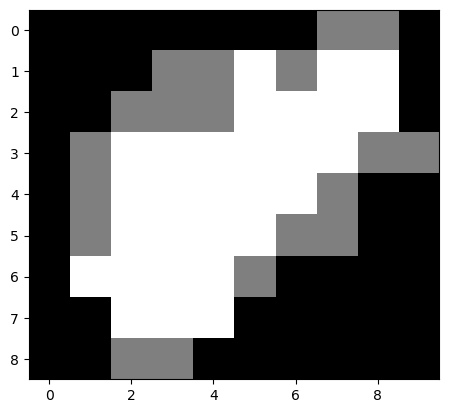

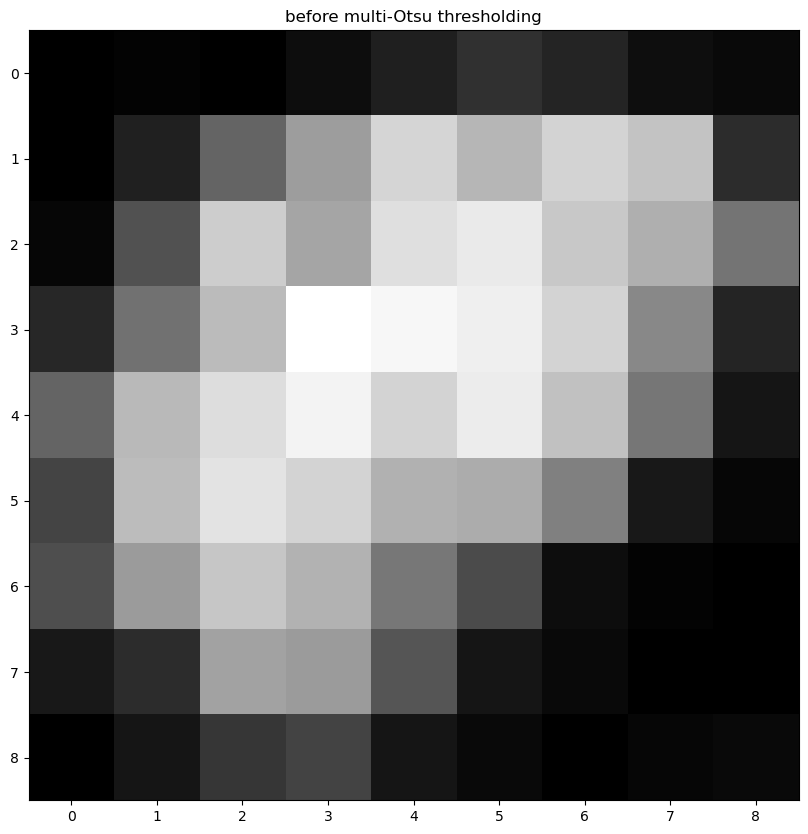

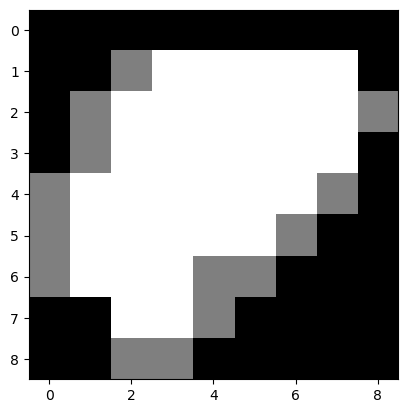

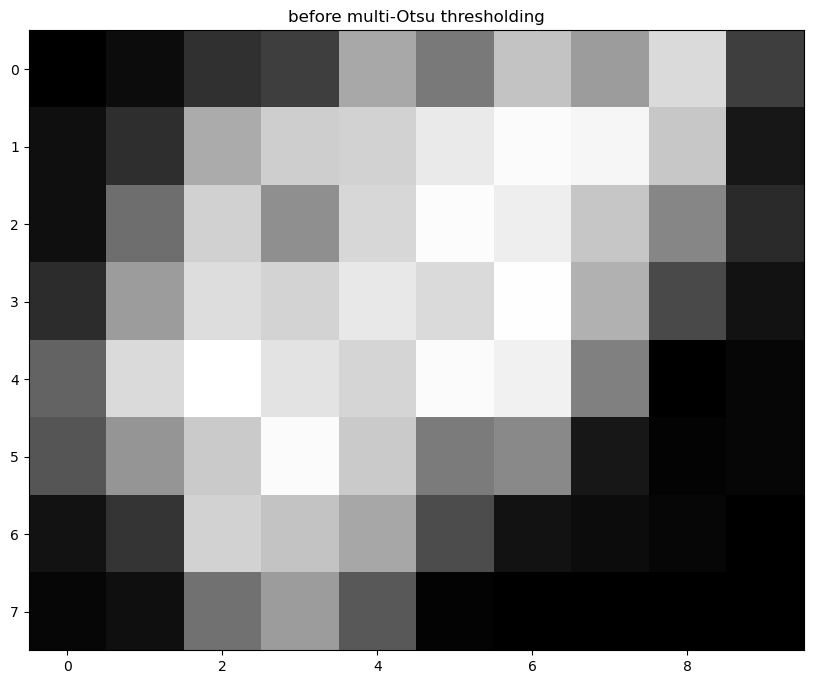

Deleting images from local for sequence 20230428-055517
Processing sequence 11/13: 20230428-091517
20230428-091517
extract images from server to local


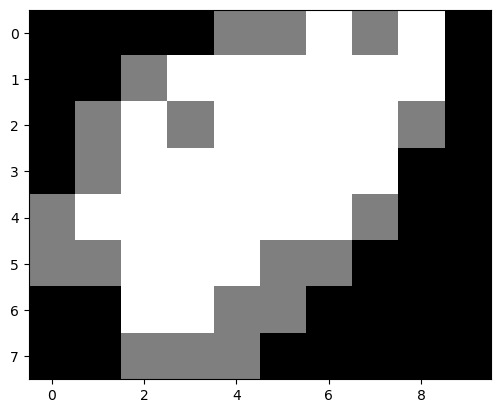

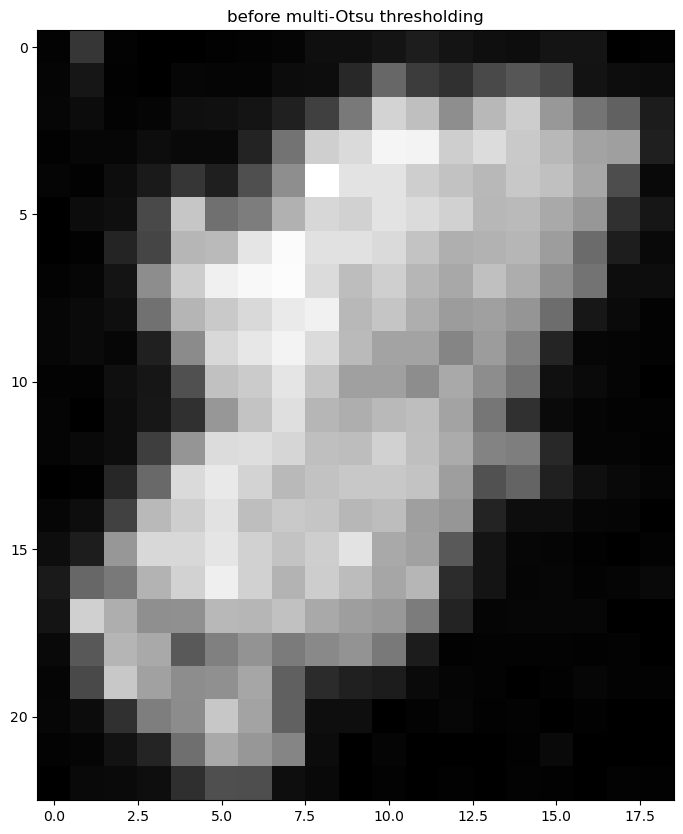

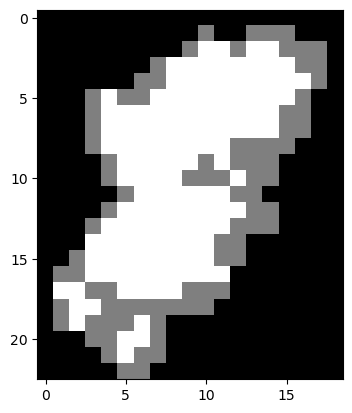

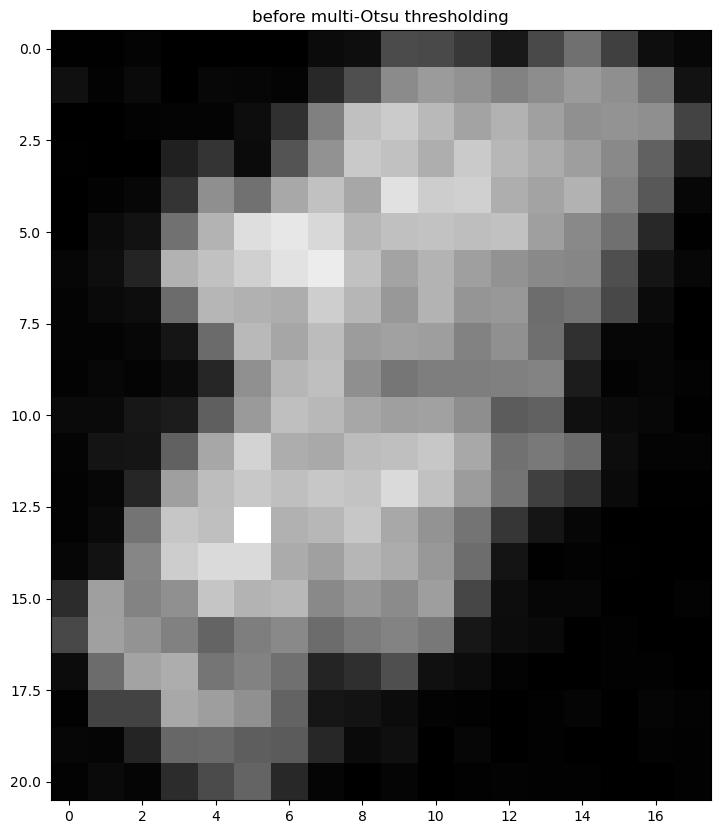

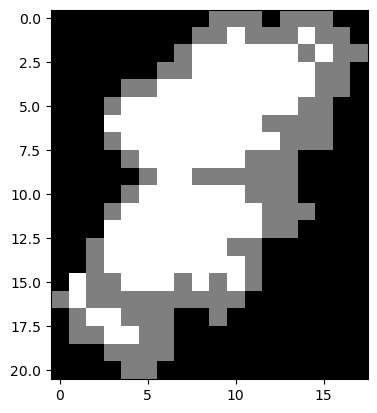

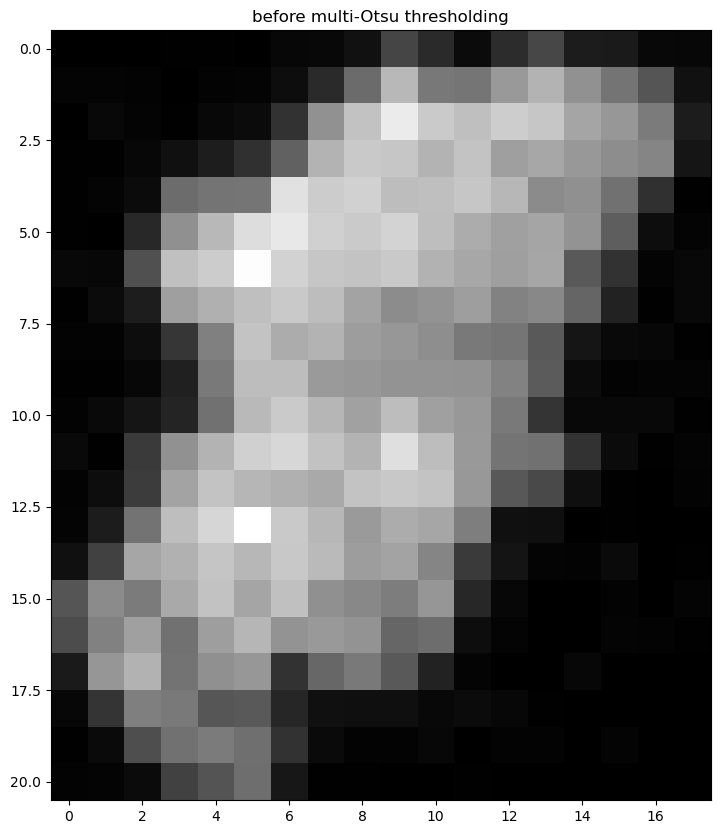

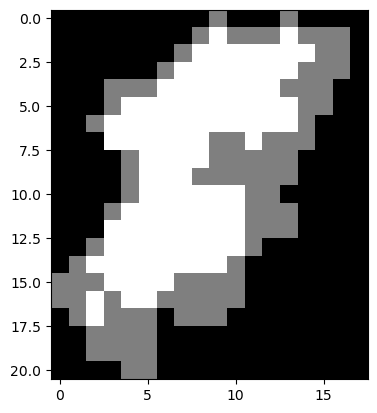

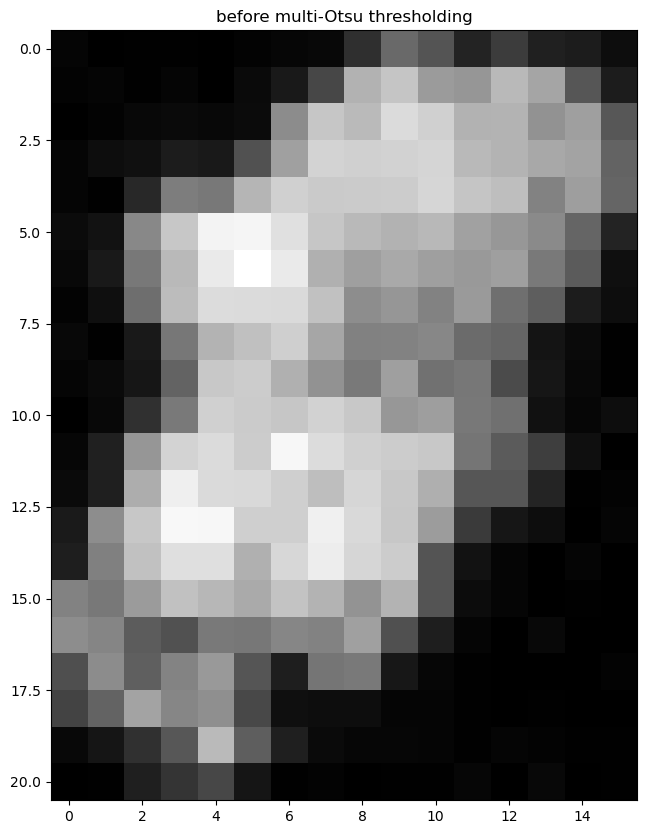

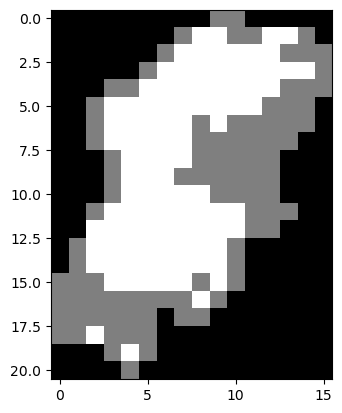

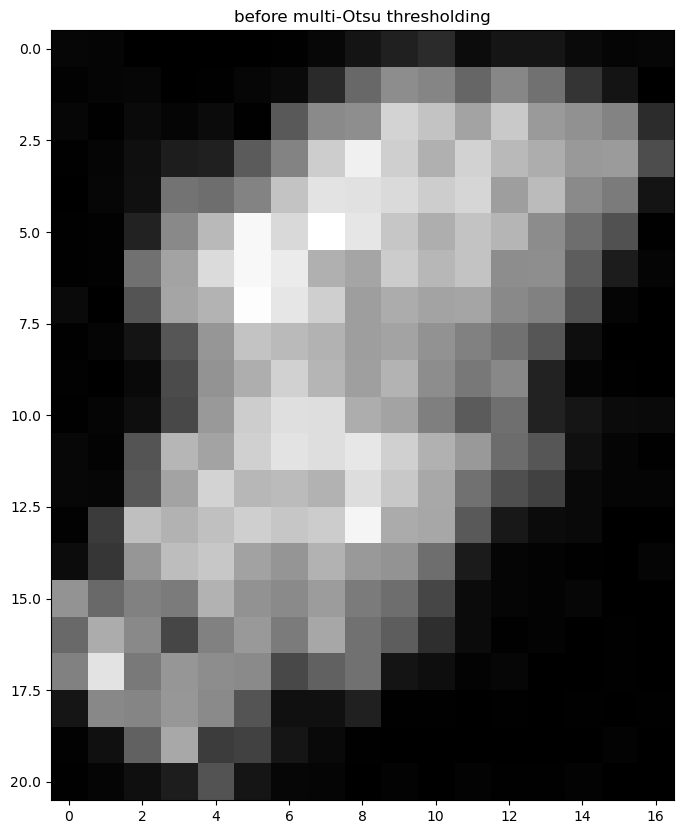

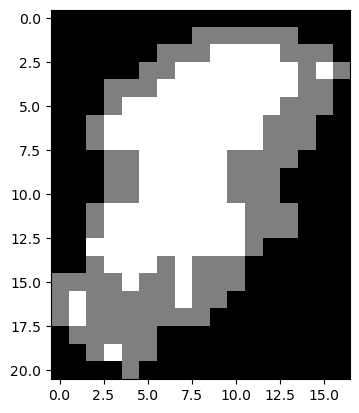

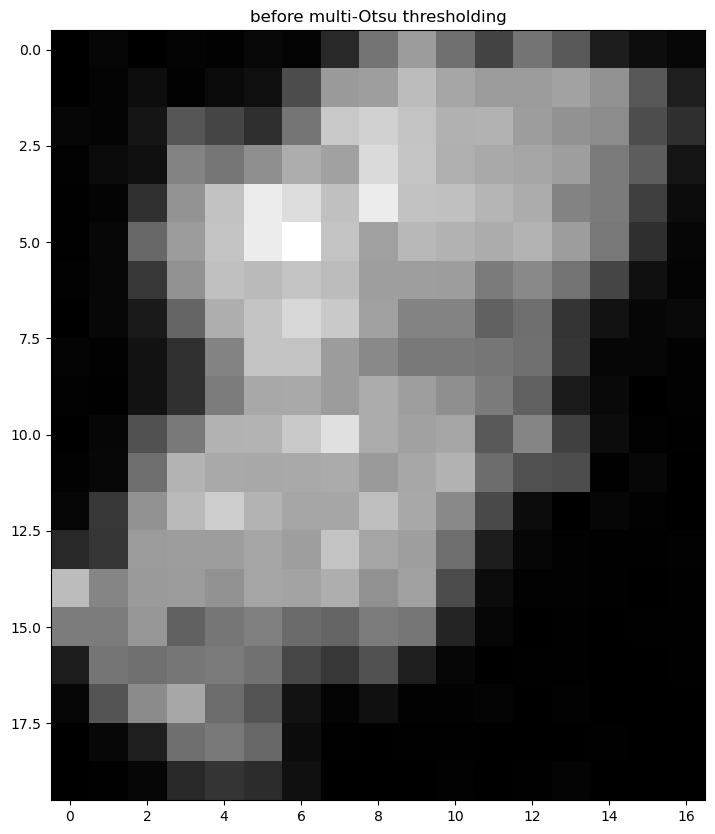

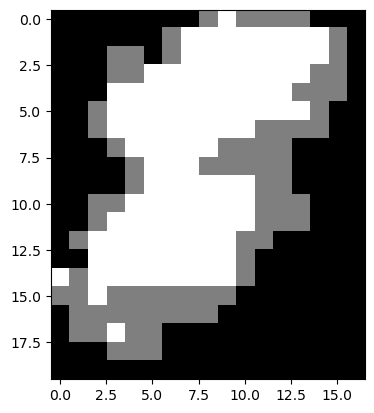

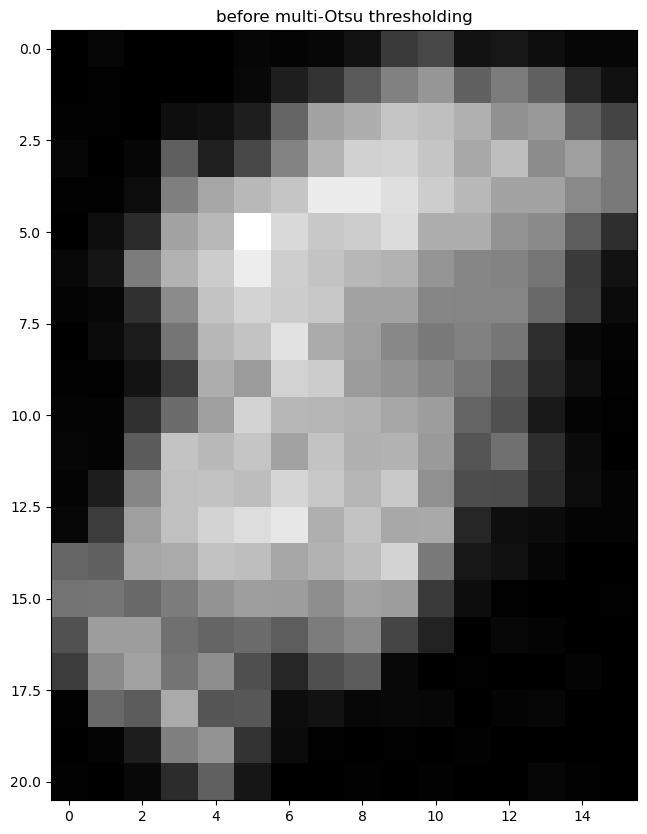

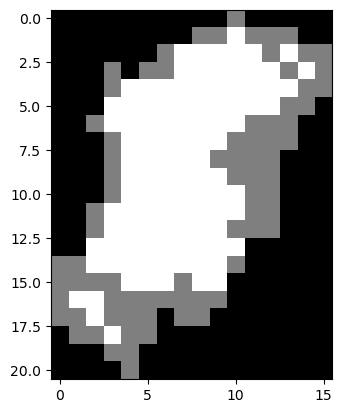

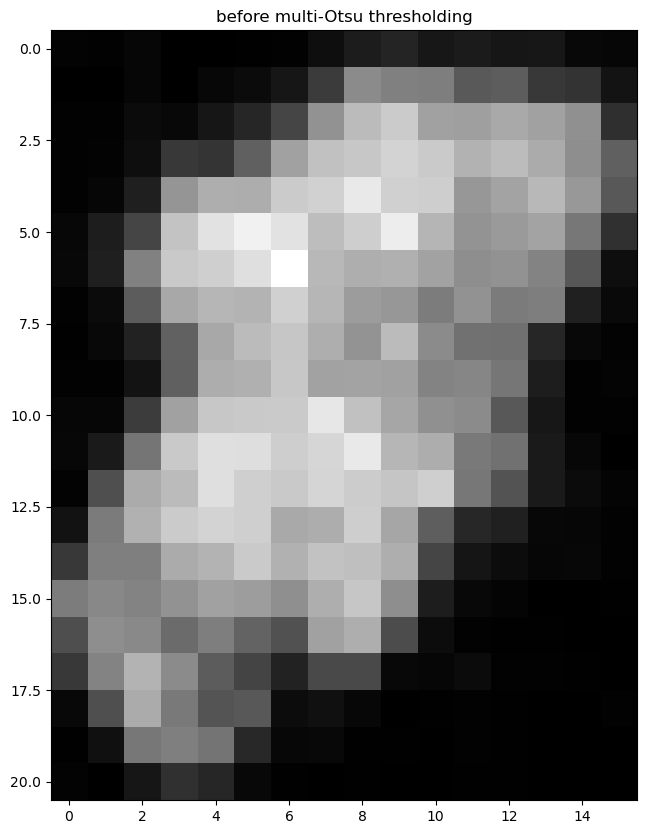

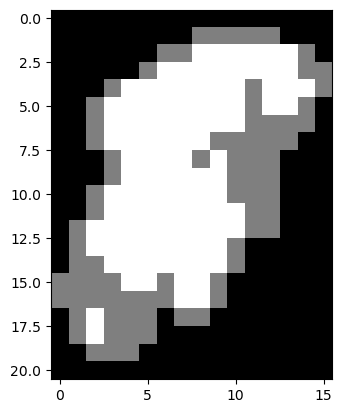

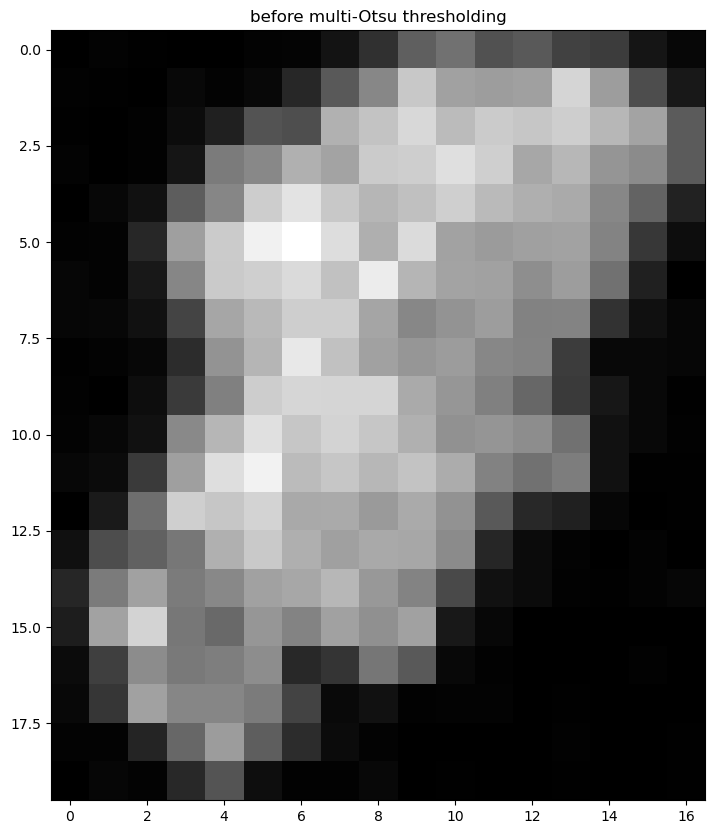

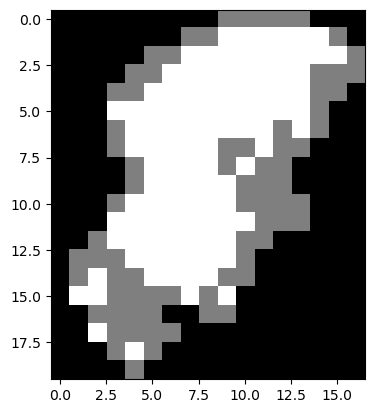

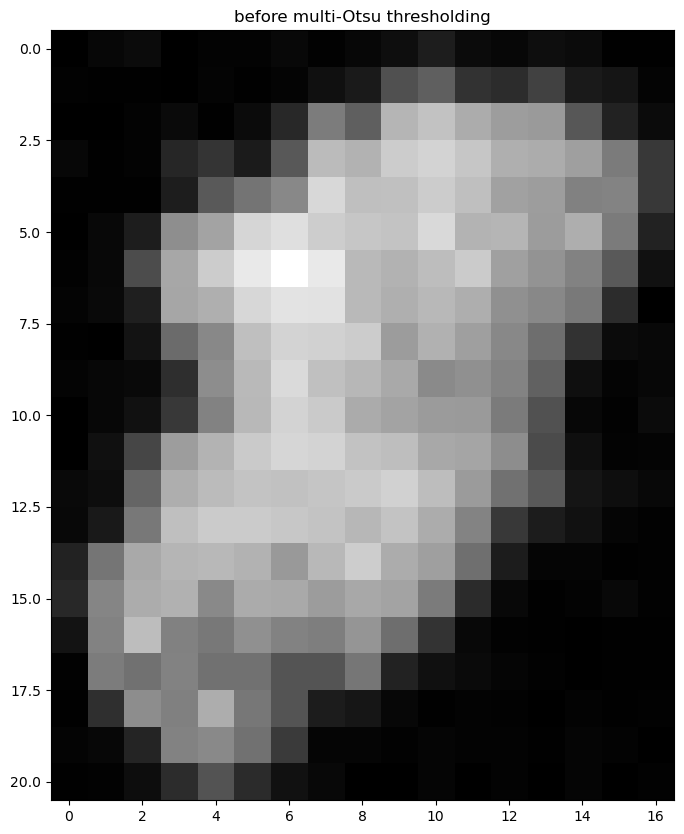

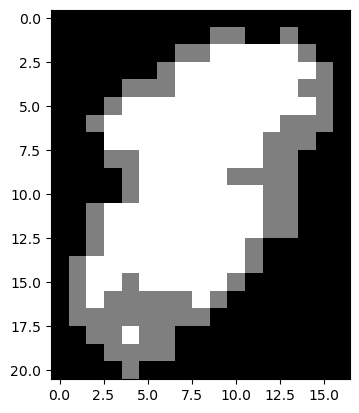

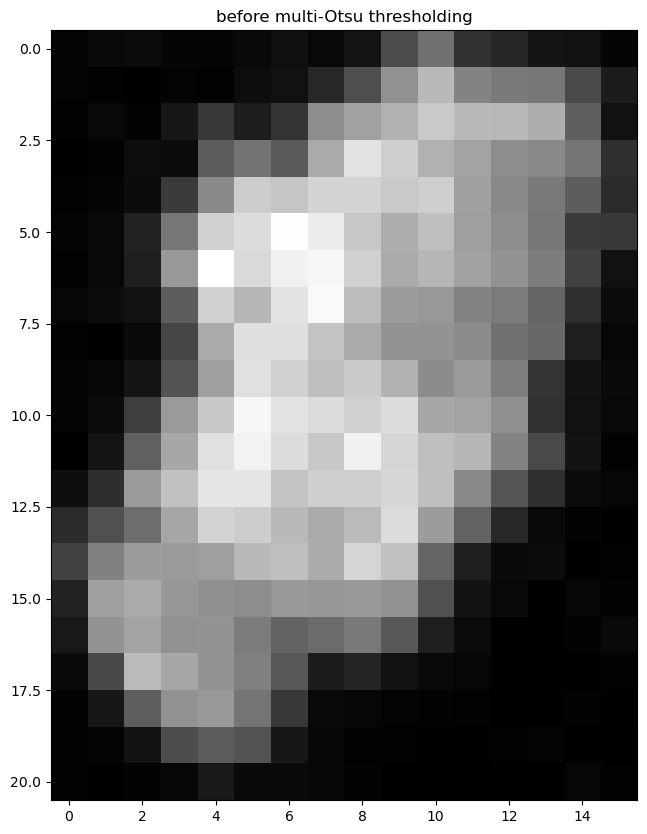

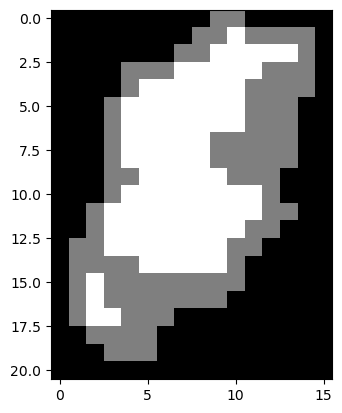

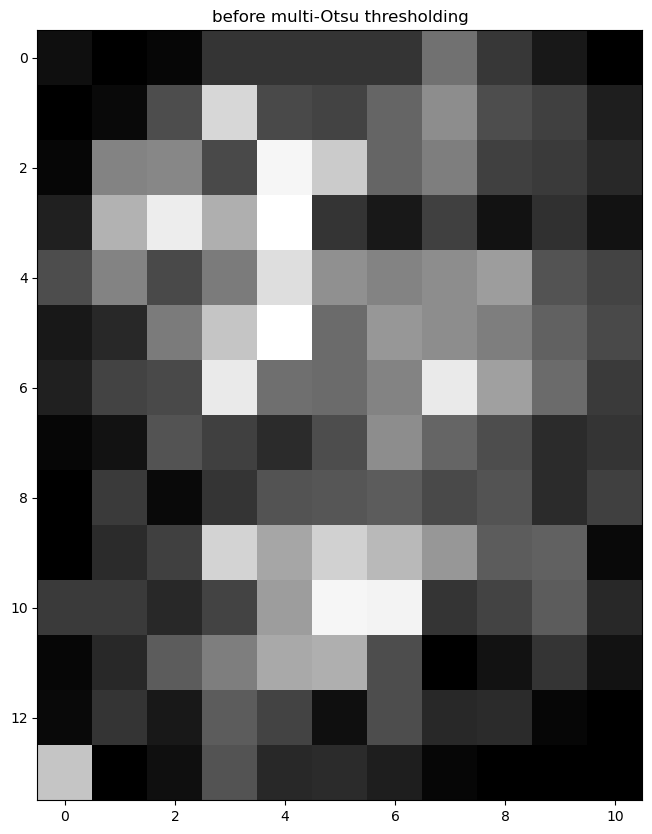

Deleting images from local for sequence 20230428-091517
Processing sequence 12/13: 20230429-150426
20230429-150426
extract images from server to local


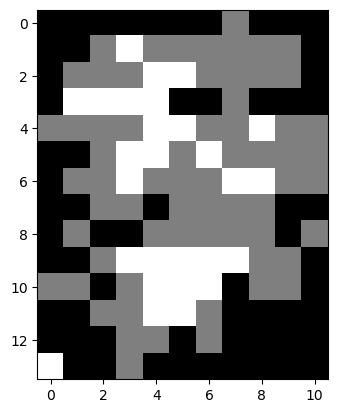

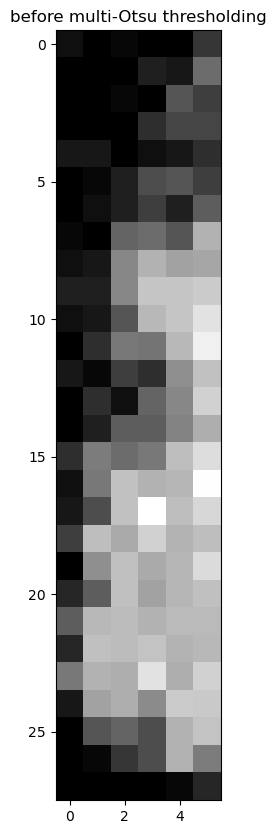

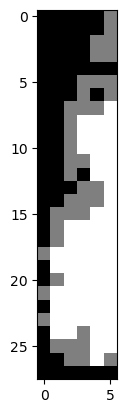

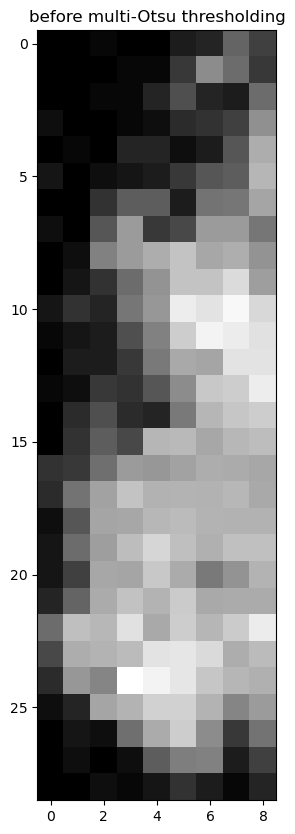

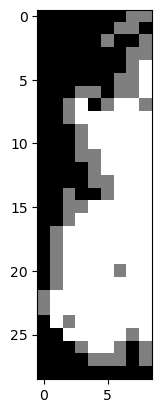

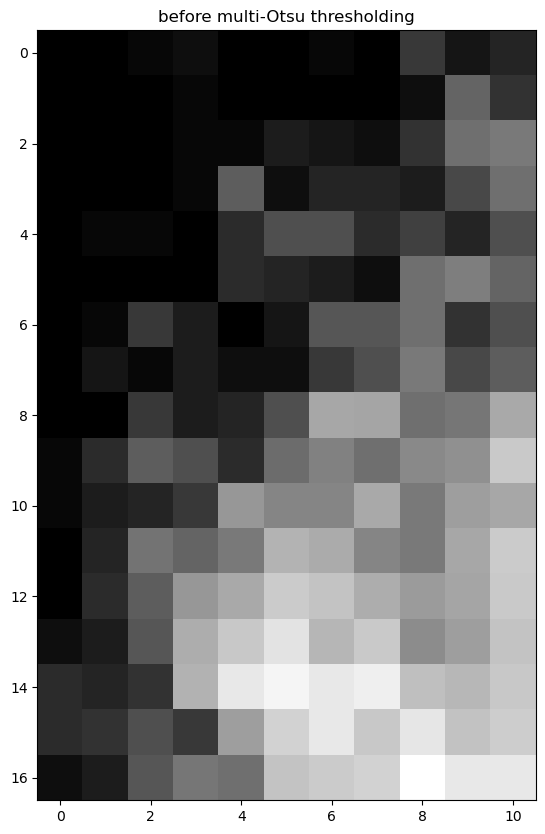

Deleting images from local for sequence 20230429-150426
Processing sequence 13/13: 20230501-063321
20230501-063321
extract images from server to local


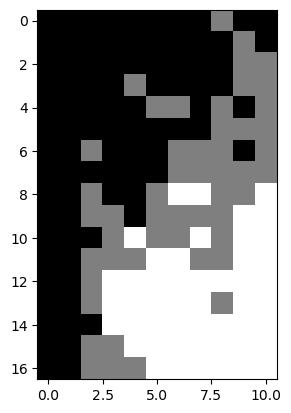

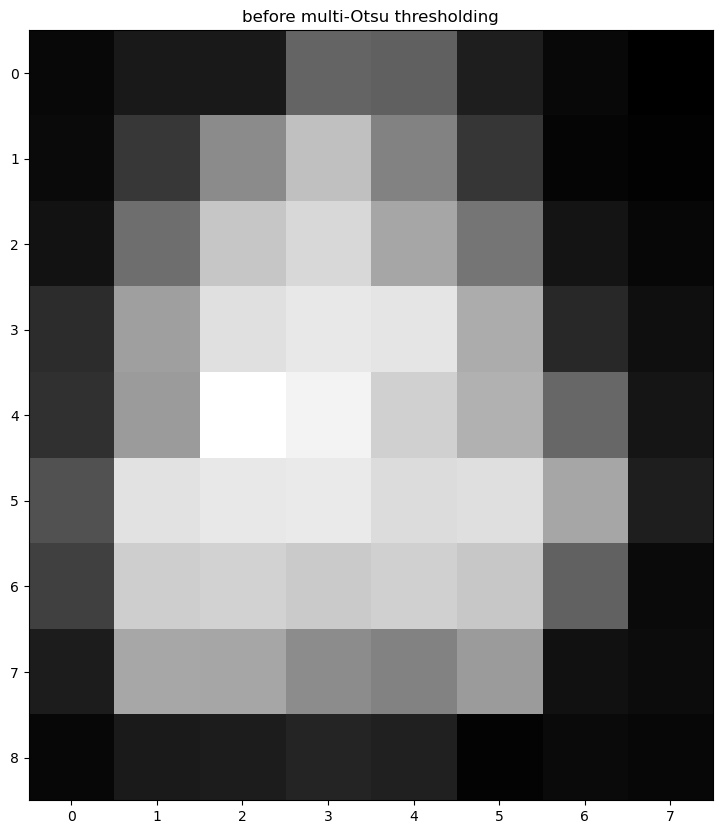

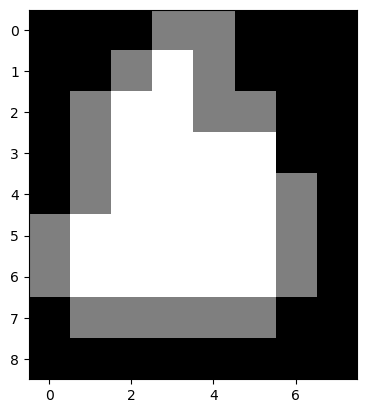

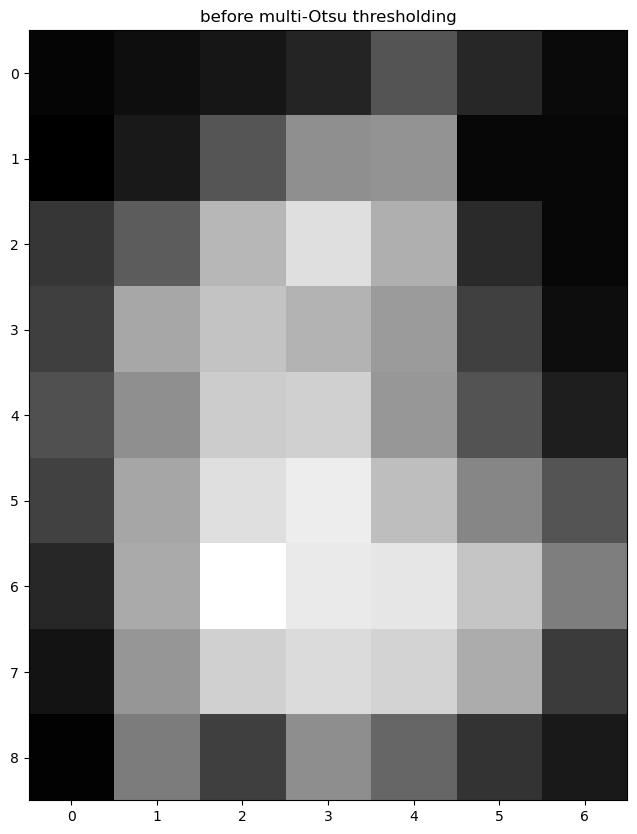

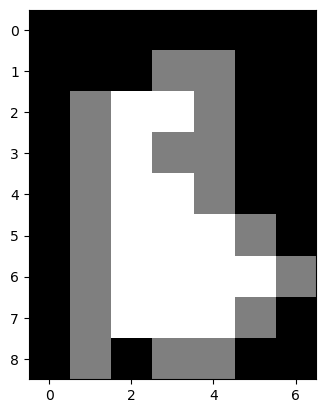

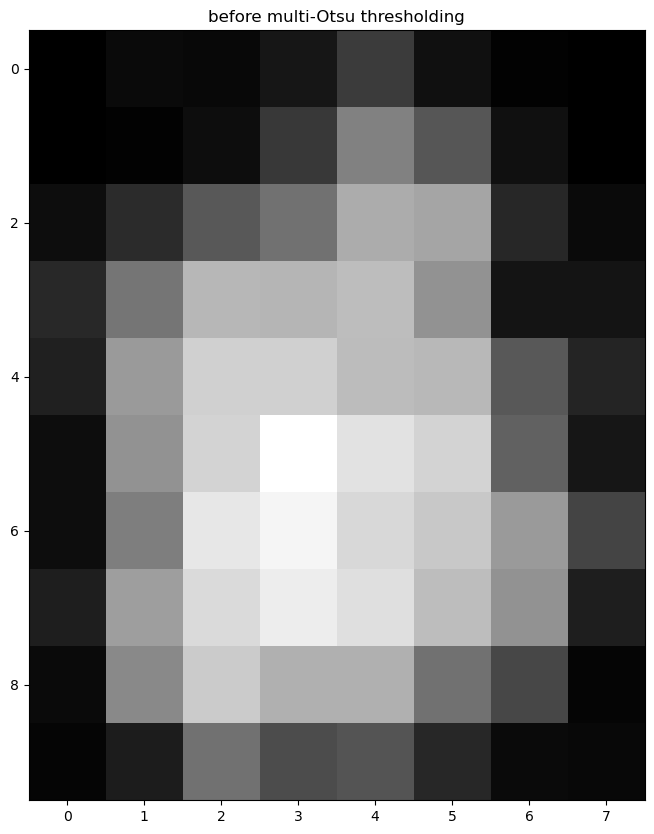

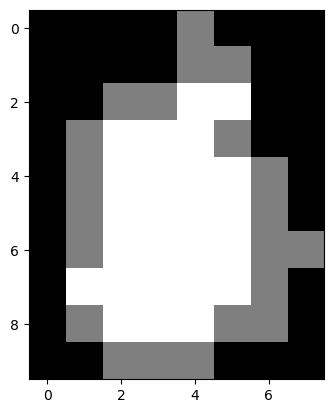

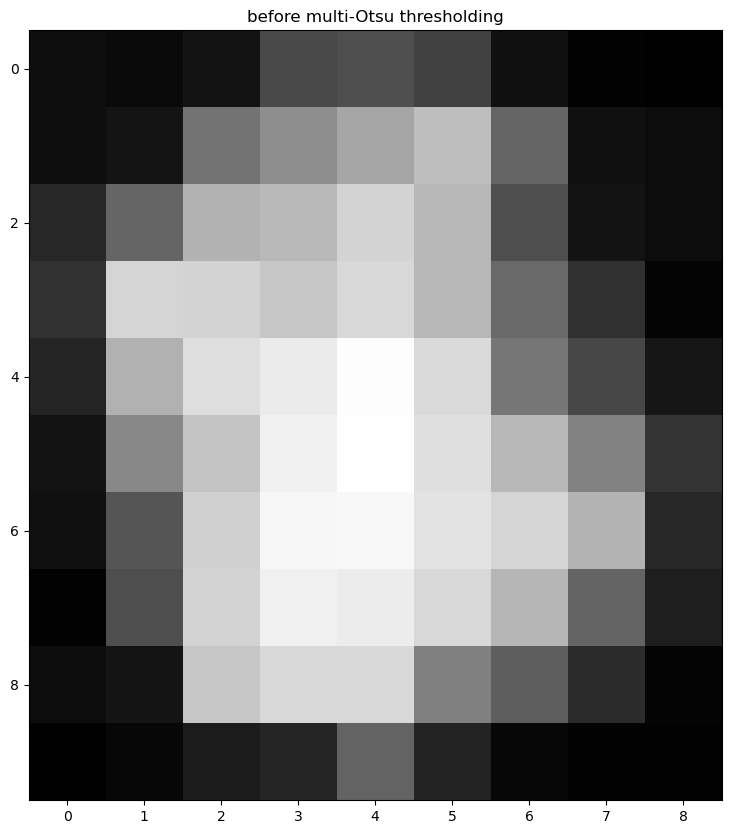

Deleting images from local for sequence 20230501-063321


,track_id,corrected_by_poly,track_length,speed,angle,vertical_speed,orientation,sequence,part_id,n_img,img_name,datetime,coord_x,coord_y,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,orientation_particle,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,filename,PC1,PC2,PC3,PC4,PC5,roll,potential_match,euclidean_distance,sequence_ini,date_ini,area_low,area_high,low_grey_percentage,high_grey_percentage
0,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,751,56,20230418-142418-1,2023-04-18 14:24:18,1960.716981,1471.679245,53.0,8.214724,30.142136,209172.806717,516.068880,10.328734,7.183110,0.145570,2.918280,107.981132,69.151049,64.039937,5723,90.0,23,234,211,66.0,0.718575,0.535354,0.803030,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.572849,-0.387994,-0.965730,-1.176560,0.156809,0,False,78646.880317,20230418-142321,2023-04-18 14:24:13,15,22,40.540541,59.459459
1,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,777,57,20230418-142419-1,2023-04-18 14:24:19,1974.355932,1513.440678,59.0,8.667245,30.935029,236273.884390,548.482682,10.464506,7.902196,0.205998,2.956186,111.135593,73.080976,65.758389,6557,97.0,23,239,216,75.0,0.655560,0.546296,0.786667,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.284811,-0.611685,-1.012164,-1.097183,0.133193,0,False,27113.931169,20230418-142321,2023-04-18 14:24:13,20,21,48.780488,51.219512
2,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,799,58,20230418-142420-1,2023-04-18 14:24:20,1988.728814,1553.983051,59.0,8.667245,32.556349,236273.884390,548.482682,10.616019,7.984109,0.424323,3.066719,103.694915,66.268906,63.907576,6118,82.0,24,232,208,74.0,0.659070,0.491667,0.797297,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,9.382553,-0.382747,-1.006391,-0.769456,-0.282902,0,False,439.509803,20230418-142321,2023-04-18 14:24:13,23,22,51.111111,48.888889
3,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,833,59,20230418-142421-1,2023-04-18 14:24:21,2002.090909,1593.800000,55.0,8.368284,28.384776,218162.374209,527.041708,9.836139,7.331499,0.231439,2.885764,107.854545,68.425253,63.442159,5932,95.0,24,227,203,61.0,0.666658,0.687500,0.901639,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,8.067950,-1.371479,-1.556762,-0.289608,0.811634,0,False,18112.490208,20230418-142321,2023-04-18 14:24:13,20,18,52.631579,47.368421
4,vlfr_20230418-142413-1-608,91.721063,20,272.512820,288.753336,258.038728,desc,20230418-142321,998,65,20230418-142427-1,2023-04-18 14:24:27,2087.980000,1842.080000,50.0,7.978846,25.142136,195775.238153,499.268240,9.356339,6.953426,0.124410,2.687177,90.740000,49.943092,55.039775,4537,93.0,23,182,159,54.0,0.669094,0.625000,0.925926,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,7.266446,-0.892945,-0.949021,0.125327,0.549094,0,False,39518.815419,20230418-142321,2023-04-18 14:24:13,19,16,54.285714,45.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,vlfr_20230429-150651-1-3704,318.482652,4,268.361239,268.749783,268.292401,desc,20230429-150426,3795,144,20230429-150654-1,2023-04-29 15:06:54,2459.223140,2048.876033,121.0,12.412171,50.313708,534283.812969,824.785596,17.860174,10.219316,-0.324754,2.817089,73.214876,34.879535,47.639956,8859,71.0,23,145,122,149.0,0.820125,0.647059,0.812081,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,34.855746,5.665215,0.266584,8.470950,13.514214,0,False,363173.779734,20230429-150426,2023-04-29 15:06:51,51,49,51.000000,49.000000
124,vlfr_20230501-063436-1-1392,70.628058,21,75.743824,7.369533,9.710262,asc,20230501-063321,1392,71,20230501-063436-1,2023-05-01 06:34:36,985.981481,609.074074,54.0,8.291860,25.899495,213661.930067,521.577241

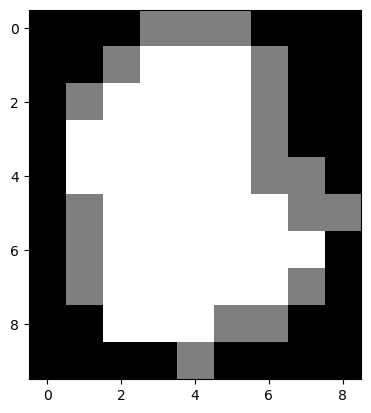

In [20]:
count = 0
vlfr_tracks = x_y_positions_vlfr_big_part['track_id'].unique()
vlfr_sequences = x_y_positions_vlfr_big_part['sequence'].unique()
final_particles_list = []

for sequence in vlfr_sequences:
    count += 1
    print(f'Processing sequence {count}/{len(vlfr_sequences)}: {sequence}')
    data_sequence = x_y_positions_vlfr_big_part[x_y_positions_vlfr_big_part['sequence'] == sequence]

    # extract images from server 
    sequence = data_sequence['sequence'].iloc[0]
    print(sequence)
    source_directory = '/home/aaccardo/plankton/uvp6_missions/uvp6_sn000146lp/uvp6_sn000146lp_202304_sed_float_vlfr'
    dir_raw = os.path.join(source_directory, 'raw')
    dest_directory = '/home/aaccardo/these_alex/Analysis/APERO/TZEX/all_cycle_analysis/Data/sinking_speeds/multithresholding_meangrey'
    dir_copy_raw = os.path.join(dest_directory, 'copy_raw')

    path_zip = os.path.join(dir_raw, sequence, 'images.zip')
    if os.path.exists(path_zip):
        archive = zipfile.ZipFile(path_zip)
        names = [i for i in archive.namelist() 
                 if not i.startswith('images')]
        print('extract images from server to local')
        for file in names:
            archive.extract(file, os.path.join(dir_copy_raw, sequence))

    tracks_sequence = data_sequence['track_id'].unique()

    for track in tracks_sequence:
        track_df = data_sequence[data_sequence['track_id'] == track]
        #print(track_df)

        all_particles = []
        for index, row in track_df.iterrows():

            # Read the image from the filename
            img = imread(row['filename'])

            # Particle coordinates and area
            x, y = int(row['coord_x']), int(row['coord_y'])
            area = row['area_px']

            # Calculate crop size based on the area of the particle (sqrt for proportional square around the particle)
            crop_size = int((area ** 0.5) * 3)  # Scaling factor can be adjusted for more or less zoom

            # Define cropping boundaries
            x_start = max(x - crop_size // 2, 0)
            y_start = max(y - crop_size // 2, 0)
            x_end = min(x + crop_size // 2, img.shape[1])
            y_end = min(y + crop_size // 2, img.shape[0])

            # Crop the image
            cropped_img = img[y_start:y_end, x_start:x_end]
            #display_image(cropped_img, 'cropped image')

            # Binarize image
            img_binary = cropped_img > 22
            #display_image(img_binary, 'Binarized image')

            # Label the connected regions
            label_img = label(img_binary)
            #print('label: ', label_img)

            props = regionprops(label_img)

            #print('props: ', props)

            # Process each detected particle
            for i in range(len(props)):
                try:
                    raw_area = props[i]['area']
                    #print('area px: ', raw_area)
                    if raw_area <= 20:
                        continue

                    # Crop the image to the bounding box of the particle
                    center = props[i]['centroid']
                    #print('coord_x:', center[1])
                    #print('coord_y:', center[0])
                    minr, minc, maxr, maxc = props[i]['bbox']
                    #print('bbox', minr, minc, maxr, maxc)
                    #print('area px: ', raw_area)
                    #print('')

                    cropped_img = cropped_img[minr:maxr, minc:maxc]
                    display_image(cropped_img, 'before multi-Otsu thresholding')

                    # Apply multi-Otsu thresholding
                    thresholds = threshold_multiotsu(cropped_img, classes=2)
                    regions = np.digitize(cropped_img, bins=thresholds)

                    # Normalize the segmented regions to a grayscale range
                    regions_normalized = (regions - regions.min()) / (regions.max() - regions.min()) * 255
                    regions_normalized = regions_normalized.astype(np.uint8)

                    plt.imshow(regions_normalized, cmap='gray')

                    # Calculate areas for each class
                    areas = [np.sum(regions == j) for j in range(1, 3)]
                    total_area = sum(areas)

                    if total_area == 0:
                        low_grey_percentage = 0
                        high_grey_percentage = 0
                    else:
                        low_grey_percentage = (areas[0] / total_area) * 100
                        high_grey_percentage = (areas[1] / total_area) * 100

                    #print('low_grey_%:', low_grey_percentage)
                    #print('high_grey_%:', high_grey_percentage)

                    # Create a dictionary for the particle
                    p_dict = {
                        'coord_x': row['coord_x'],
                        'coord_y': row['coord_y'],
                        'area_low': areas[0],
                        'area_high': areas[1],
                        'low_grey_percentage': low_grey_percentage,
                        'high_grey_percentage': high_grey_percentage
                    }

                    all_particles.append(p_dict)

                except:
                    print('multi-otsu thresholding was not possible')
                    continue

        # Add the particles from this track to the final list
        final_particles_list.extend(all_particles)

    # Delete the temporary copy raw folder
    print(f'Deleting images from local for sequence {sequence}')
    shutil.rmtree(os.path.join(dir_copy_raw, sequence))

# Convert the final list of dictionaries to a DataFrame
vlfr_df = pd.DataFrame(final_particles_list)
vlfr_df = pd.merge(x_y_positions_vlfr_big_part, vlfr_df, on=['coord_x', 'coord_y'], how='inner')
vlfr_df = vlfr_df.drop_duplicates()
vlfr_df.head(3)

In [21]:
# Merge with the original dataframe to keep only the particles for which we have the multi-otsu thresholding results
vlfr_df = vlfr_df[['track_id', 'esd_um', 'corrected_by_poly', 'area_low', 'area_high', 'low_grey_percentage', 'high_grey_percentage']]
# group by tracks and compute the mean 
vlfr_df_thresh = vlfr_df.groupby('track_id').mean().reset_index()
# compute the ratio between both areas
vlfr_df_thresh['ratio_low_high'] = vlfr_df_thresh['low_grey_percentage'] / vlfr_df_thresh['high_grey_percentage']
vlfr_df_thresh.head(3)

,track_id,esd_um,corrected_by_poly,area_low,area_high,low_grey_percentage,high_grey_percentage,ratio_low_high
0,vlfr_20230418-142413-1-608,527.868839,91.721063,19.400000,19.800000,49.469887,50.530113,0.979018
1,vlfr_20230418-142605-1-3707,522.734389,68.070449,21.304348,25.347826,46.009253,53.990747,0.852169
2,vlfr_20230421-070100-1-3056,1281.899100,-27.648748,128.000000,87.000000,59.534884,40.465116,1.471264
3,vlfr_20230421-074420-1-7411,654.987216,-302.256943,41.000000,26.200000,61.399569,38.600431,1.590645
4,vlfr_20230421-190102-1-3080,513.223566,171.849815,18.250000,23.500000,43.758975,56.241025,0.778061
5,vlfr_20230423-001649-1-6833,510.515434,141.552392,20.000000,22.000000,47.619048,52.380952,0.909091
6,vlfr_20230423-001845-1-9538,720.818262,149.696229,35.000000,51.142857,41.248471,58.751529,0.702083
7,vlfr_20230423-181058-1-664,532.832969,126.224765,19.312500,23.500000,45.530176,54.469824,0.835879
8,vlfr_20230423-181255-1-3918,544.500792,57.997300,19.388889,29.555556,39.709061,60.290939,0.658624
9,vlfr_20230425-184056-1-5003,527.486473,45.099879,18.166667,22.166667,45.339161,54.660839,0.829463


# Same thing for North Atlantic and MBARI datasets....

In [24]:
APERO_VLFR_MBARI = pd.concat([APERO_thresh, vlfr_df_thresh, MBARI_df_thresh], ignore_index = True)
# add orientation
APERO_VLFR_MBARI['orientation'] = np.where(APERO_VLFR_MBARI['corrected_by_poly'] < 0, 'asc', 'desc')
APERO_VLFR_MBARI.head(3)

,track_id,esd_um,corrected_by_poly,area_low,area_high,low_grey_percentage,high_grey_percentage,ratio_low_high,orientation
0,APERO_C1_20230611-002829-1-1435,1035.906803,78.591289,91.571429,51.714286,63.906820,36.093180,1.770607,desc
1,APERO_C1_20230611-022354-1-13404,504.891837,121.783572,23.000000,27.000000,45.833333,54.166667,0.846154,desc
2,APERO_C2_20230616-234310-1-430,947.926007,-299.721854,39.000000,63.800000,42.501007,57.498993,0.739161,asc
3,APERO_C2_20230616-234324-1-1058,2564.254579,-177.623908,362.641026,369.435897,56.585771,43.414229,1.303392,asc
4,APERO_C2_20230616-234458-1-4467,656.053843,-180.577169,41.000000,30.500000,57.575758,42.424242,1.357143,asc
...,...,...,...,...,...,...,...,...,...
382,MBARI_2024_deep_20241123-025613-1-11947,555.962259,140.362948,24.000000,26.111111,47.866587,52.133413,0.918156,desc
383,MBARI_2024_deep_20241123-025618-1-12057,788.071914,161.495148,33.666667,61.666667,35.344938,64.655062,0.546669,desc
384,MBARI_2024_deep_20241123-073025-1-1182,528.323107,114.145864,21.500000,22.500000,49.123477,50.876523,0.965543,desc
385,MBARI_2024_deep_20241123-073129-1-3170,1200.585174,104.551268,101.416667,134.291667,45.952483,54.047517,0.850224,desc


In [25]:
APERO_VLFR_MBARI['total_area'] = APERO_VLFR_MBARI['area_low'] + APERO_VLFR_MBARI['area_high']
APERO_VLFR_MBARI.head(3)

,track_id,esd_um,corrected_by_poly,area_low,area_high,low_grey_percentage,high_grey_percentage,ratio_low_high,orientation,total_area
0,APERO_C1_20230611-002829-1-1435,1035.906803,78.591289,91.571429,51.714286,63.906820,36.093180,1.770607,desc,143.285714
1,APERO_C1_20230611-022354-1-13404,504.891837,121.783572,23.000000,27.000000,45.833333,54.166667,0.846154,desc,50.000000
2,APERO_C2_20230616-234310-1-430,947.926007,-299.721854,39.000000,63.800000,42.501007,57.498993,0.739161,asc,102.800000
3,APERO_C2_20230616-234324-1-1058,2564.254579,-177.623908,362.641026,369.435897,56.585771,43.414229,1.303392,asc,732.076923
4,APERO_C2_20230616-234458-1-4467,656.053843,-180.577169,41.000000,30.500000,57.575758,42.424242,1.357143,asc,71.500000
...,...,...,...,...,...,...,...,...,...,...
382,MBARI_2024_deep_20241123-025613-1-11947,555.962259,140.362948,24.000000,26.111111,47.866587,52.133413,0.918156,desc,50.111111
383,MBARI_2024_deep_20241123-025618-1-12057,788.071914,161.495148,33.666667,61.666667,35.344938,64.655062,0.546669,desc,95.333333
384,MBARI_2024_deep_20241123-073025-1-1182,528.323107,114.145864,21.500000,22.500000,49.123477,50.876523,0.965543,desc,44.000000
385,MBARI_2024_deep_20241123-073129-1-3170,1200.585174,104.551268,101.416667,134.291667,45.952483,54.047517,0.850224,desc,235.708333


In [26]:
APERO_VLFR_MBARI['total_area'].describe()

count     387.000000
mean      138.271040
std       212.515032
min        22.000000
25%        55.306818
50%        92.000000
75%       153.191667
max      3377.571429
Name: total_area, dtype: float64

# Add size classes

In [27]:
size_class = pd.read_csv('/home/aaccardo/these_alex/Analysis/APERO/TZEX/all_cycle_analysis/Data/size_classes.csv', delimiter = ';')

In [29]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
APERO_VLFR_MBARI['size_classes'] = APERO_VLFR_MBARI['esd_um'].apply(assign_size_class)
APERO_VLFR_MBARI.head(3)

,track_id,esd_um,corrected_by_poly,area_low,area_high,low_grey_percentage,high_grey_percentage,ratio_low_high,orientation,total_area,size_classes
0,APERO_C1_20230611-002829-1-1435,1035.906803,78.591289,91.571429,51.714286,63.906820,36.093180,1.770607,desc,143.285714,1020-1290
1,APERO_C1_20230611-022354-1-13404,504.891837,121.783572,23.000000,27.000000,45.833333,54.166667,0.846154,desc,50.000000,406-512
2,APERO_C2_20230616-234310-1-430,947.926007,-299.721854,39.000000,63.800000,42.501007,57.498993,0.739161,asc,102.800000,813-1020
3,APERO_C2_20230616-234324-1-1058,2564.254579,-177.623908,362.641026,369.435897,56.585771,43.414229,1.303392,asc,732.076923,2050-2580
4,APERO_C2_20230616-234458-1-4467,656.053843,-180.577169,41.000000,30.500000,57.575758,42.424242,1.357143,asc,71.500000,645-813
...,...,...,...,...,...,...,...,...,...,...,...
382,MBARI_2024_deep_20241123-025613-1-11947,555.962259,140.362948,24.000000,26.111111,47.866587,52.133413,0.918156,desc,50.111111,512-645
383,MBARI_2024_deep_20241123-025618-1-12057,788.071914,161.495148,33.666667,61.666667,35.344938,64.655062,0.546669,desc,95.333333,645-813
384,MBARI_2024_deep_20241123-073025-1-1182,528.323107,114.145864,21.500000,22.500000,49.123477,50.876523,0.965543,desc,44.000000,512-645
385,MBARI_2024_deep_20241123-073129-1-3170,1200.585174,104.551268,101.416667,134.291667,45.952483,54.047517,0.850224,desc,235.708333,1020-1290


# Save results from all deployments 

In [30]:
APERO_VLFR_MBARI.to_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Multi_Otsu_Thresholding/APERO_VLFR_MBARI_selected_tracks_poly_with_multi_threshold_meangrey.csv', index = False)